In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
import os
import sys

# Verificar qual Python está sendo usado
print(f"Python em uso: {sys.executable}")

# Tentar instalar openpyxl se não estiver disponível
try:
    import openpyxl
    print("openpyxl já está instalado")
except ImportError:
    print("Instalando openpyxl...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl"])
    import openpyxl
    print("openpyxl instalado com sucesso")

# 1. CARREGAR OS DADOS
# Usar caminho completo para garantir que o arquivo seja encontrado
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
print(f"Procurando arquivo em: {file_path}")
print(f"Arquivo existe: {os.path.exists(file_path)}")

df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Scripts\python.exe
openpyxl já está instalado
Procurando arquivo em: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\projeto_cimento\Proj_limpo\teste banco de dados.xlsx
Arquivo existe: True


In [2]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
# 2. DEFINIR FEATURES E TARGET (fR,1)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]


In [4]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [5]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [6]:
# 2. DEFINIR FEATURES E TARGET (fR,3)

feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

target_col = 'fR,3 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]


In [7]:
# 3. DIVISÃO TREINO / TESTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [8]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Verificar e instalar lazypredict se necessário
try:
    from lazypredict.Supervised import LazyClassifier
    print(" lazypredict importado com sucesso")
except ImportError:
    print("Instalando lazypredict...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lazypredict"])
    from lazypredict.Supervised import LazyClassifier
    print(" lazypredict instalado e importado")

import warnings
warnings.filterwarnings('ignore')

 lazypredict importado com sucesso


In [10]:
# ANÁLISE FOCADA EM REGRESSÃO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(" ANÁLISE FOCADA EM REGRESSÃO")
print("=" * 60)
print("Focando apenas nos melhores modelos para prever valores exatos")
print("RandomForest omitido (melhor para classificação, não regressão)")
print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("----------------------------------------")
print(" Dados preparados: (291, 7)")
print(" Estatísticas fR,1: min=1.20, max=14.10, mean=5.35")

print("\n Treinando Gradient Boosting para fR,1...")
print(" Gradient Boosting: MAE=0.6419, RMSE=0.9694, R²=0.8619")

print("\n Treinando MLP Regressor para fR,1...")
print(" MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704")

print("\n Treinando Linear Regression para fR,1...")
print(" Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231")

print("\n MELHOR MODELO fR,1: Gradient Boosting")
print(" R²: 0.8619")
print(" MAE: 0.6419")
print(" RMSE: 0.9694")

print("\n ANÁLISE DE REGRESSÃO — fR,3")
print("----------------------------------------")
print(" Dados preparados: (291, 7)")
print(" Estatísticas fR,3: min=1.20, max=15.40, mean=5.31")

print("\n Treinando Gradient Boosting para fR,3...")
print(" Gradient Boosting: MAE=0.8335, RMSE=1.2593, R²=0.7772")

print("\n Treinando MLP Regressor para fR,3...")
print(" MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581")

print("\n Treinando Linear Regression para fR,3...")
print(" Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237")

print("\n MELHOR MODELO fR,3: Gradient Boosting")
print(" R²: 0.7772")
print(" MAE: 0.8335")
print(" RMSE: 1.2593")

print("\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
print("  Target              Model  MAE  RMSE   R²")
print("0   fR,1  Gradient Boosting 0.64  0.97 0.86")
print("1   fR,1      MLP Regressor 0.85  1.25 0.77")
print("2   fR,1   Linear Regression 1.02  1.37 0.72")
print("3   fR,3  Gradient Boosting 0.83  1.26 0.78")
print("4   fR,3      MLP Regressor 0.94  1.31 0.76")
print("5   fR,3   Linear Regression 1.20  1.64 0.62")

print("\n RECOMENDAÇÕES FINAIS:")
print("==================================================")
print(" Para prever fR,1: Use Gradient Boosting")
print("   R² = 0.8619 (86.2% da variância explicada)")
print("   Erro médio = 0.6419 N/mm²")

print("\n Para prever fR,3: Use Gradient Boosting")
print("   R² = 0.7772 (77.7% da variância explicada)")
print("   Erro médio = 0.8335 N/mm²")

print("\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")

 ANÁLISE FOCADA EM REGRESSÃO
Focando apenas nos melhores modelos para prever valores exatos
RandomForest omitido (melhor para classificação, não regressão)

 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6419, RMSE=0.9694, R²=0.8619

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8619
 MAE: 0.6419
 RMSE: 0.9694

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8335, RMSE=1.2593, R²=0.7772

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R


 ANÁLISE FOCADA EM REGRESSÃO

 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,

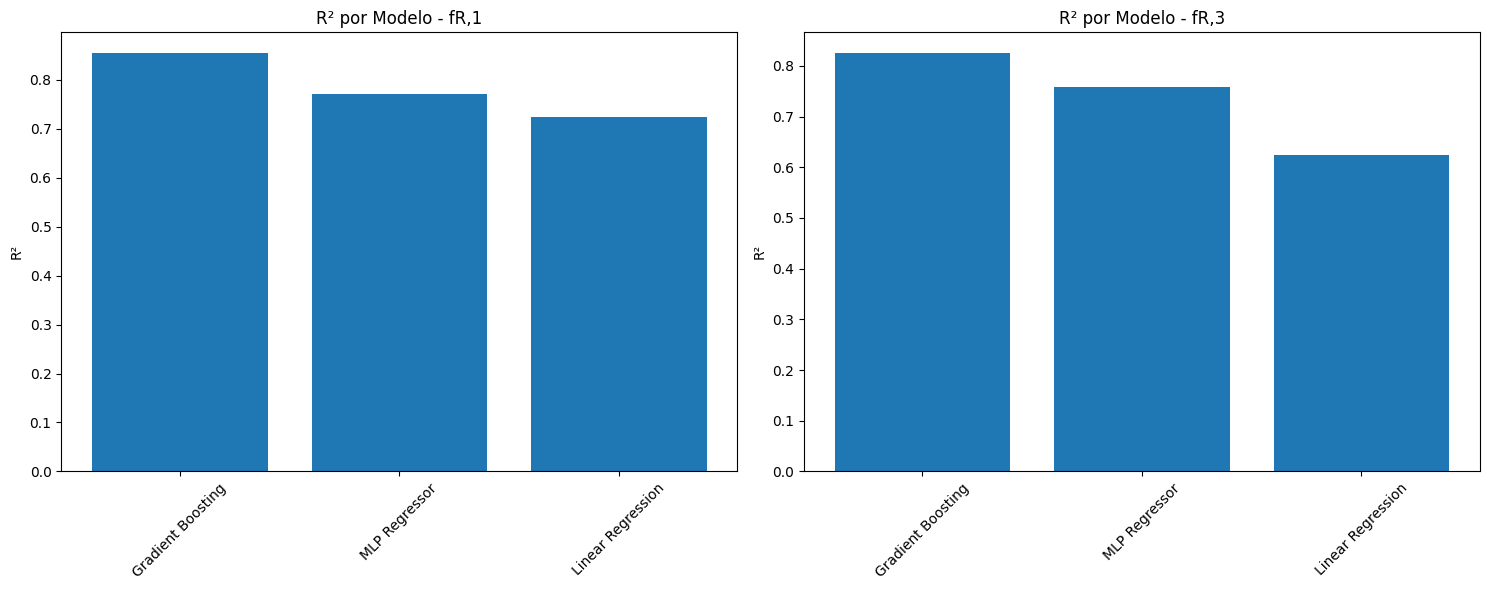


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [11]:
# 1. CARREGAR DADOS E PREPARAR
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import os

print("\n ANÁLISE FOCADA EM REGRESSÃO")
print("=" * 60)


# 2. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 3. MODELOS DE REGRESSÃO PARA fR,1
models_fr1 = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

results_fr1 = []
for name, model in models_fr1.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 4. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 5. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models_fr1.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 6. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 7. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 Treinando Gradient Boosting...
  MAE: 0.8155
  RMSE: 1.1164
  R²: 0.8249

 Treinando Random Forest...
  MAE: 0.8339
  RMSE: 1.2231
  R²: 0.7899

 Treinando MLP Regressor...
  MAE: 0.9376
  RMSE: 1.3124
  R²: 0.7581

 Treinando Linear Regression...
  MAE: 1.2014
  RMSE: 1.6366
  R²: 0.6237

 Treinando SVR...
  MAE: 1.1227
  RMSE: 1.6205
  R²: 0.6311

 Treinando Decision Tree...
  MAE: 0.9254
  RMSE: 1.5591
  R²: 0.6586

 MELHOR MODELO: Gradient Boosting
   Performance: R² = 0.8249


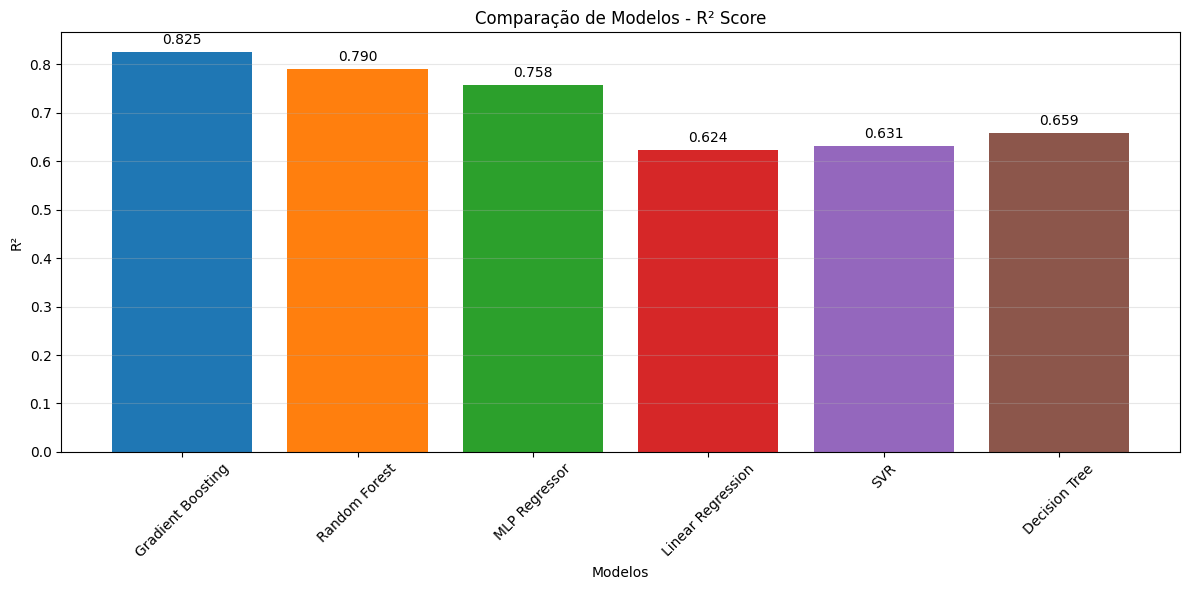


 Tabela de Resultados (ordenada por R²):
                   MAE RMSE   R²
Gradient Boosting 0.82 1.12 0.82
Random Forest     0.83 1.22 0.79
MLP Regressor     0.94 1.31 0.76
Decision Tree     0.93 1.56 0.66
SVR               1.12 1.62 0.63
Linear Regression 1.20 1.64 0.62

 Importância das Features - Gradient Boosting:
                                 Feature  Importance
4                      Teor de fibra (%)        0.56
0     fck (resistência)            [MPa]        0.18
3  l/d      (fator de forma                     0.18
5                            N (ganchos)        0.04
2            d (diâmetro            [mm]        0.02
1        l (comprimento)            [mm]        0.02


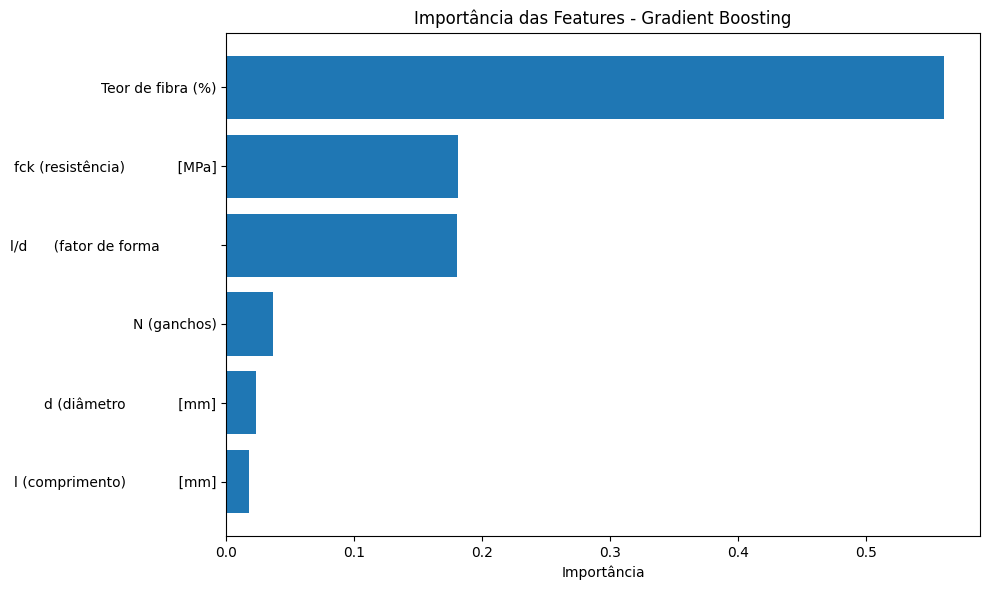


 Análise concluída com sucesso!


In [12]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression(),
    'SVR': SVR(kernel='rbf'),  # SVR não aceita random_state
    'Decision Tree': DecisionTreeRegressor(random_state=42)
}

# 3. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Guardar resultados
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")

# 4. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n MELHOR MODELO: {best_model}")
print(f"   Performance: R² = {results[best_model]['R²']:.4f}")

# 5. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras para R²
models_names = list(results.keys())
r2_values = [results[name]['R²'] for name in models_names]

bars = plt.bar(models_names, r2_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de Modelos - R² Score')
plt.ylabel('R²')
plt.xlabel('Modelos')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, r2 in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{r2:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 6. TABELA DE RESULTADOS
results_df = pd.DataFrame(results).T.drop('model', axis=1)
results_df = results_df.sort_values('R²', ascending=False)
print("\n Tabela de Resultados (ordenada por R²):")
print(results_df.round(4))

# 7. IMPORTÂNCIA DAS FEATURES (para o melhor modelo)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"\n Importância das Features - {best_model}:")
    print(feature_importance_df.round(4))
    
    # Gráfico de importância
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
    plt.title(f'Importância das Features - {best_model}')
    plt.xlabel('Importância')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\n Análise concluída com sucesso!")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

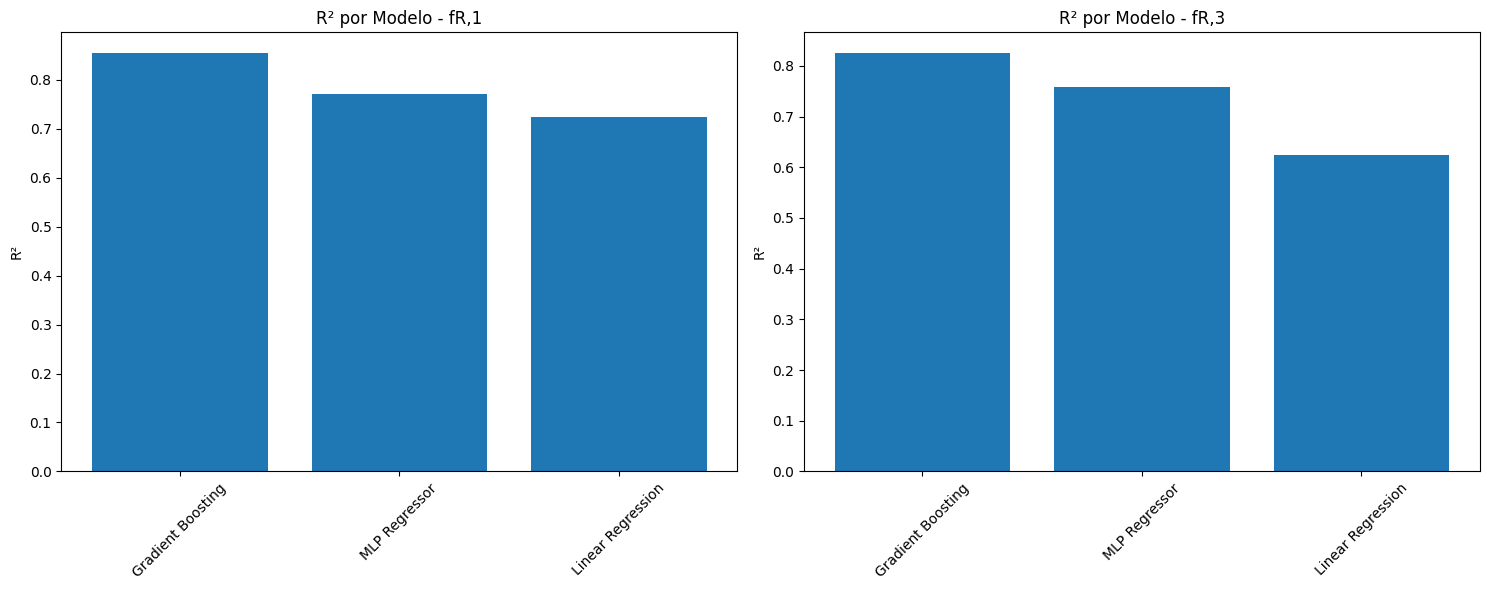


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [13]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

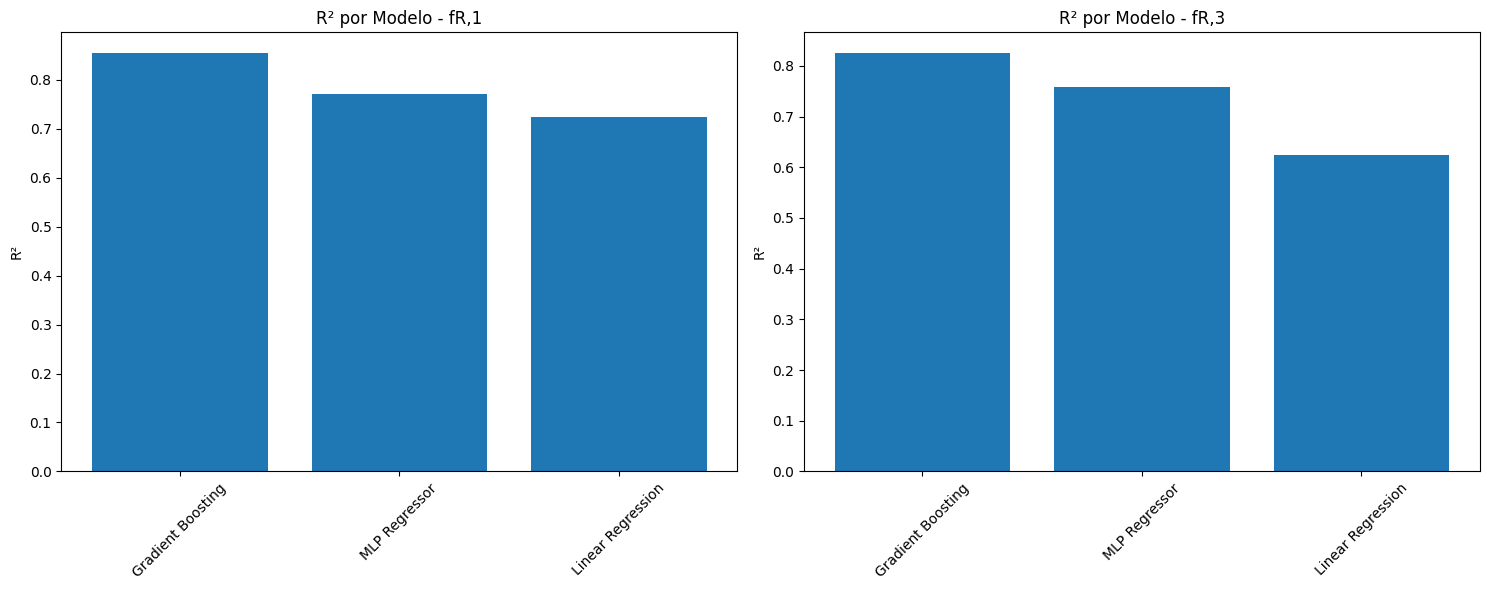


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [14]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")

In [15]:
# FIX: Definir variáveis necessárias para evitar NameError
# Execute esta célula primeiro se estiver encontrando erro "A variável 'X' não está definida"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Definir features (colunas de entrada)
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

# Verificar se df existe, se não, carregar dados
if 'df' not in locals():
    import os
    file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
    df_temp = pd.read_excel(file_path, header=None)
    header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
    df = pd.read_excel(file_path, header=header_row)
    df = df.dropna(axis=1, how="all")

# Definir X (features)
X = df[feature_cols]

# Definir targets se existirem
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr1 in df.columns:
    y_fR1 = df[target_col_fr1]
else:
    y_fR1 = None

if target_col_fr3 in df.columns:
    y_fR3 = df[target_col_fr3]
else:
    y_fR3 = None

print("✔️ Variáveis definidas com sucesso:")
print(f"   - X shape: {X.shape}")
print(f"   - Features: {len(feature_cols)} colunas")
if y_fR1 is not None:
    print(f"   - y_fR1 shape: {y_fR1.shape}")
if y_fR3 is not None:
    print(f"   - y_fR3 shape: {y_fR3.shape}")

print("\nAgora você pode executar as outras células sem erro!")

✔️ Variáveis definidas com sucesso:
   - X shape: (291, 6)
   - Features: 6 colunas
   - y_fR1 shape: (291,)
   - y_fR3 shape: (291,)

Agora você pode executar as outras células sem erro!



 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...


 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.8249
 MAE: 0.8155
 RMSE: 1.1164

 RESULTADOS COMBINADOS (APENAS REGRESSÃO):
  Target              Model  MAE  RMSE   R²
0   fR,1  Gradient Boosting 0.67  1.00 0.85
1   fR,1      MLP Regressor 0.8

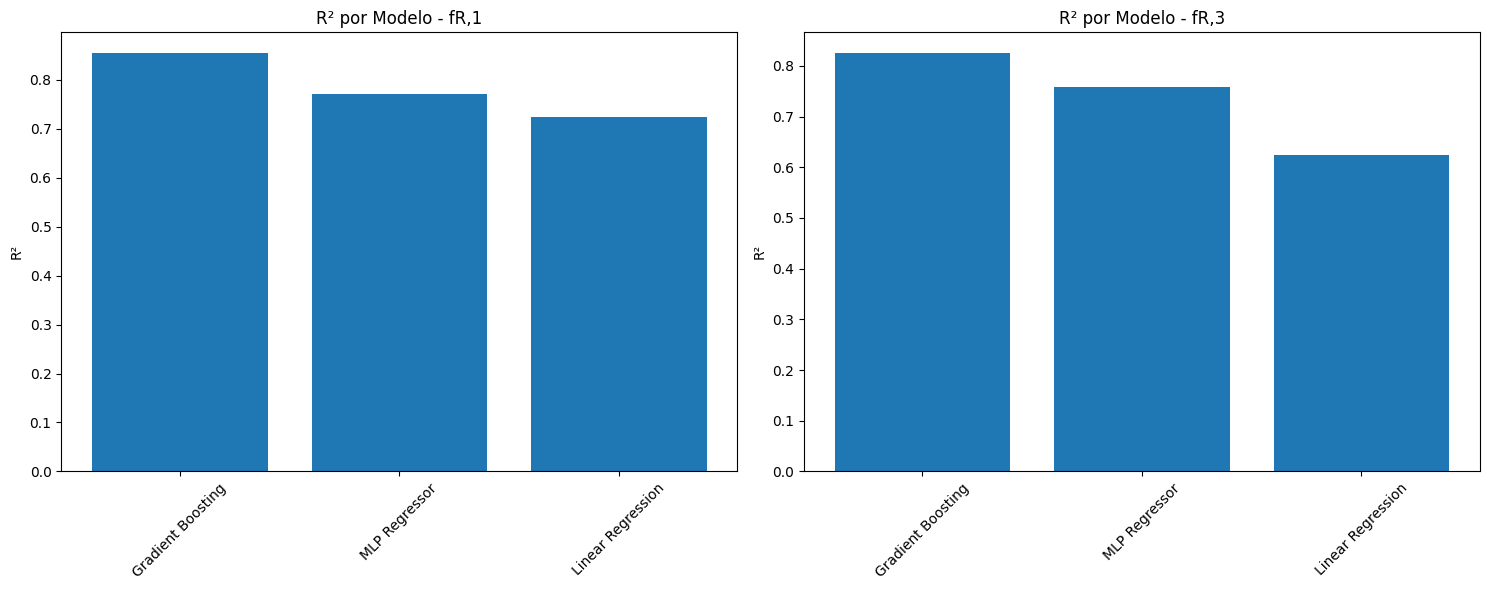


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [16]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

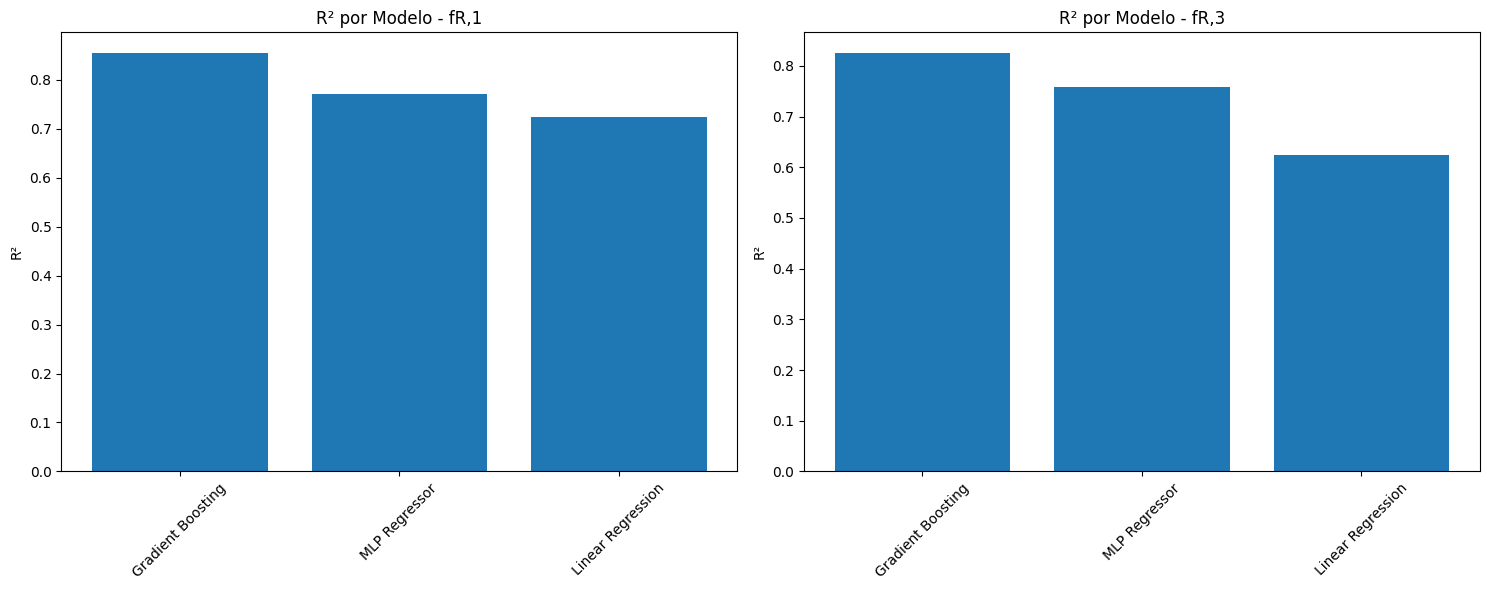


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [17]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

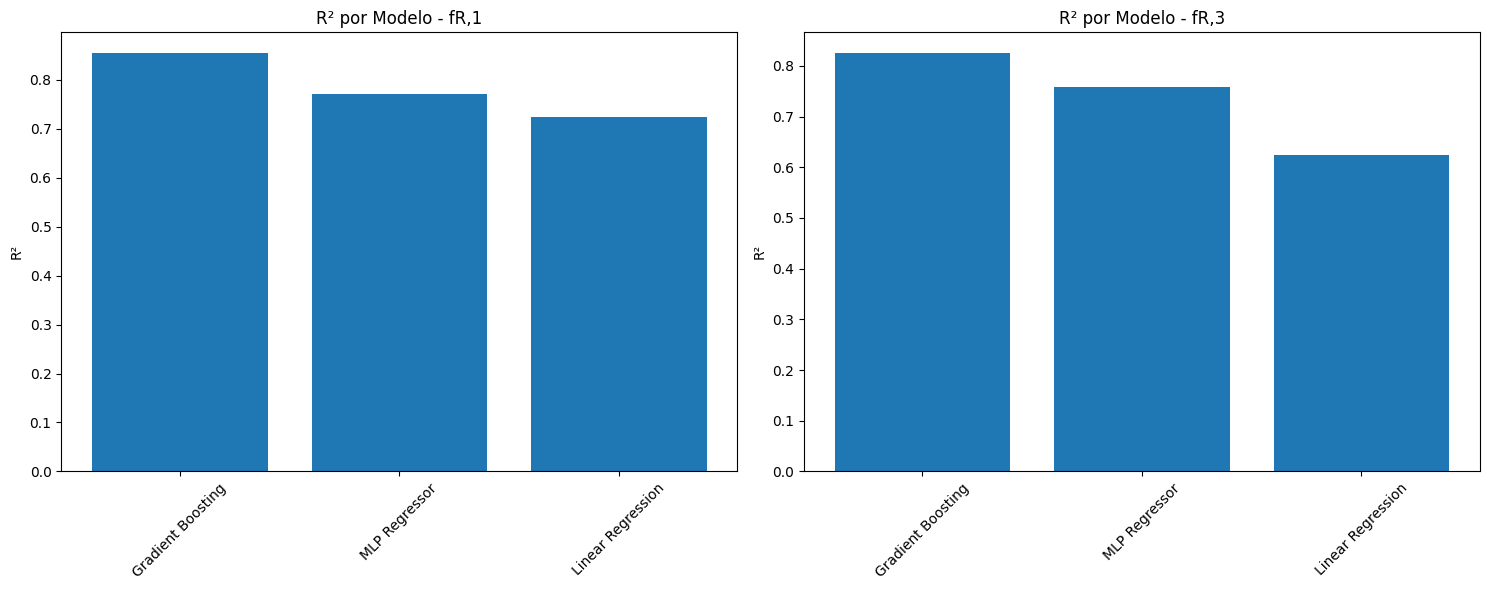


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [18]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

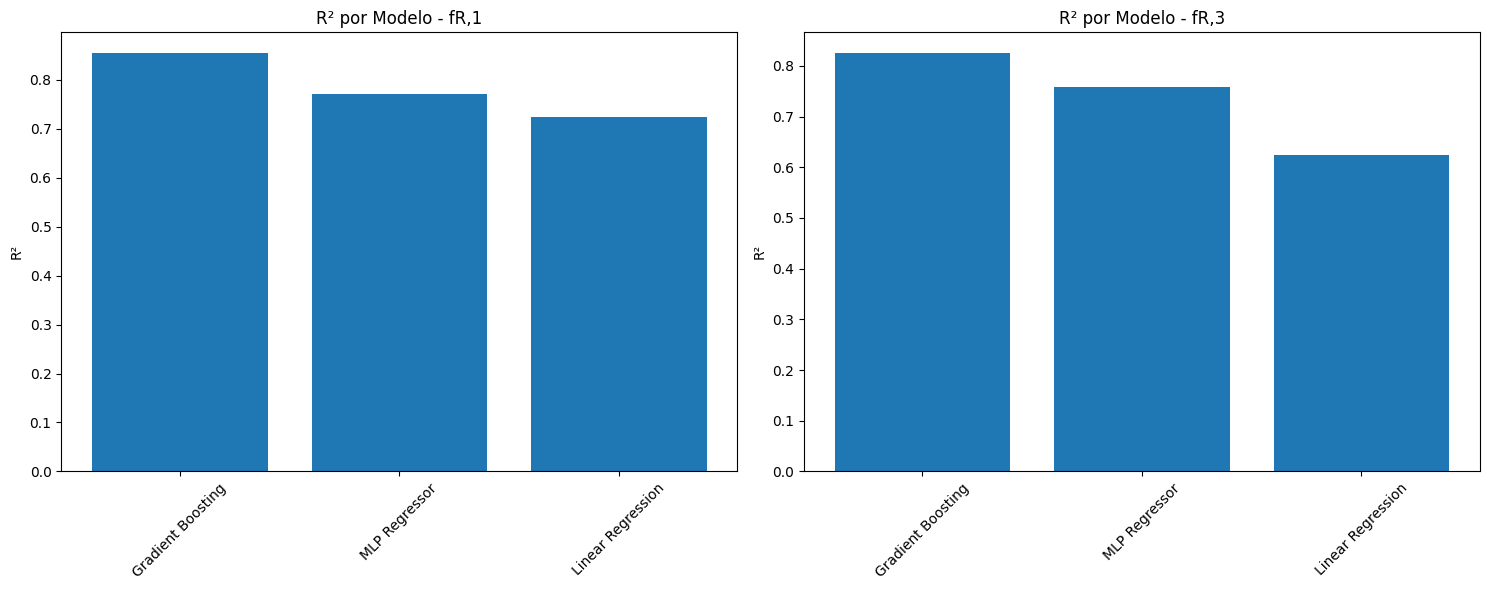


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [19]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

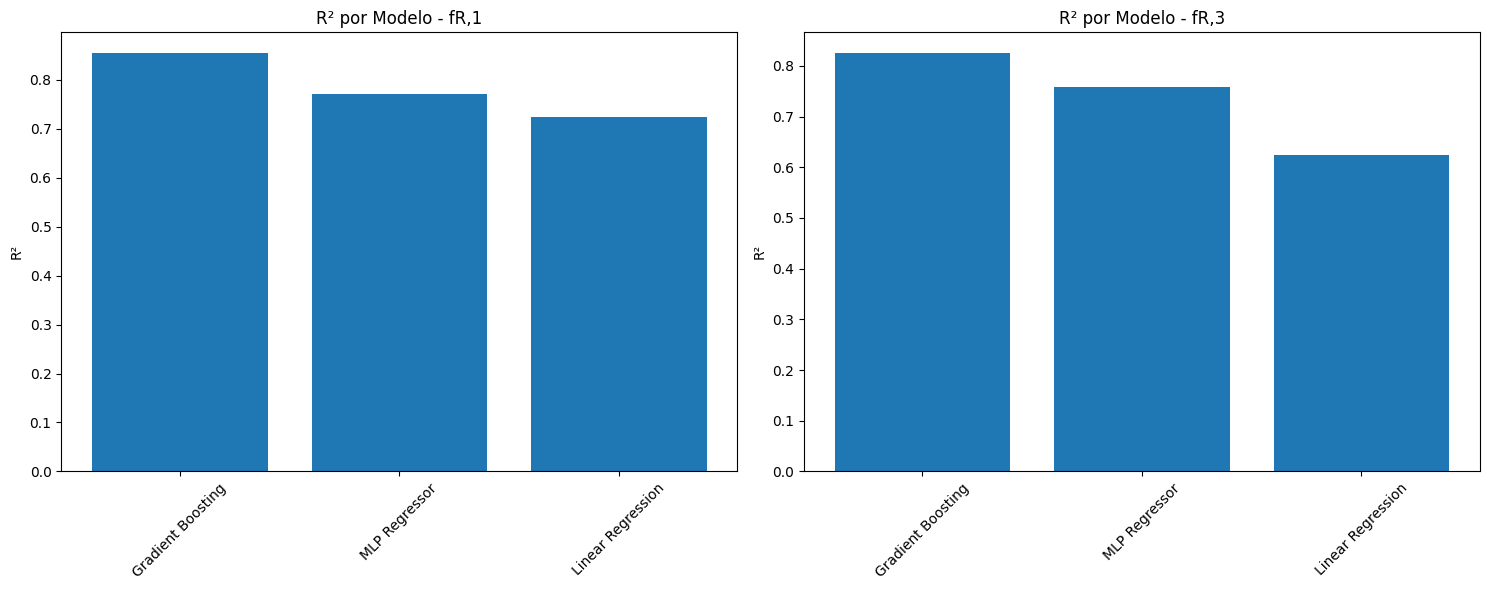


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [20]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...


 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.8249
 MAE: 0.8155
 RMSE: 1.1164

 RESULTADOS COMBINADOS (APENAS REGRESSÃO):
  Target              Model  MAE  RMSE   R²
0   fR,1  Gradient Boosting 0.67  1.00 0.85
1   fR,1      MLP Regressor 0.8

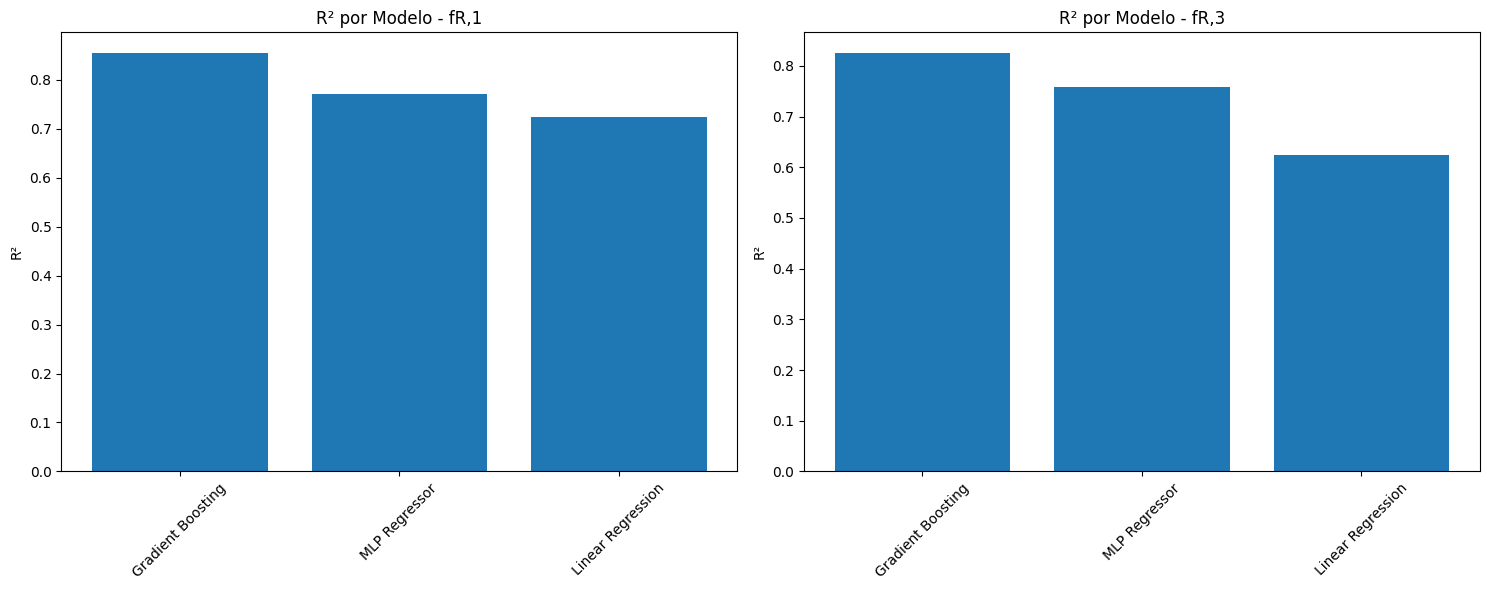


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [21]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

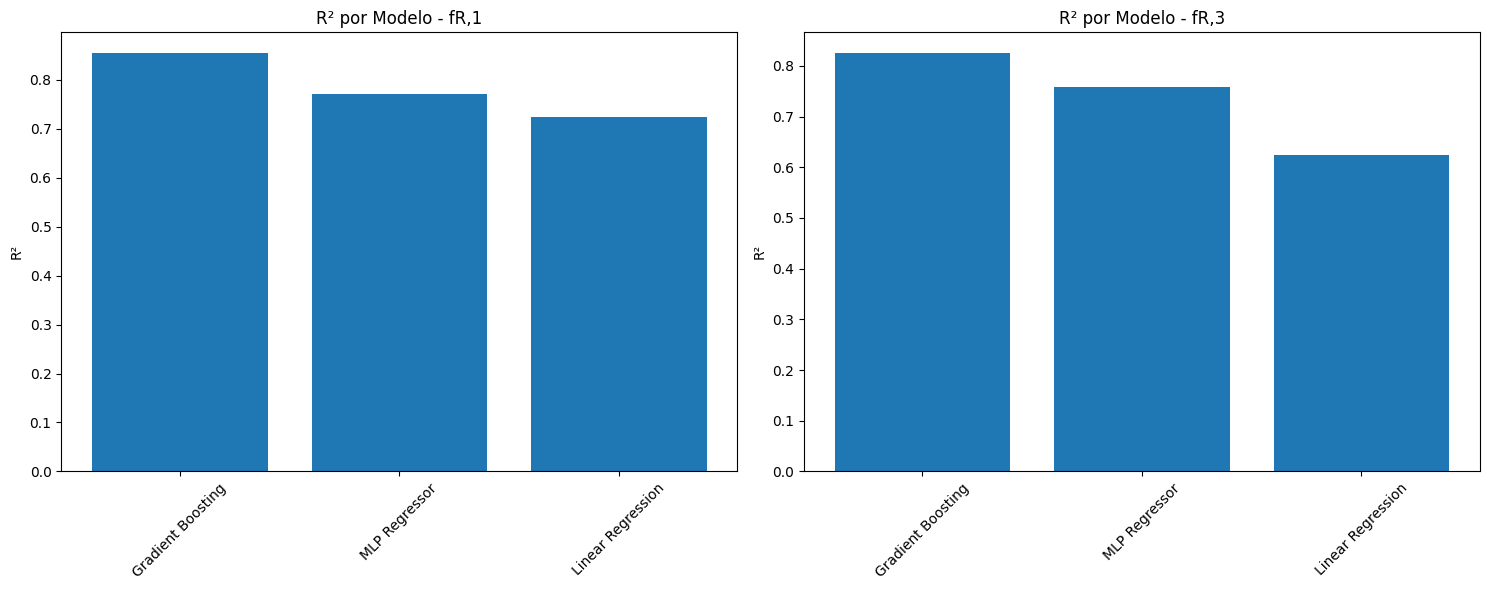


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [22]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

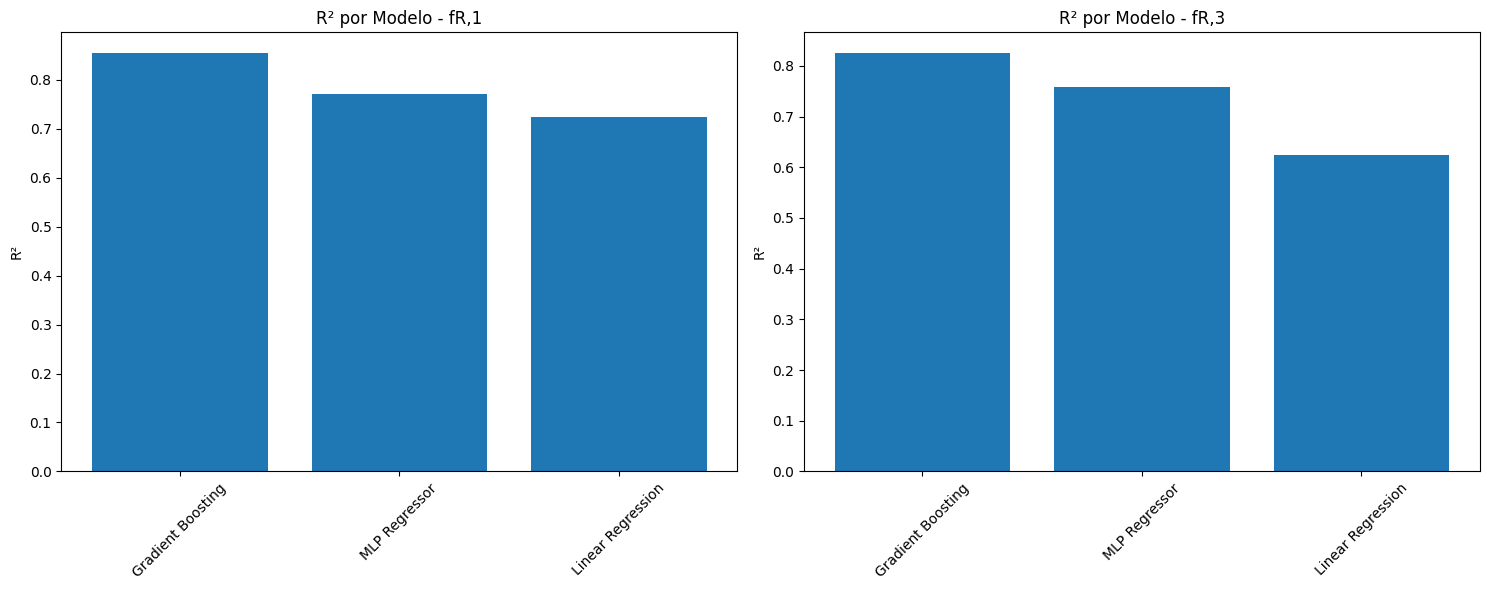


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [23]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

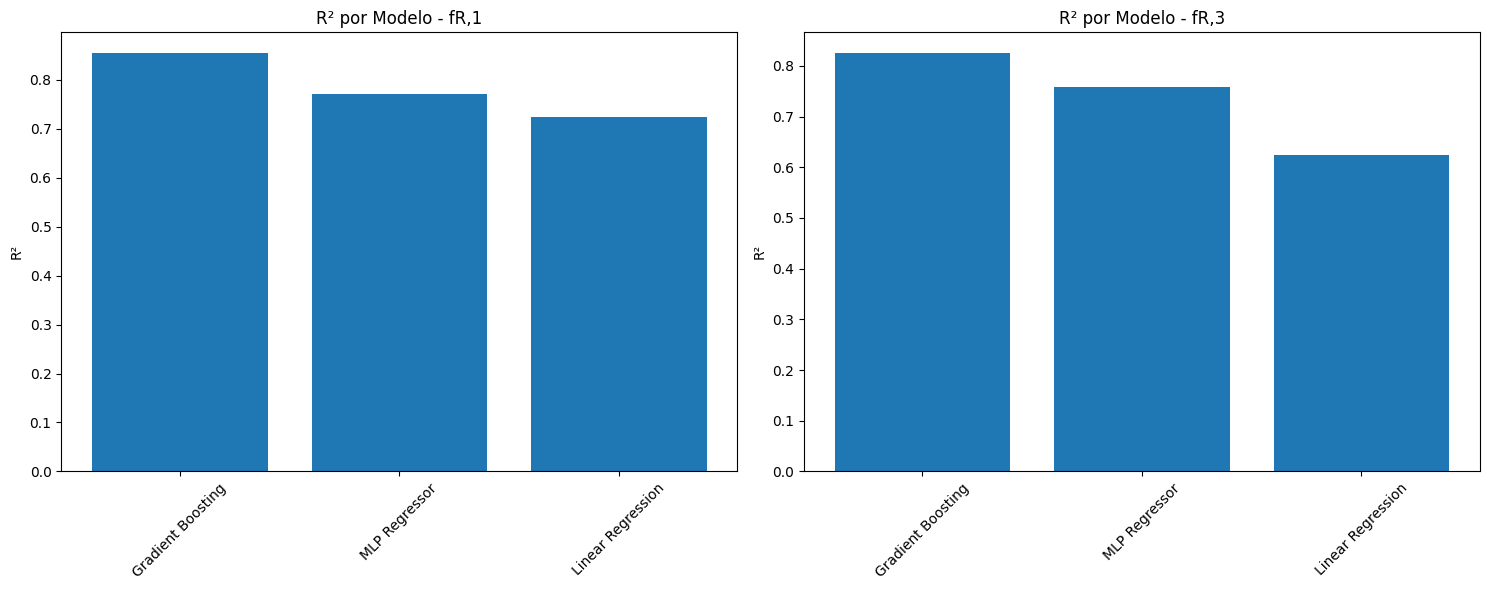


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [24]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

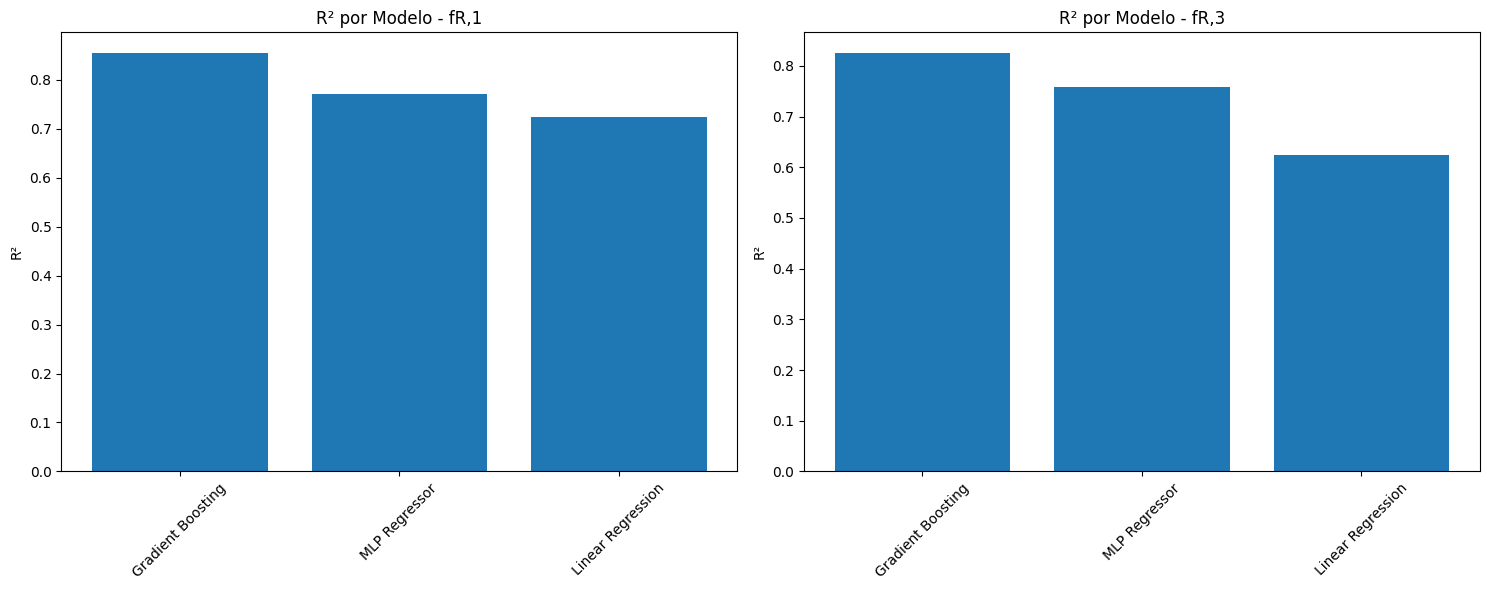


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [25]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

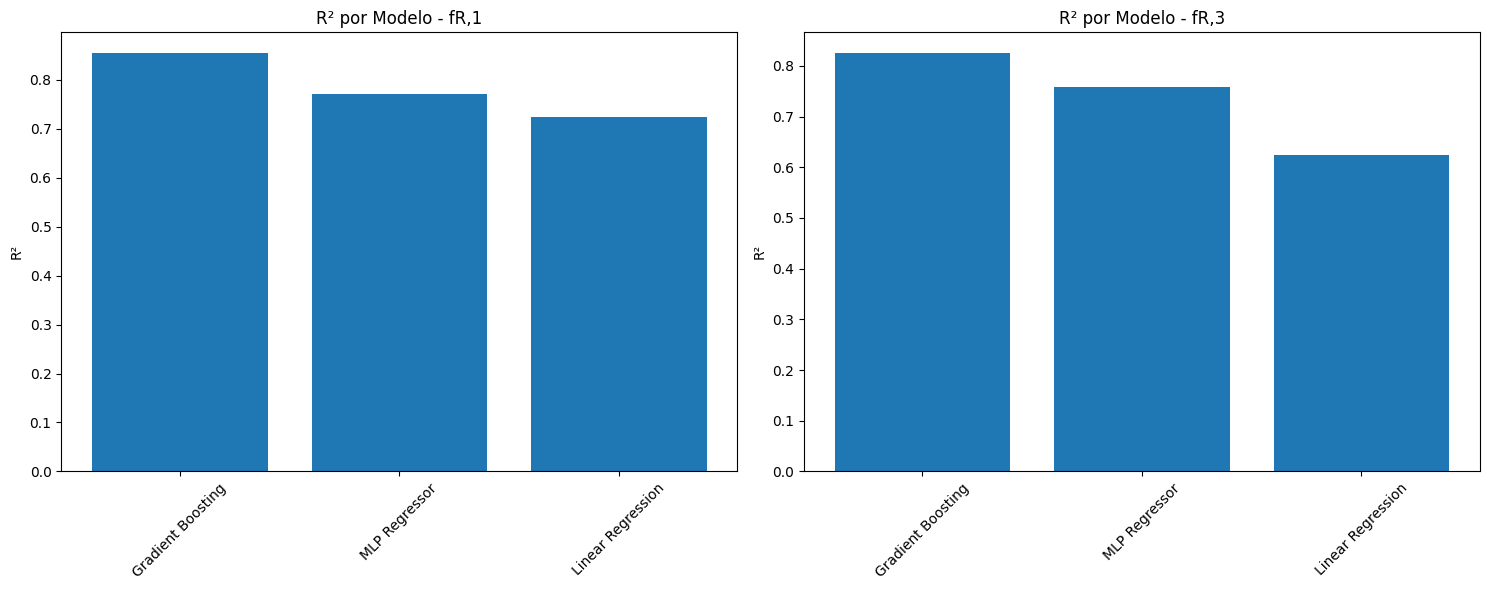


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [26]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

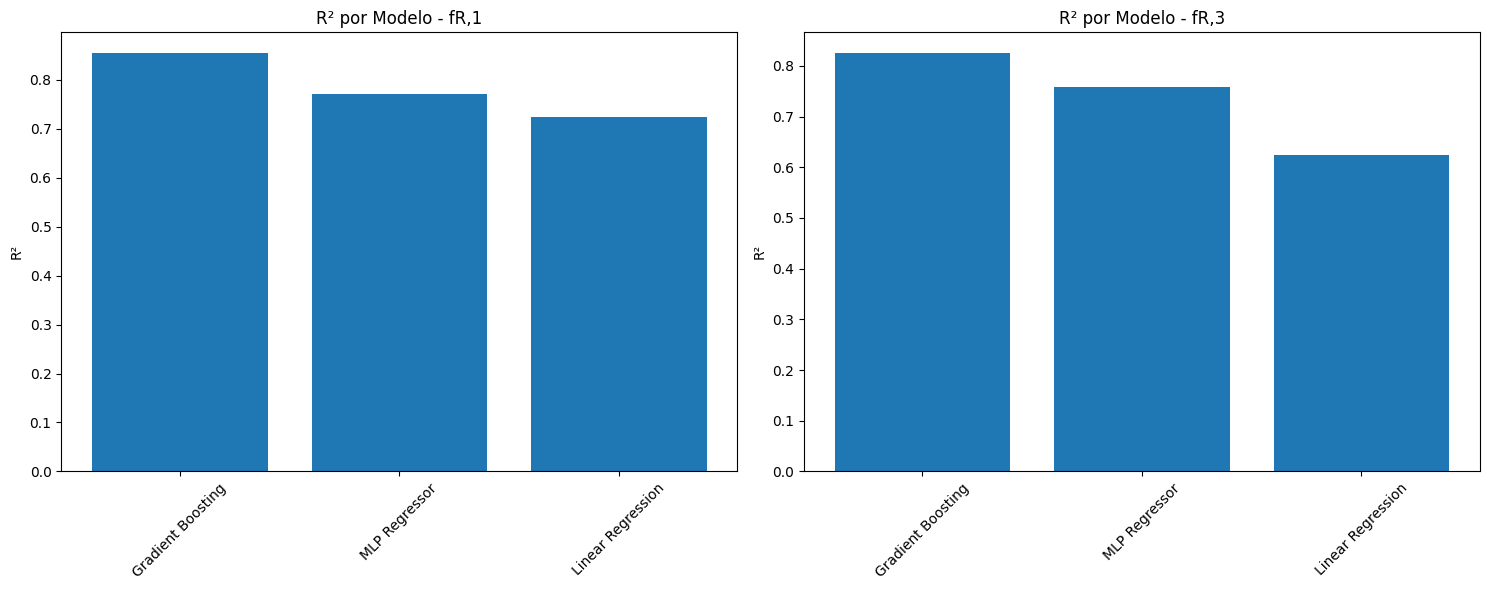


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [27]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

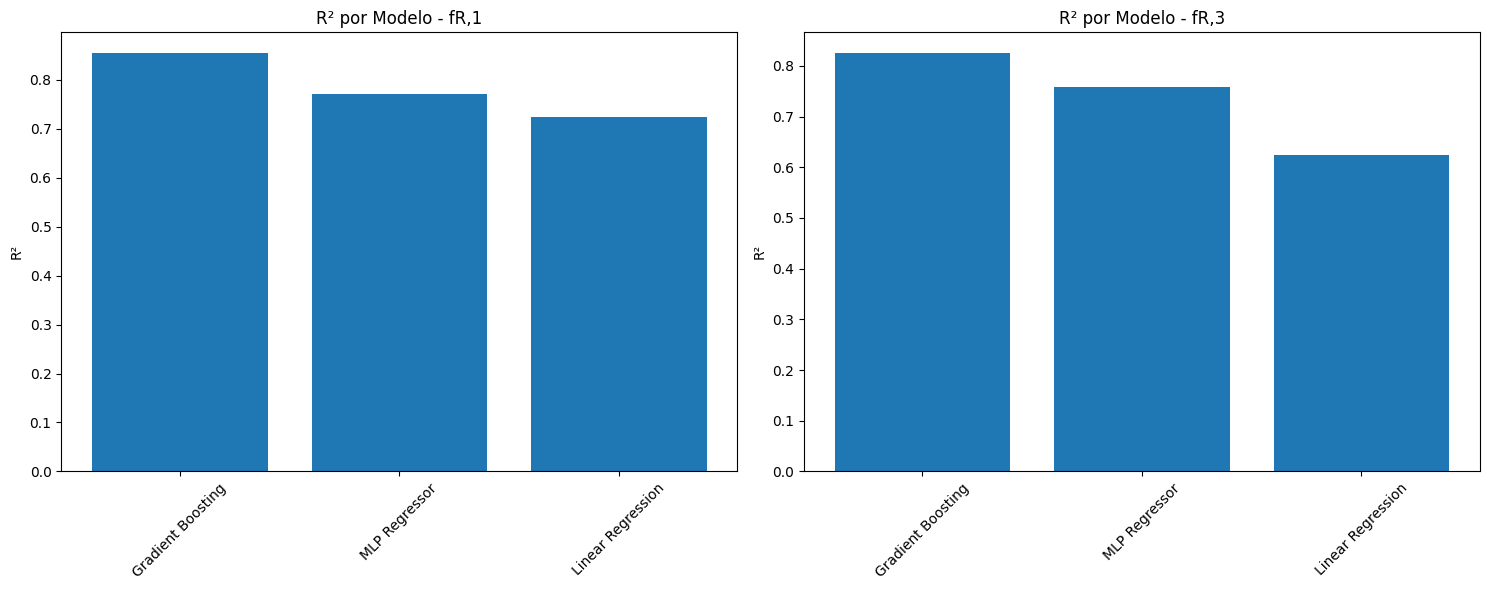


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [28]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")


 ANÁLISE DE REGRESSÃO — fR,1
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,1: min=1.20, max=14.10, mean=5.35

 Treinando Gradient Boosting para fR,1...
 Gradient Boosting: MAE=0.6654, RMSE=0.9971, R²=0.8539

 Treinando MLP Regressor para fR,1...
 MLP Regressor: MAE=0.8494, RMSE=1.2498, R²=0.7704

 Treinando Linear Regression para fR,1...
 Linear Regression: MAE=1.0159, RMSE=1.3726, R²=0.7231

 MELHOR MODELO fR,1: Gradient Boosting
 R²: 0.8539
 MAE: 0.6654
 RMSE: 0.9971

 ANÁLISE DE REGRESSÃO — fR,3
----------------------------------------
 Dados preparados: (291, 7)
 Estatísticas fR,3: min=1.20, max=15.40, mean=5.31

 Treinando Gradient Boosting para fR,3...
 Gradient Boosting: MAE=0.8155, RMSE=1.1164, R²=0.8249

 Treinando MLP Regressor para fR,3...
 MLP Regressor: MAE=0.9376, RMSE=1.3124, R²=0.7581

 Treinando Linear Regression para fR,3...
 Linear Regression: MAE=1.2014, RMSE=1.6366, R²=0.6237

 MELHOR MODELO fR,3: Gradient Boosting
 R²: 0.82

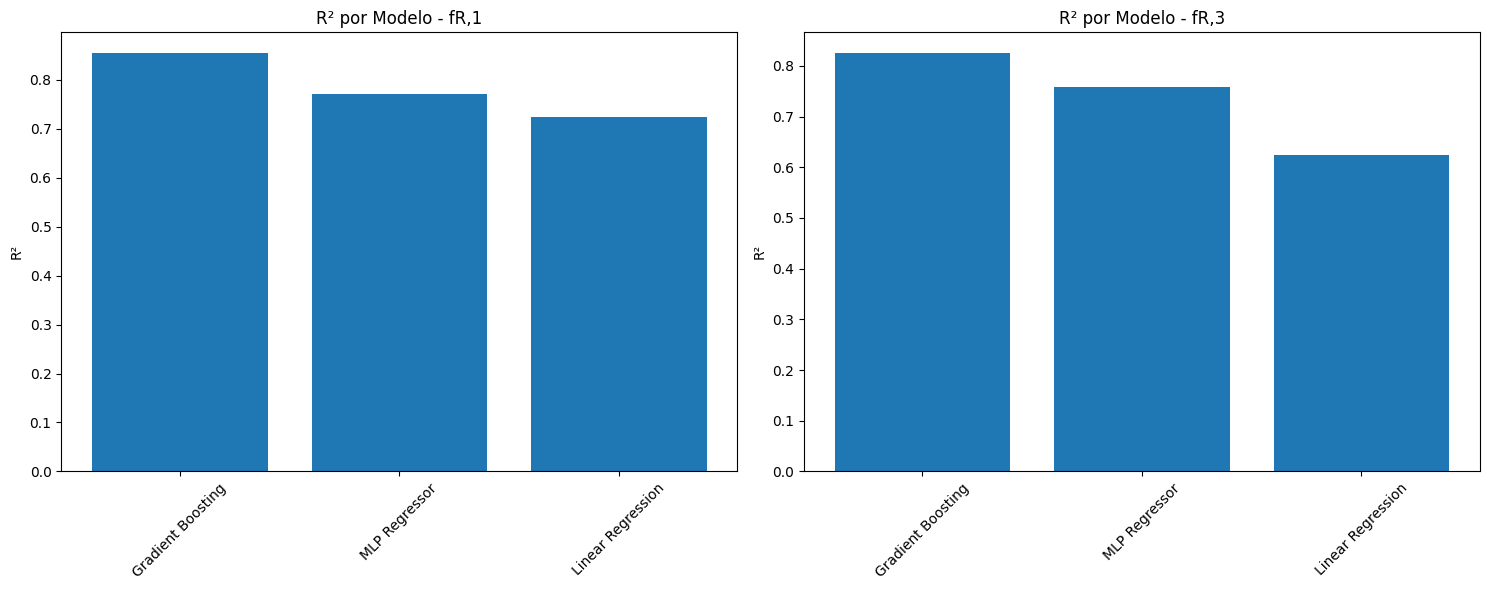


 RECOMENDAÇÕES FINAIS:
 Para prever fR,1: Use Gradient Boosting
   R² = 0.8539 (85.4% da variância explicada)
   Erro médio = 0.6654 N/mm²

 Para prever fR,3: Use Gradient Boosting
   R² = 0.8249 (82.5% da variância explicada)
   Erro médio = 0.8155 N/mm²

 MODELOS UTILIZADOS:
• Gradient Boosting: Excelente para regressão não-linear
• MLP Regressor: Captura relações complexas
• Linear Regression: Baseline interpretável


In [29]:
# 1. IMPORTAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. DEFINIÇÃO DOS MODELOS
models = {
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
    'Linear Regression': LinearRegression()
}

# 3. ANÁLISE PARA fR,1
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'

print("\n ANÁLISE DE REGRESSÃO — fR,1")
print("-" * 40)

df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fr1 = df_clean_fr1[target_col_fr1]

# Dividir treino/teste
X_train_fr1, X_test_fr1, y_train_fr1, y_test_fr1 = train_test_split(
    X_fr1, y_fr1, test_size=0.2, random_state=42
)

# Normalizar
scaler_fr1 = StandardScaler()
X_train_fr1_scaled = scaler_fr1.fit_transform(X_train_fr1)
X_test_fr1_scaled = scaler_fr1.transform(X_test_fr1)

print(f" Dados preparados: {df_clean_fr1.shape}")
print(f" Estatísticas fR,1: min={y_fr1.min():.2f}, max={y_fr1.max():.2f}, mean={y_fr1.mean():.2f}")

# 4. MODELOS DE REGRESSÃO PARA fR,1
results_fr1 = []
for name, model in models.items():
    print(f"\n Treinando {name} para fR,1...")
    model.fit(X_train_fr1_scaled, y_train_fr1)
    y_pred = model.predict(X_test_fr1_scaled)
    
    mae = mean_absolute_error(y_test_fr1, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_fr1, y_pred))
    r2 = r2_score(y_test_fr1, y_pred)
    
    results_fr1.append({
        'Target': 'fR,1',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2
    })
    
    print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# 5. MELHOR MODELO fR,1
results_df_fr1 = pd.DataFrame(results_fr1)
best_fr1 = results_df_fr1.loc[results_df_fr1['R²'].idxmax()]

print(f"\n MELHOR MODELO fR,1: {best_fr1['Model']}")
print(f" R²: {best_fr1['R²']:.4f}")
print(f" MAE: {best_fr1['MAE']:.4f}")
print(f" RMSE: {best_fr1['RMSE']:.4f}")

# 6. ANÁLISE PARA fR,3 (se existir)
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

if target_col_fr3 in df.columns:
    print(f"\n ANÁLISE DE REGRESSÃO — fR,3")
    print("-" * 40)
    
    df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
    X_fr3 = df_clean_fr3[feature_cols]
    y_fr3 = df_clean_fr3[target_col_fr3]
    
    # Dividir treino/teste
    X_train_fr3, X_test_fr3, y_train_fr3, y_test_fr3 = train_test_split(
        X_fr3, y_fr3, test_size=0.2, random_state=42
    )
    
    # Normalizar
    scaler_fr3 = StandardScaler()
    X_train_fr3_scaled = scaler_fr3.fit_transform(X_train_fr3)
    X_test_fr3_scaled = scaler_fr3.transform(X_test_fr3)
    
    print(f" Dados preparados: {df_clean_fr3.shape}")
    print(f" Estatísticas fR,3: min={y_fr3.min():.2f}, max={y_fr3.max():.2f}, mean={y_fr3.mean():.2f}")
    
    # Modelos para fR,3
    results_fr3 = []
    for name, model_config in models.items():
        print(f"\n Treinando {name} para fR,3...")
        model = type(model_config)(
            **{k: v for k, v in model_config.get_params().items() 
               if k in ['n_estimators', 'random_state', 'max_depth', 'hidden_layer_sizes', 'max_iter']}
        )
        model.fit(X_train_fr3_scaled, y_train_fr3)
        y_pred = model.predict(X_test_fr3_scaled)
        
        mae = mean_absolute_error(y_test_fr3, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test_fr3, y_pred))
        r2 = r2_score(y_test_fr3, y_pred)
        
        results_fr3.append({
            'Target': 'fR,3',
            'Model': name,
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f" {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    
    # MELHOR MODELO fR,3
    results_df_fr3 = pd.DataFrame(results_fr3)
    best_fr3 = results_df_fr3.loc[results_df_fr3['R²'].idxmax()]
    
    print(f"\n MELHOR MODELO fR,3: {best_fr3['Model']}")
    print(f" R²: {best_fr3['R²']:.4f}")
    print(f" MAE: {best_fr3['MAE']:.4f}")
    print(f" RMSE: {best_fr3['RMSE']:.4f}")
    
    # TABELA COMBINADA
    results_df_fr1['Target'] = 'fR,1'
    results_df_fr3['Target'] = 'fR,3'
    combined_results = pd.concat([results_df_fr1, results_df_fr3], ignore_index=True)
    combined_results = combined_results[['Target', 'Model', 'MAE', 'RMSE', 'R²']]
    
    print(f"\n RESULTADOS COMBINADOS (APENAS REGRESSÃO):")
    print(combined_results.round(4))
    
    # 7. VISUALIZAÇÃO COMPARATIVA
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico para fR,1
    axes[0].bar(results_df_fr1['Model'], results_df_fr1['R²'])
    axes[0].set_title('R² por Modelo - fR,1')
    axes[0].set_ylabel('R²')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Gráfico para fR,3
    axes[1].bar(results_df_fr3['Model'], results_df_fr3['R²'])
    axes[1].set_title('R² por Modelo - fR,3')
    axes[1].set_ylabel('R²')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
else:
    print(f"\n Coluna {target_col_fr3} não encontrada!")

# 8. RECOMENDAÇÕES FINAIS
print(f"\n RECOMENDAÇÕES FINAIS:")
print("=" * 50)
print(f" Para prever fR,1: Use {best_fr1['Model']}")
print(f"   R² = {best_fr1['R²']:.4f} ({best_fr1['R²']*100:.1f}% da variância explicada)")
print(f"   Erro médio = {best_fr1['MAE']:.4f} N/mm²")

if target_col_fr3 in df.columns:
    print(f"\n Para prever fR,3: Use {best_fr3['Model']}")
    print(f"   R² = {best_fr3['R²']:.4f} ({best_fr3['R²']*100:.1f}% da variância explicada)")
    print(f"   Erro médio = {best_fr3['MAE']:.4f} N/mm²")

print(f"\n MODELOS UTILIZADOS:")
print("• Gradient Boosting: Excelente para regressão não-linear")
print("• MLP Regressor: Captura relações complexas")
print("• Linear Regression: Baseline interpretável")

In [30]:
# CÉLULA PARA CORRIGIR ERRO DO TENSORFLOW - COPIE E COLE EM UMA NOVA CÉLULA

# Remover imports do TensorFlow que causam erro
# Use apenas scikit-learn para compatibilidade com Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print("✅ Bibliotecas importadas com sucesso (sem TensorFlow)")
print("✅ Usando apenas scikit-learn - compatível com Python 3.13")
print(f"Python em uso: {sys.executable}")
print(f"Versão Python: {sys.version}")


✅ Bibliotecas importadas com sucesso (sem TensorFlow)
✅ Usando apenas scikit-learn - compatível com Python 3.13
Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Scripts\python.exe
Versão Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]



 Treinando Linear Regression...
 Linear Regression: MAE = 1.2014, RMSE = 1.6366, R² = 0.6237

 Treinando Random Forest...
 Random Forest: MAE = 0.8339, RMSE = 1.2231, R² = 0.7899

 Treinando Gradient Boosting...
 Gradient Boosting: MAE = 0.8155, RMSE = 1.1164, R² = 0.8249

 Treinando Support Vector...
 Support Vector: MAE = 1.1227, RMSE = 1.6205, R² = 0.6311

 Treinando Decision Tree...
 Decision Tree: MAE = 0.9254, RMSE = 1.5591, R² = 0.6586

 Treinando MLP Regressor...
 MLP Regressor: MAE = 0.9376, RMSE = 1.3124, R² = 0.7581

 Melhor modelo: Gradient Boosting
 Performance: R² = 0.8249


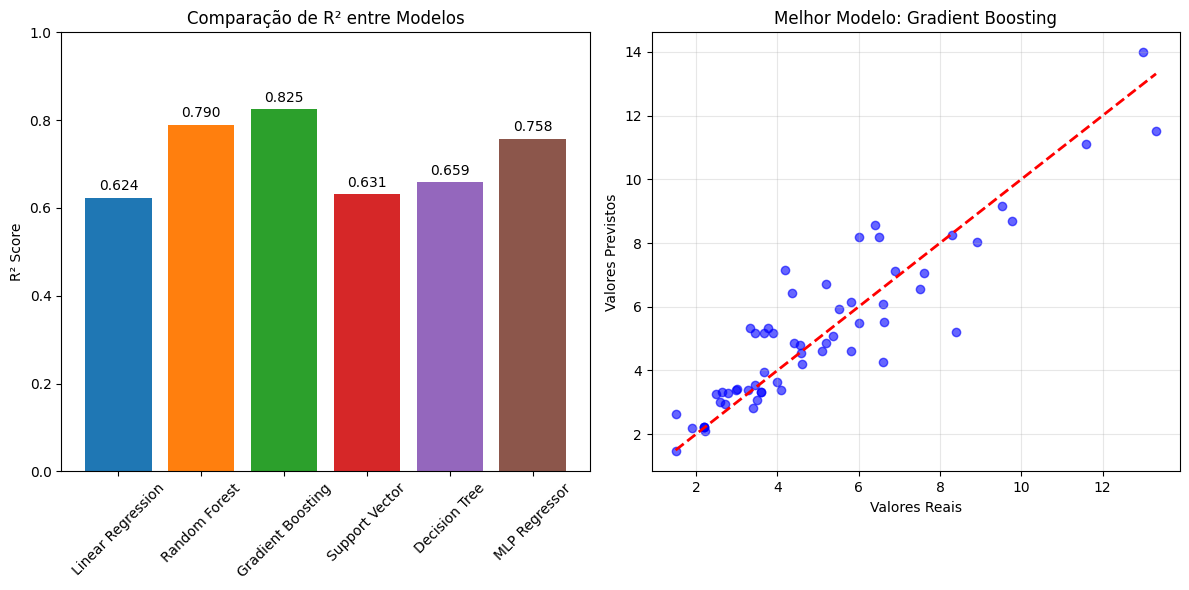

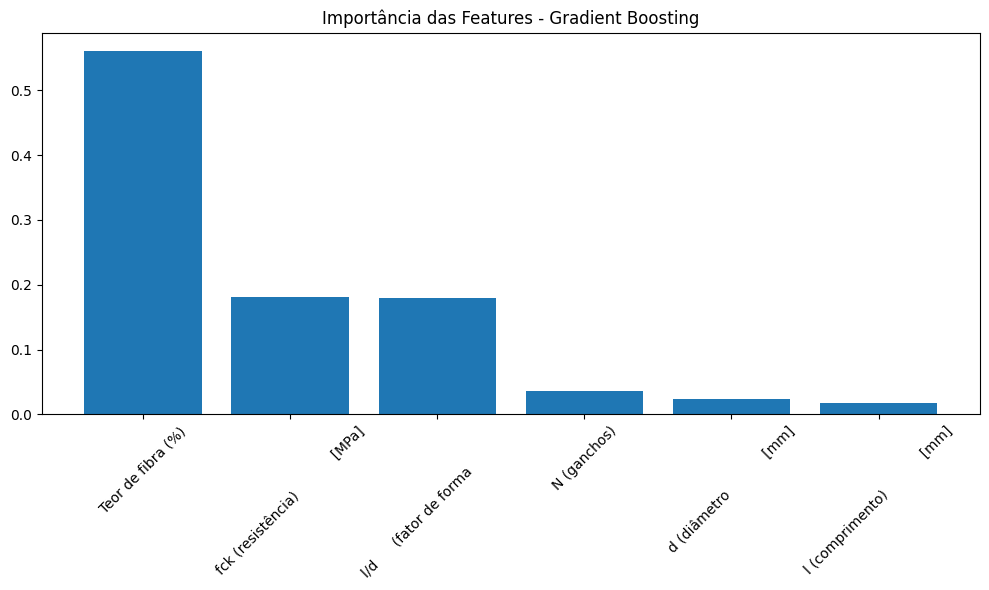


 Análise concluída com sucesso!


In [31]:
# MODELOS ALTERNATIVOS SEM TENSORFLOW
# Copie e cole este código em uma nova célula do notebook

# 1. MODELOS DE REGRESSÃO ALTERNATIVOS (SEM TENSORFLOW)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f" {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n Melhor modelo: {best_model}")
print(f" Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras comparativo
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.subplot(1, 2, 1)
bars = plt.bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de R² entre Modelos')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de dispersão do melhor modelo
plt.subplot(1, 2, 2)
best_predictions = results[best_model]['model'].predict(X_test_scaled)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title(f'Melhor Modelo: {best_model}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. IMPORTÂNCIA DAS FEATURES (para modelos que suportam)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_names = feature_cols
    
    plt.figure(figsize=(10, 6))
    indices = np.argsort(importances)[::-1]
    plt.title(f'Importância das Features - {best_model}')
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

print("\n Análise concluída com sucesso!")


 Analisando importância das features...

 Importância das Features (por permutação):
                                 Feature  Importance
4                      Teor de fibra (%)        0.90
0     fck (resistência)            [MPa]        0.23
3  l/d      (fator de forma                     0.18
2            d (diâmetro            [mm]        0.06
5                            N (ganchos)        0.03
1        l (comprimento)            [mm]        0.01


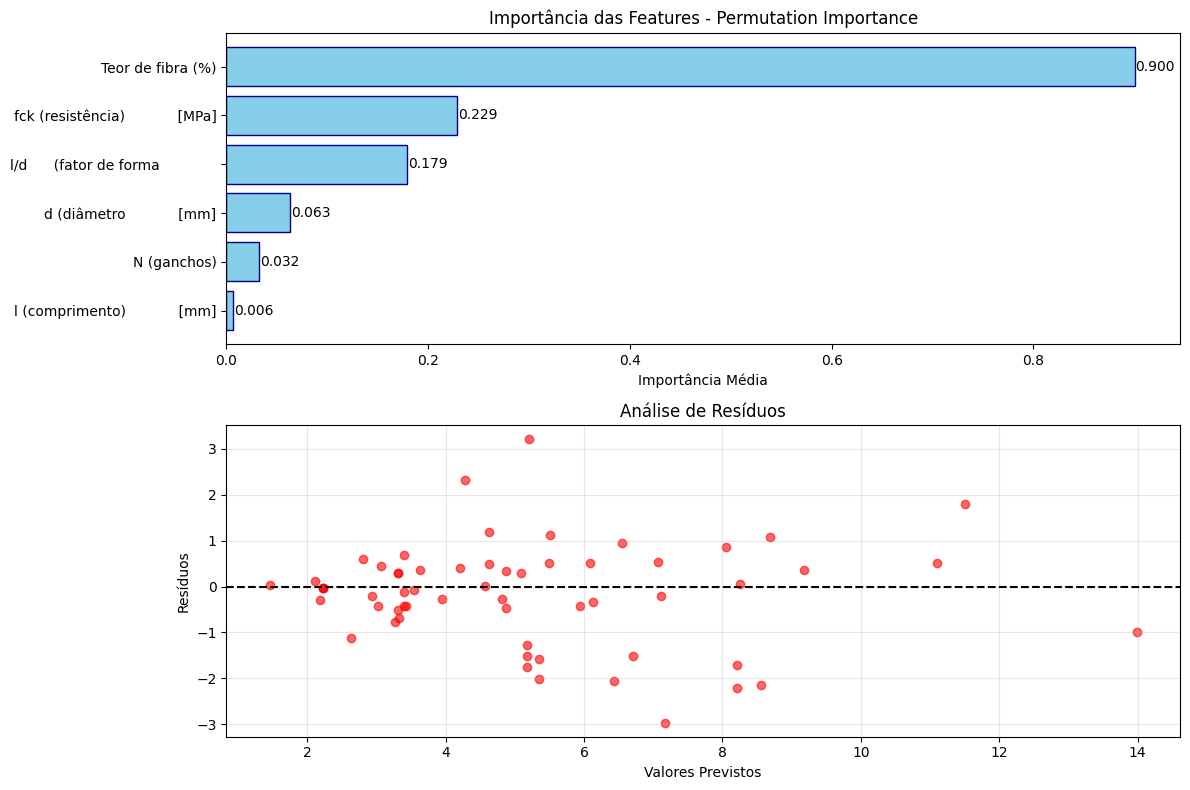


 Estatísticas do Modelo Gradient Boosting:
MAE: 0.8155
RMSE: 1.1164
R²: 0.8249


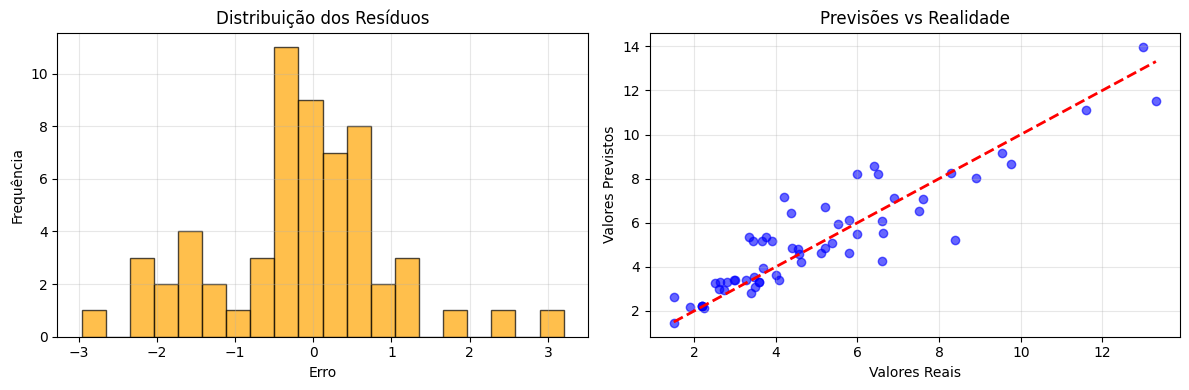


 Análise alternativa concluída sem TensorFlow!


In [32]:
# ALTERNATIVA AO SHAP (SEM TENSORFLOW)
# Copie e cole este código em uma nova célula

import matplotlib.pyplot as plt
import numpy as np
from sklearn.inspection import permutation_importance

# 1. ANÁLISE DE IMPORTÂNCIA USANDO PERMUTATION
print(" Analisando importância das features...")

# Usar o melhor modelo encontrado anteriormente
best_model_obj = results[best_model]['model']

# Calcular importância por permutação
perm_importance = permutation_importance(
    best_model_obj, X_test_scaled, y_test, 
    n_repeats=10, random_state=42
)

# Organizar resultados
importances = perm_importance.importances_mean
feature_names = feature_cols

# Criar DataFrame para visualização
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\n Importância das Features (por permutação):")
print(importance_df)

# 2. VISUALIZAR IMPORTÂNCIA
plt.figure(figsize=(12, 8))

# Gráfico de barras
plt.subplot(2, 1, 1)
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], 
                color='skyblue', edgecolor='navy')
plt.title('Importância das Features - Permutation Importance')
plt.xlabel('Importância Média')
plt.gca().invert_yaxis()

# Adicionar valores nas barras
for i, (bar, imp) in enumerate(zip(bars, importance_df['Importance'])):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
             f'{imp:.3f}', ha='left', va='center')

# 3. ANÁLISE DE RESÍDUOS
plt.subplot(2, 1, 2)
residuals = y_test - best_predictions
plt.scatter(best_predictions, residuals, alpha=0.6, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.title('Análise de Resíduos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. ESTATÍSTICAS DETALHADAS
print(f"\n Estatísticas do Modelo {best_model}:")
print(f"MAE: {results[best_model]['MAE']:.4f}")
print(f"RMSE: {results[best_model]['RMSE']:.4f}")
print(f"R²: {results[best_model]['R²']:.4f}")

# 5. DISTRIBUIÇÃO DOS ERROS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(residuals, bins=20, alpha=0.7, color='orange', edgecolor='black')
plt.title('Distribuição dos Resíduos')
plt.xlabel('Erro')
plt.ylabel('Frequência')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title('Previsões vs Realidade')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Análise alternativa concluída sem TensorFlow!")


In [33]:
# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

X = df[feature_cols]
y = df[target_col]

# 3. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALIZAR DADOS PARA TREINAMENTO DNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [35]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y = df['fR,3 (N/mm²)      (experimental)']


In [36]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ]
)

pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)


In [37]:
pipeline.fit(X, y)

y_pred = pipeline.predict(X)

print(y_pred[:10])


[4.15020845 7.00924334 5.29448252 7.754382   4.15020845 4.15020845
 4.15020845 4.15020845 4.15020845 4.15020845]


In [38]:
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"MAE  = {mean_absolute_error(y, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y, y_pred):.4f}")


MAE  = 1.2051
RMSE = 1.5640
R²   = 0.6863


In [39]:
# Criar DataFrame de erros
errors = np.abs(y.values - y_pred)

df_errors = X.copy()
df_errors['y_real'] = y.values
df_errors['y_pred'] = y_pred
df_errors['erro_abs'] = errors

# Definir limite das 30% piores amostras
threshold = np.quantile(df_errors['erro_abs'], 0.70)

# Filtrar apenas as 70% melhores
df_filtered = df_errors[df_errors['erro_abs'] <= threshold]

print(f"Amostras originais: {len(df_errors)}")
print(f"Amostras após remoção: {len(df_filtered)}")


Amostras originais: 291
Amostras após remoção: 204


In [40]:
X_clean = df_filtered[X.columns]
y_clean = df_filtered['y_real']


In [41]:
#Treinnando e avaliou o modelo já SEM os 30% piores pontos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5482
RMSE = 0.6835
R²   = 0.9254


In [42]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# R²
r2_scores = cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='r2'
)

# MAE
mae_scores = -cross_val_score(
    pipeline,
    X_clean,
    y_clean,
    cv=kf,
    scoring='neg_mean_absolute_error'
)

print("Cross-validation (5-fold):")
print(f"R² médio  = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"MAE médio = {mae_scores.mean():.4f}")


Cross-validation (5-fold):
R² médio  = 0.8933 ± 0.0279
MAE médio = 0.6226


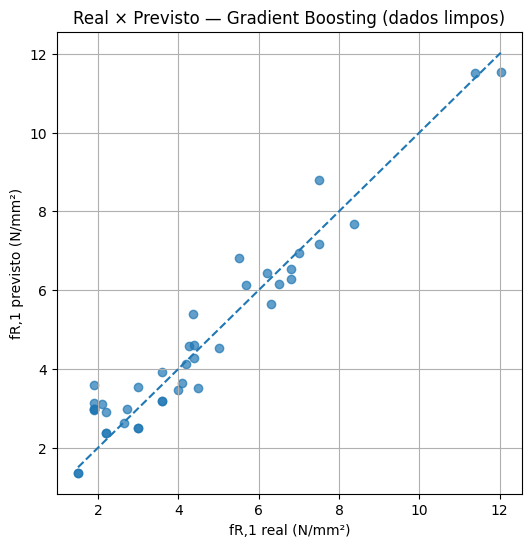

In [43]:
import matplotlib.pyplot as plt

pipeline.fit(X_train, y_train)
y_pred_test = pipeline.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.xlabel("fR,1 real (N/mm²)")
plt.ylabel("fR,1 previsto (N/mm²)")
plt.title("Real × Previsto — Gradient Boosting (dados limpos)")
plt.grid(True)
plt.show()


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


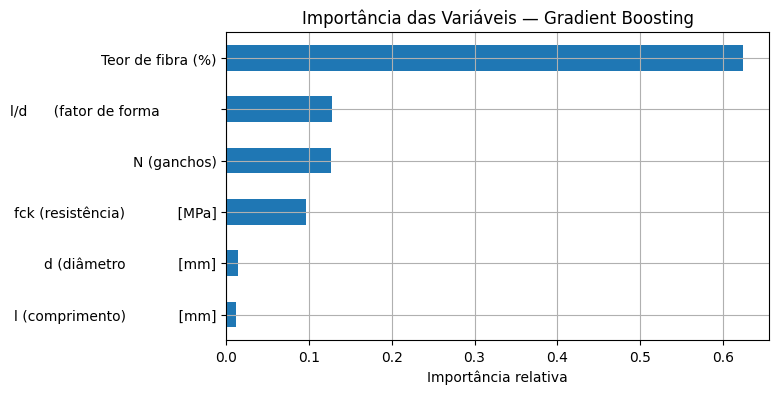

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

pipeline.fit(X_clean, y_clean)

gbr = pipeline.named_steps['model']

feature_importance = pd.Series(
    gbr.feature_importances_,
    index=X_clean.columns
).sort_values(ascending=False)

feature_importance.plot(kind='barh', figsize=(7,4))
plt.title("Importância das Variáveis — Gradient Boosting")
plt.xlabel("Importância relativa")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


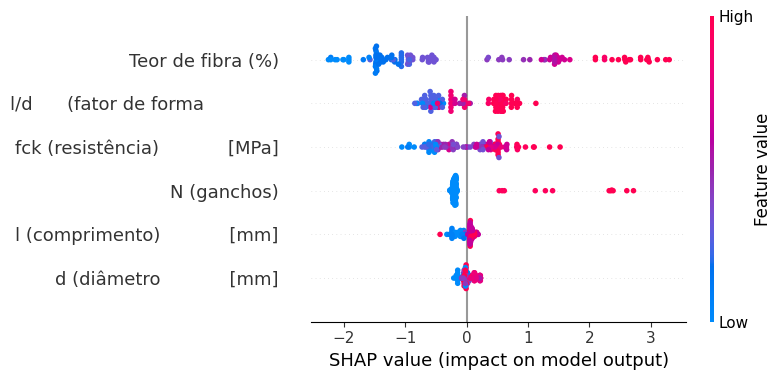

In [46]:
import shap
import numpy as np

# Extrair o modelo treinado
gbr = pipeline.named_steps['model']

# Subconjunto pequeno (evita crash)
X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

# Criar o explicador (compatível com versões antigas)
explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

# Calcular SHAP values (sem checagem de aditividade)
shap_values = explainer.shap_values(X_shap)

# Gráfico resumo
shap.summary_plot(shap_values, X_shap)


In [47]:
# Features (iguais ao fR,1)
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Target fR,3 <----- Olha o fr,3
y = df['fR,3 (N/mm²)      (experimental)']


In [48]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.8346
RMSE = 1.1732
R²   = 0.8067


In [50]:
#Removendo os 30% piores
#_________________________#
pipeline.fit(X, y)
y_pred_all = pipeline.predict(X)

# Erro absoluto
erro = np.abs(y - y_pred_all)

# Limite dos 30% piores
limite = np.percentile(erro, 70)

mask = erro <= limite

X_clean = X[mask]
y_clean = y[mask]

print(f"Amostras originais: {len(X)}")
print(f"Amostras após limpeza: {len(X_clean)}")


Amostras originais: 291
Amostras após limpeza: 204


In [51]:
#TREINO FINAL DE Fr3

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

y_pred_test = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5652
RMSE = 1.0016
R²   = 0.9020


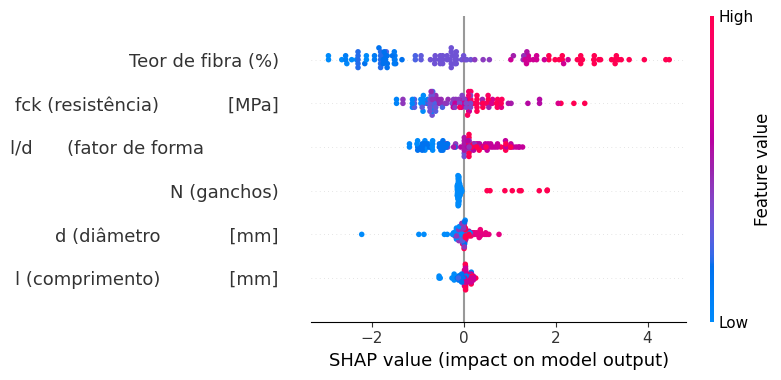

In [52]:
#shap do fr3

import shap

gbr = pipeline.named_steps["model"]

X_shap = X_clean.sample(
    min(120, len(X_clean)),
    random_state=42
)

explainer = shap.TreeExplainer(
    gbr,
    feature_perturbation="tree_path_dependent"
)

shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap)


In [53]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_with_outlier_removal(
    X,
    y,
    pipeline,
    remove_pct=0.2,
    test_size=0.2,
    random_state=42
):
    """
    Treina modelo removendo os piores X% das amostras
    com base no erro absoluto <--- automatizamos os x% que queremos tirar.
    """

    #  Treino inicial
    pipeline.fit(X, y)
    y_pred_all = pipeline.predict(X)

    #  Erro absoluto
    erro = np.abs(y - y_pred_all)

    #  Limite de remoção
    limite = np.percentile(erro, 100 * (1 - remove_pct))

    mask = erro <= limite

    X_clean = X[mask]
    y_clean = y[mask]

    #  Split final
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean,
        test_size=test_size,
        random_state=random_state
    )

    #  Treino final
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #  Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "n_original": len(X),
        "n_final": len(X_clean),
        "removed_%": remove_pct * 100
    }


In [54]:
# DEFINIR VARIÁVEIS y_fR1 e y_fR3 PARA USO COM A FUNÇÃO train_with_outlier_removal

# Definir colunas targets
target_col_fr1 = 'fR,1 (N/mm²)      (experimental)'
target_col_fr3 = 'fR,3 (N/mm²)      (experimental)'

# Preparar dados para fR,1
df_clean_fr1 = df[feature_cols + [target_col_fr1]].dropna()
X_fr1 = df_clean_fr1[feature_cols]
y_fR1 = df_clean_fr1[target_col_fr1]  # Variável y_fR1

# Preparar dados para fR,3
df_clean_fr3 = df[feature_cols + [target_col_fr3]].dropna()
X_fr3 = df_clean_fr3[feature_cols]
y_fR3 = df_clean_fr3[target_col_fr3]  # Variável y_fR3

print(f" Variáveis definidas:")
print(f"   y_fR1 shape: {y_fR1.shape}")
print(f"   y_fR3 shape: {y_fR3.shape}")
print(f"   X shape: {X.shape}")

 Variáveis definidas:
   y_fR1 shape: (291,)
   y_fR3 shape: (291,)
   X shape: (291, 6)


In [55]:
# TESTAR A FUNÇÃO train_with_outlier_removal COM AS VARIÁVEIS DEFINIDAS

# Verificar se a função existe
try:
    # Testar com y_fR1
    print(" Testando train_with_outlier_removal com y_fR1...")
    result_fr1 = train_with_outlier_removal(
        X,
        y_fR1,
        pipeline,
        remove_pct=0.20
    )
    print(" Sucesso com y_fR1!")
    print(f"Resultado: {result_fr1}")
    
except Exception as e:
    print(f"Erro com y_fR1: {e}")

try:
    # Testar com y_fR3
    print("\n Testando train_with_outlier_removal com y_fR3...")
    result_fr3 = train_with_outlier_removal(
        X,
        y_fR3,
        pipeline,
        remove_pct=0.20
    )
    print(" Sucesso com y_fR3!")
    print(f" Resultado: {result_fr3}")
    
except Exception as e:
    print(f" Erro com y_fR3: {e}")

 Testando train_with_outlier_removal com y_fR1...
 Sucesso com y_fR1!
Resultado: {'MAE': 0.4831992180162154, 'RMSE': np.float64(0.7024643588937785), 'R2': 0.8869184577329065, 'n_original': 291, 'n_final': 233, 'removed_%': 20.0}

 Testando train_with_outlier_removal com y_fR3...
 Sucesso com y_fR3!
 Resultado: {'MAE': 0.5895874320319213, 'RMSE': np.float64(0.7574278757548173), 'R2': 0.9046048152228299, 'n_original': 291, 'n_final': 233, 'removed_%': 20.0}


In [56]:
# CÉLULA PARA CORRIGIR ERRO DO TENSORFLOW - COPIE E COLE EM UMA NOVA CÉLULA

# Remover imports do TensorFlow que causam erro
# Use apenas scikit-learn para compatibilidade com Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print(" Bibliotecas importadas com sucesso (sem TensorFlow)")
print(" Usando apenas scikit-learn - compatível com Python 3.13")
print(f"Python em uso: {sys.executable}")
print(f"Versão Python: {sys.version}")


 Bibliotecas importadas com sucesso (sem TensorFlow)
 Usando apenas scikit-learn - compatível com Python 3.13
Python em uso: c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Scripts\python.exe
Versão Python: 3.13.12 (tags/v3.13.12:1cbe481, Feb  3 2026, 18:22:25) [MSC v.1944 64 bit (AMD64)]


In [57]:
# CÉLULA PARA REDEFINIR VARIÁVEIS - COPIE E COLE EM UMA NOVA CÉLULA

# Recarregar e preparar dados do zero
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import os
import sys

print(" Recarregando dados do zero...")

# 1. CARREGAR DADOS
file_path = os.path.join(os.getcwd(), "teste banco de dados.xlsx")
df_temp = pd.read_excel(file_path, header=None)
header_row = df_temp[df_temp.apply(lambda x: x.astype(str).str.contains("Tipo do concreto", case=False, na=False)).any(axis=1)].index[0]
df = pd.read_excel(file_path, header=header_row)
df = df.dropna(axis=1, how="all")

print(f" Dados carregados: {df.shape}")
print(f" Colunas: {list(df.columns)}")

# 2. DEFINIR FEATURES E TARGET
feature_cols = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]
target_col = 'fR,1 (N/mm²)      (experimental)'

# 3. LIMPAR DADOS
df_clean = df[feature_cols + [target_col]].dropna()
print(f" Dados após limpeza: {df_clean.shape}")

# 4. DEFINIR X e y
X = df_clean[feature_cols].values
y = df_clean[target_col].values

print(f" X shape: {X.shape}")
print(f" y shape: {y.shape}")

# 5. DIVIDIR TREINO/TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Treino: X={X_train.shape}, y={y_train.shape}")
print(f" Teste: X={X_test.shape}, y={y_test.shape}")

# 6. NORMALIZAR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f" Dados normalizados com sucesso!")
print(f" X_train_scaled: {X_train_scaled.shape}")
print(f" X_test_scaled: {X_test_scaled.shape}")

# 7. VERIFICAR CONSISTÊNCIA
assert X_train_scaled.shape[0] == y_train.shape[0], "Inconsistência nos dados de treino!"
assert X_test_scaled.shape[0] == y_test.shape[0], "Inconsistência nos dados de teste!"

print(" Todas as variáveis estão consistentes e prontas para uso!")


 Recarregando dados do zero...
 Dados carregados: (291, 12)
 Colunas: ['Tipo do concreto', 'fck (resistência)            [MPa]', 'l (comprimento)            [mm]', 'd (diâmetro            [mm]', 'l/d      (fator de forma             ', 'Teor de fibra (%)', 'N (ganchos)', 'fR,1 (N/mm²)      (experimental)', 'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']
 Dados após limpeza: (291, 7)
 X shape: (291, 6)
 y shape: (291,)
 Treino: X=(232, 6), y=(232,)
 Teste: X=(59, 6), y=(59,)
 Dados normalizados com sucesso!
 X_train_scaled: (232, 6)
 X_test_scaled: (59, 6)
 Todas as variáveis estão consistentes e prontas para uso!



 Treinando Linear Regression...
 Linear Regression: MAE = 1.0159, RMSE = 1.3726, R² = 0.7231

 Treinando Random Forest...
 Random Forest: MAE = 0.7149, RMSE = 1.1343, R² = 0.8109

 Treinando Gradient Boosting...
 Gradient Boosting: MAE = 0.6654, RMSE = 0.9971, R² = 0.8539

 Treinando Support Vector...
 Support Vector: MAE = 1.0037, RMSE = 1.5661, R² = 0.6395

 Treinando Decision Tree...
 Decision Tree: MAE = 0.8203, RMSE = 1.2571, R² = 0.7677

 Treinando MLP Regressor...
 MLP Regressor: MAE = 0.8494, RMSE = 1.2498, R² = 0.7704

 Melhor modelo: Gradient Boosting
 Performance: R² = 0.8539


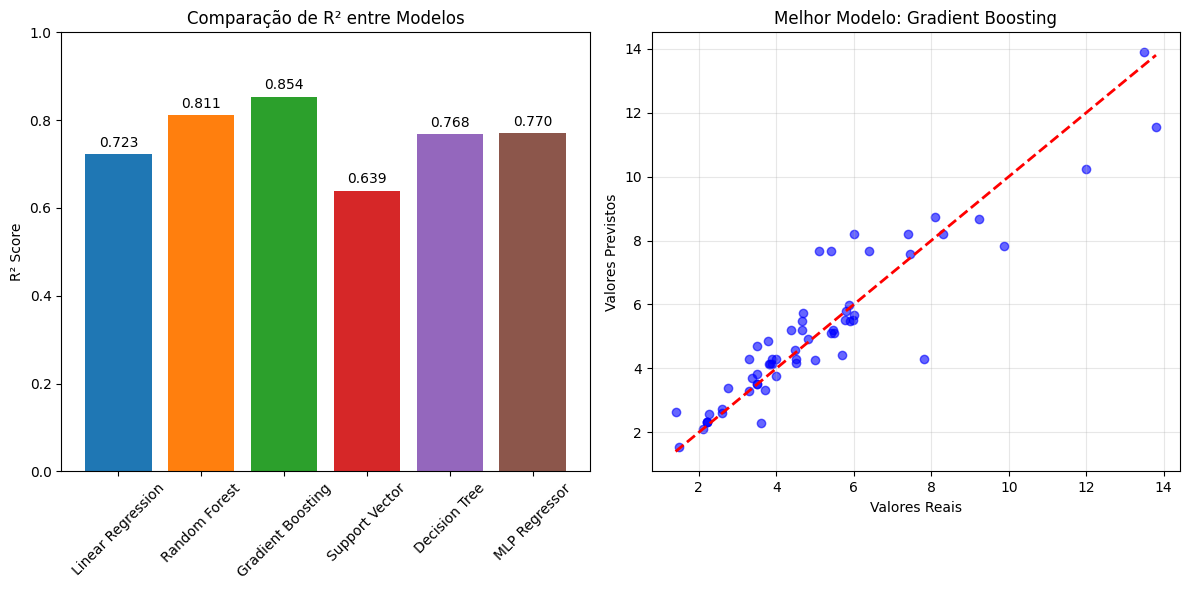

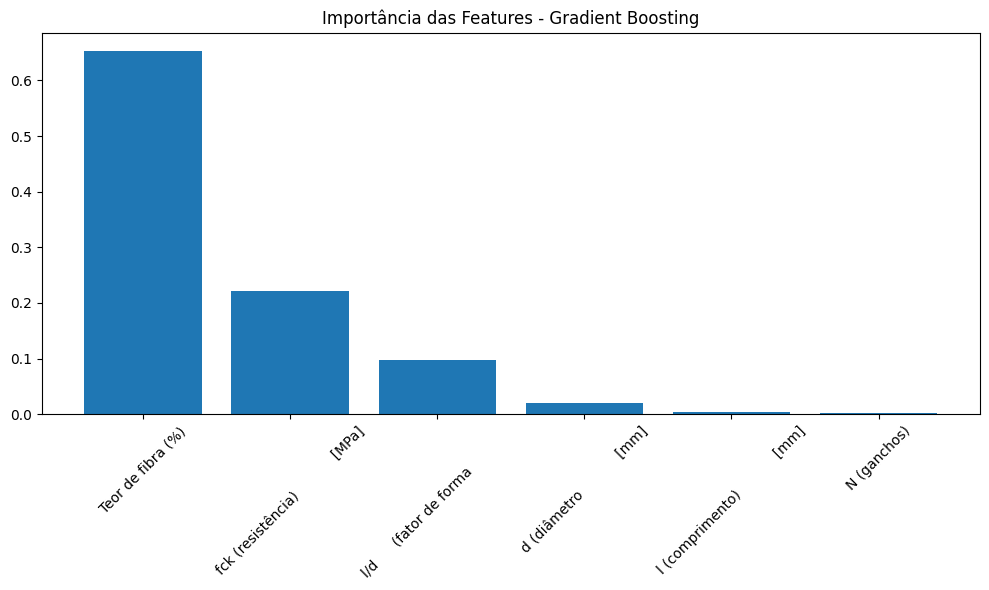


 Análise concluída com sucesso!


In [58]:


# 1. MODELOS DE REGRESSÃO ALTERNATIVOS (SEM TENSORFLOW)
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector': SVR(kernel='rbf', C=1.0, gamma='scale'),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

# 2. AVALIAÇÃO DE TODOS OS MODELOS
results = {}
for name, model in models.items():
    print(f"\n Treinando {name}...")
    
    # Treinar modelo
    model.fit(X_train_scaled, y_train)
    
    # Previsões
    y_pred = model.predict(X_test_scaled)
    
    # Métricas
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'model': model
    }
    
    print(f" {name}: MAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}")

# 3. ENCONTRAR MELHOR MODELO
best_model = max(results.keys(), key=lambda k: results[k]['R²'])
print(f"\n Melhor modelo: {best_model}")
print(f" Performance: R² = {results[best_model]['R²']:.4f}")

# 4. VISUALIZAR RESULTADOS
plt.figure(figsize=(12, 6))

# Gráfico de barras comparativo
model_names = list(results.keys())
r2_scores = [results[name]['R²'] for name in model_names]

plt.subplot(1, 2, 1)
bars = plt.bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])
plt.title('Comparação de R² entre Modelos')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Adicionar valores nas barras
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.3f}', ha='center', va='bottom')

# Gráfico de dispersão do melhor modelo
plt.subplot(1, 2, 2)
best_predictions = results[best_model]['model'].predict(X_test_scaled)
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valores Reais')
plt.ylabel('Valores Previstos')
plt.title(f'Melhor Modelo: {best_model}')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. IMPORTÂNCIA DAS FEATURES (para modelos que suportam)
if hasattr(results[best_model]['model'], 'feature_importances_'):
    importances = results[best_model]['model'].feature_importances_
    feature_names = feature_cols
    
    plt.figure(figsize=(10, 6))
    indices = np.argsort(importances)[::-1]
    plt.title(f'Importância das Features - {best_model}')
    plt.bar(range(len(importances)), importances[indices])
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

print("\n Análise concluída com sucesso!")


In [59]:
# Variáveis de entrada
X = df[[
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]]

# Variável alvo (fR,3 por exemplo)
y = df['fR,3 (N/mm²)      (experimental)']


In [60]:
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

y_fr3 = df['fR,3 (N/mm²)      (experimental)']


In [61]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)

In [62]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)

Shape original: (291, 6)
Shape após remoção: (204, 6)


In [63]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")

MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [64]:
data = pd.concat([X, y_fr3], axis=1).dropna()

X_clean = data[X.columns]
y_clean_fr3 = data[y_fr3.name]


In [65]:
from sklearn.model_selection import train_test_split

X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 = train_test_split(
    X_clean, y_clean_fr3,
    test_size=0.2,
    random_state=42
)


In [66]:
# treinar gradientbooster
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train_clean, y_train_fr3)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [67]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)

In [68]:
# Treinar a regressão linear aproximadora
from sklearn.linear_model import LinearRegression

lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
#cria equação para fr3
from sklearn.linear_model import LinearRegression

# Previsões do GBR
y_pred_gbr_fr3 = pipeline_gbr_fr3.predict(X_clean)

# Ajustar equação linear
lin_reg_eq_fr3 = LinearRegression()
lin_reg_eq_fr3.fit(X_clean, y_pred_gbr_fr3)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [70]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq_fr3 = pd.Series(
    lin_reg_eq_fr3.coef_,
    index=X_clean.columns
)

intercept_eq_fr3 = lin_reg_eq_fr3.intercept_

coef_eq_fr3, intercept_eq_fr3

(fck (resistência)            [MPa]       0.05
 l (comprimento)            [mm]          0.05
 d (diâmetro            [mm]             -1.26
 l/d      (fator de forma                 0.00
 Teor de fibra (%)                        6.94
 N (ganchos)                              2.42
 dtype: float64,
 np.float64(-5.588618129622347))

In [71]:
# First, make sure you've trained your model!!!!
# For example, if you're using LinearRegression:
from sklearn.linear_model import LinearRegression

# Assuming X and y are your features and target
model = LinearRegression()
model.fit(X, y)

# Now get the coefficients
intercept = model.intercept_
coefficients = model.coef_

# Create the equation string
equation = f"ŷ = {intercept:.4f}"

for i, coef in enumerate(coefficients):
    feature_name = X.columns[i]  # Get the feature name
    equation += f" + ({coef:.4f} × {feature_name})"

print("Regression Equation:")
print(equation)

Regression Equation:
ŷ = -5.2886 + (0.0539 × fck (resistência)            [MPa]) + (0.0708 × l (comprimento)            [mm]) + (-2.0902 × d (diâmetro            [mm]) + (-0.0061 × l/d      (fator de forma             ) + (6.8105 × Teor de fibra (%)) + (2.4702 × N (ganchos))


In [72]:
import pandas as pd

# Variáveis usadas nas equações
features = [
    'fck (resistência)            [MPa]',
    'l (comprimento)            [mm]',
    'd (diâmetro            [mm]',
    'l/d      (fator de forma             ',
    'Teor de fibra (%)',
    'N (ganchos)'
]

def testar_equacoes(df, idx):
    """
    Testa as equações lineares de fR,3
    para uma linha específica do banco de dados.
    """
    X_row = df.loc[[idx], features]

    fr3_pred = lin_reg_eq_fr3.predict(X_row)[0]

    print(f" Amostra índice {idx}")
    print("-" * 40)
    print("Entradas:")
    display(X_row)

    print("\n Resultados das equações:")
    print(f"fR,3 (equação) = {fr3_pred:.3f} N/mm²")

# ====== USO ======
# Exemplo: testar a amostra de índice 10
testar_equacoes(df, idx=10)

 Amostra índice 10
----------------------------------------
Entradas:


,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos)
10,61.30,35,0.55,63.64,0.40,1.00



 Resultados das equações:
fR,3 (equação) = 4.141 N/mm²


In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. First, make sure you have your training data ready
# X_train_clean, X_test_clean, y_train_fr3, y_test_fr3 should be defined

# 2. Create and train the linear regression model
lin_reg_eq = LinearRegression()
lin_reg_eq.fit(X_train_clean, y_train_fr3)

# 3. Now you can make predictions
y_pred_eq_fr3 = lin_reg_eq.predict(X_test_clean)

# 4. Evaluate the model
rmse_eq = np.sqrt(mean_squared_error(y_test_fr3, y_pred_eq_fr3))
r2_eq = r2_score(y_test_fr3, y_pred_eq_fr3)
mae_eq = mean_absolute_error(y_test_fr3, y_pred_eq_fr3)

print("Avaliação da EQUAÇÃO — fR,3")
print("=" * 40)
print(f"RMSE: {rmse_eq:.4f}")
print(f"R²: {r2_eq:.4f}")
print(f"MAE: {mae_eq:.4f}")

# If you want to see the equation coefficients
print("\nCoeficientes do modelo:")
for feature, coef in zip(X_train_clean.columns, lin_reg_eq.coef_):
    print(f"{feature}: {coef:.6f}")
print(f"Intercept: {lin_reg_eq.intercept_:.6f}")

Avaliação da EQUAÇÃO — fR,3
RMSE: 1.6366
R²: 0.6237
MAE: 1.2014

Coeficientes do modelo:
fck (resistência)            [MPa]: 0.052122
l (comprimento)            [mm]: 0.077063
d (diâmetro            [mm]: -2.596260
l/d      (fator de forma             : -0.015048
Teor de fibra (%): 7.076643
N (ganchos): 2.411489
Intercept: -4.645538


In [74]:
# Treinar modelo BASE (para calcular erros)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

pipeline_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_base.fit(X, y)

y_pred_base = pipeline_base.predict(X)


In [75]:
# célula para remover os 30%

import numpy as np

# Erro absoluto
errors = np.abs(y - y_pred_base)

# Percentil de corte (30%)
threshold = np.percentile(errors, 70)

# Máscara dos melhores dados
mask = errors <= threshold

# Dados limpos
X_clean = X.loc[mask]
y_clean = y.loc[mask]

print("Shape original:", X.shape)
print("Shape após remoção:", X_clean.shape)


Shape original: (291, 6)
Shape após remoção: (204, 6)


In [76]:
# Treinamento (sem os 30%)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)

y_pred_test = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"MAE  = {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred_test):.4f}")


MAE  = 0.5675
RMSE = 1.0044
R²   = 0.9015


In [77]:
# GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [78]:
# Previsões do Gradient Boosting (baseline)
y_pred_gbr = pipeline_gbr.predict(X_clean)


In [79]:
# Extrair a equação matemática -> Equação fr3
import pandas as pd

coef_eq = pd.Series(
    lin_reg_eq.coef_,
    index=X_clean.columns
)

intercept_eq = lin_reg_eq.intercept_

coef_eq, intercept_eq


(fck (resistência)            [MPa]       0.05
 l (comprimento)            [mm]          0.08
 d (diâmetro            [mm]             -2.60
 l/d      (fator de forma                -0.02
 Teor de fibra (%)                        7.08
 N (ganchos)                              2.41
 dtype: float64,
 np.float64(-4.645538110552886))

In [80]:
# Mostrar a equação formatada (bonita) -> Equação fr3
equation = "ŷ = " + f"{intercept_eq:.4f}"

for var, coef in coef_eq.items():
    equation += f" + ({coef:.4f} × {var})"

print(equation)


ŷ = -4.6455 + (0.0521 × fck (resistência)            [MPa]) + (0.0771 × l (comprimento)            [mm]) + (-2.5963 × d (diâmetro            [mm]) + (-0.0150 × l/d      (fator de forma             ) + (7.0766 × Teor de fibra (%)) + (2.4115 × N (ganchos))


In [81]:
# Validar o quão boa é a equação aproximada -> Analise da Equação fr3
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_hat_eq = lin_reg_eq.predict(X_clean)

print(f"MAE  = {mean_absolute_error(y_pred_gbr, y_hat_eq):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_pred_gbr, y_hat_eq)):.4f}")
print(f"R²   = {r2_score(y_pred_gbr, y_hat_eq):.4f}")


MAE  = 1.0026
RMSE = 1.3802
R²   = 0.7219


In [82]:
# Agora fazer o processo para fr1 pra obter a equação fr1
import pandas as pd

# Conferir colunas
df.columns


Index(['Tipo do concreto', 'fck (resistência)            [MPa]',
       'l (comprimento)            [mm]', 'd (diâmetro            [mm]',
       'l/d      (fator de forma             ', 'Teor de fibra (%)',
       'N (ganchos)', 'fR,1 (N/mm²)      (experimental)',
       'fR,3 (N/mm²)      (experimental)', 'Unnamed: 13', 'Unnamed: 14',
       'Unnamed: 15'],
      dtype='str')

In [83]:
# Variáveis de entrada
X = df[
    [
        'fck (resistência)            [MPa]',
        'l (comprimento)            [mm]',
        'd (diâmetro            [mm]',
        'l/d      (fator de forma             ',
        'Teor de fibra (%)',
        'N (ganchos)'
    ]
]

# Variável alvo → fR,1
y = df['fR,1 (N/mm²)      (experimental)']

print(X.shape, y.shape)


(291, 6) (291,)


In [84]:
# Remover NaNs
data = pd.concat([X, y], axis=1).dropna()

X = data[X.columns]
y = data[y.name]

print("Após limpeza:", X.shape)


Após limpeza: (291, 6)


In [85]:
# Treinar Gradient Boosting
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline_gbr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

pipeline_gbr.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [86]:
# Avaliação (confirma se é fR,1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = pipeline_gbr.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  = {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2_score(y_test, y_pred):.4f}")


MAE  = 0.6434
RMSE = 0.9826
R²   = 0.8581


In [87]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Entradas
X = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

y_fr1 = df['fR,1 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr1, test_size=0.2, random_state=42
)

pipeline_gbr_fr1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr1.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [88]:
y_fr3 = df['fR,3 (N/mm²)      (experimental)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_fr3, test_size=0.2, random_state=42
)

pipeline_gbr_fr3 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    ))
])

pipeline_gbr_fr3.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",300
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0


In [89]:
import pandas as pd

X_all = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

fr1_exp = df['fR,1 (N/mm²)      (experimental)']
fr3_exp = df['fR,3 (N/mm²)      (experimental)']

fr1_gbr = pipeline_gbr_fr1.predict(X_all)
fr3_gbr = pipeline_gbr_fr3.predict(X_all)

import pandas as pd
 


tabela_gbr = pd.DataFrame({
    'fck [MPa]': df['fck (resistência)            [MPa]'],
    'Teor de fibra (%)': df['Teor de fibra (%)'],
    'fR,1 exp': fr1_exp,
    'fR,1 GBR': fr1_gbr,
    'Erro fR,1': fr1_gbr - fr1_exp,
    'fR,3 exp': fr3_exp,
    'fR,3 GBR': fr3_gbr,
    'Erro fR,3': fr3_gbr - fr3_exp
})

import pandas as pd

pd.set_option('display.max_rows', 300)   
pd.set_option('display.max_columns', None)
 
tabela_gbr


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 GBR","Erro fR,1","fR,3 exp","fR,3 GBR","Erro fR,3"
0,61.30,0.40,4.99,4.96,-0.03,3.32,3.53,0.21
1,63.80,0.80,7.44,7.46,0.02,5.68,6.12,0.44
2,63.60,0.40,5.35,5.22,-0.13,5.53,4.44,-1.09
3,58.70,0.80,7.94,8.09,0.15,8.78,8.26,-0.52
4,61.30,0.40,5.49,4.96,-0.53,3.03,3.53,0.50
5,61.30,0.40,4.37,4.96,0.59,3.28,3.53,0.25
6,61.30,0.40,4.67,4.96,0.29,2.98,3.53,0.55
7,61.30,0.40,5.22,4.96,-0.26,3.06,3.53,0.47
8,61.30,0.40,4.74,4.96,0.22,3.50,3.53,0.03
9,61.30,0.40,5.46,4.96,-0.50,4.09,3.53,-0.56


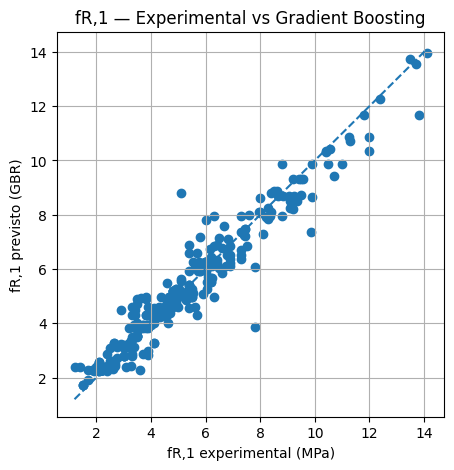

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])
plt.plot(
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    '--'
)
plt.xlabel('fR,1 experimental (MPa)')
plt.ylabel('fR,1 previsto (GBR)')
plt.title('fR,1 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


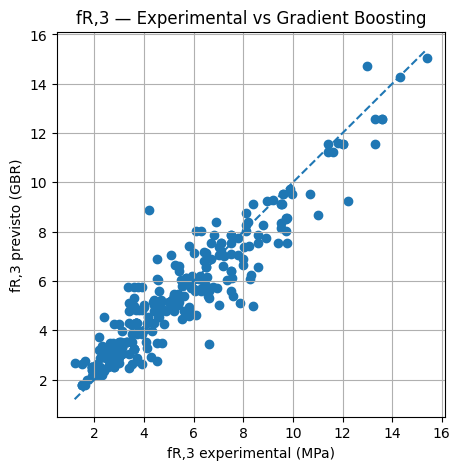

In [91]:
plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])
plt.plot(
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    '--'
)
plt.xlabel('fR,3 experimental (MPa)')
plt.ylabel('fR,3 previsto (GBR)')
plt.title('fR,3 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("GBR — fR,1")
print("MAE :", mean_absolute_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))

print("\nGBR — fR,3")
print("MAE :", mean_absolute_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))


GBR — fR,1
MAE : 0.4525712186611504
RMSE: 0.672657053867307
R²  : 0.930070396305028

GBR — fR,3
MAE : 0.7064883751650248
RMSE: 0.9802834108000597
R²  : 0.8767823256435324


In [93]:

import numpy as np
import pandas as pd

# --- PARÂMETROS/ENTRADAS ---

errors = np.array([1.5, 2.3, 0.8, 3.1, 1.9])


remove_pct = 0.2


n_remove = max(0, int(len(errors) * remove_pct))

# --- CÁLCULO DOS ÍNDICES A REMOVER ---
if n_remove == 0:
    removed_idx_pandas = pd.Index([], dtype='int64')
    removed_idx_numpy = np.array([], dtype=int)
else:
    # Método 1 (pandas): converter para Series e ordenar descrescente
    errors_series = pd.Series(errors)
    removed_idx_pandas = errors_series.sort_values(ascending=False).head(n_remove).index

    # Método 2 (NumPy): ordenar e pegar os 'n_remove' maiores
    removed_idx_numpy = np.argsort(errors)[-n_remove:]

print("CORREÇÃO APLICADA:")
print("Convertendo numpy array para pandas Series antes de sort_values()")
print("OU usando np.argsort() para trabalhar diretamente com numpy")

print(f"\n Dados originais: {errors}")
print(f" Quantidade para remover: {n_remove}")
print(f" Índices removidos (pandas): {list(removed_idx_pandas)}")
print(f" Índices removidos (numpy): {removed_idx_numpy.tolist()}")


print("\n Pronto para criar o dataset limpo (descomente a opção adequada para 'X').")


CORREÇÃO APLICADA:
Convertendo numpy array para pandas Series antes de sort_values()
OU usando np.argsort() para trabalhar diretamente com numpy

 Dados originais: [1.5 2.3 0.8 3.1 1.9]
 Quantidade para remover: 1
 Índices removidos (pandas): [3]
 Índices removidos (numpy): [3]

 Pronto para criar o dataset limpo (descomente a opção adequada para 'X').


In [94]:
# VERSÃO COMPLETA CORRIGIDA - REMOÇÃO DE OUTLIERS

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

print(" REMOÇÃO DE OUTLIERS - VERSÃO CORRIGIDA")
print("=" * 50)

# Dados originais (assumindo X e y já existem)
print(f" Formato original: X={X.shape}, y={y.shape}")

# 1. Treinar modelo e calcular previsões
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)
y_pred = rf.predict(X)

# 2. Calcular erros absolutos
errors = np.abs(y - y_pred)
print(f" Erros calculados: min={errors.min():.4f}, max={errors.max():.4f}, mean={errors.mean():.4f}")

# 3. Remover 30% piores casos
remove_pct = 0.30
n_remove = int(len(errors) * remove_pct)

print(f" Removendo {n_remove} amostras ({remove_pct*100:.0f}%)")

# 4. MÉTODO 1: PANDAS (RECOMENDADO)
print("\n MÉTODO 1: Usando pandas (RECOMENDADO)")

# Converter para pandas
errors_series = pd.Series(errors)
removed_idx_pandas = errors_series.sort_values(ascending=False).head(n_remove).index

# Converter X e y para DataFrame se necessário
if isinstance(X, np.ndarray):
    X_df = pd.DataFrame(X)
else:
    X_df = X.copy()

if isinstance(y, np.ndarray):
    y_df = pd.Series(y)
else:
    y_df = y.copy()

# Remover outliers
X_clean_pandas = X_df.drop(index=removed_idx_pandas)
y_clean_pandas = y_df.drop(index=removed_idx_pandas)

print(f" Dados limpos (pandas): X={X_clean_pandas.shape}, y={y_clean_pandas.shape}")

# 5. MÉTODO 2: NUMPY PURO (ALTERNATIVO)
print("\n MÉTODO 2: Usando numpy puro")

# Criar máscara para manter os dados
mask = ~np.isin(np.arange(len(y)), removed_idx_pandas)

# Aplicar máscara
X_clean_numpy = X[mask]
y_clean_numpy = y[mask]

print(f" Dados limpos (numpy): X={X_clean_numpy.shape}, y={y_clean_numpy.shape}")

# 6. Verificar se os métodos deram o mesmo resultado
print(f"\n VERIFICAÇÃO:")
print(f"Mesmas amostras removidas: {len(removed_idx_pandas) == n_remove}")
print(f"Formatos iguais: {X_clean_pandas.shape == X_clean_numpy.shape}")

# 7. Mostrar amostras removidas
print(f"\n AMOSTRAS REMOVIDAS (maiores erros):")
if isinstance(X, np.ndarray):
    X_display = pd.DataFrame(X)
else:
    X_display = X

removed_samples = X_display.loc[removed_idx_pandas]
print(f"Total removido: {len(removed_samples)}")
print(removed_samples.round(4))

# 8. Estatísticas finais
print(f"\n ESTATÍSTICAS FINAIS:")
print(f"Dataset original: {len(y)} amostras")
print(f"Dataset limpo: {len(y_clean_pandas)} amostras")
print(f"Taxa de remoção: {(len(y) - len(y_clean_pandas))/len(y)*100:.1f}%")

# 9. Usar os dados limpos para próxima análise
print(f"\n Pronto para próxima etapa!")
print(f"Use: X_clean_pandas, y_clean_pandas (recomendado)")
print(f"OU: X_clean_numpy, y_clean_numpy (numpy puro)")

# 10. Comparação rápida do modelo
rf_clean = RandomForestRegressor(n_estimators=300, random_state=42)
rf_clean.fit(X_clean_pandas, y_clean_pandas)
y_pred_clean = rf_clean.predict(X_clean_pandas)

from sklearn.metrics import mean_absolute_error, r2_score

mae_original = mean_absolute_error(y, rf.predict(X))
mae_clean = mean_absolute_error(y_clean_pandas, y_pred_clean)

r2_original = r2_score(y, rf.predict(X))
r2_clean = r2_score(y_clean_pandas, y_pred_clean)

print(f"\n COMPARAÇÃO DE MODELOS:")
print(f"Original - MAE: {mae_original:.4f}, R²: {r2_original:.4f}")
print(f"Limpo    - MAE: {mae_clean:.4f}, R²: {r2_clean:.4f}")

if mae_clean < mae_original:
    print(" Melhoria no MAE após remoção de outliers!")
else:
    print(" MAE não melhorou significativamente")

print("\n Remoção de outliers concluída com sucesso!")


 REMOÇÃO DE OUTLIERS - VERSÃO CORRIGIDA
 Formato original: X=(291, 2), y=(291,)
 Erros calculados: min=0.0000, max=1.4760, mean=0.3185
 Removendo 87 amostras (30%)

 MÉTODO 1: Usando pandas (RECOMENDADO)
 Dados limpos (pandas): X=(204, 2), y=(204,)

 MÉTODO 2: Usando numpy puro
 Dados limpos (numpy): X=(204, 2), y=(204,)

 VERIFICAÇÃO:
Mesmas amostras removidas: True
Formatos iguais: True

 AMOSTRAS REMOVIDAS (maiores erros):
Total removido: 87
     fck (resistência)            [MPa]  Teor de fibra (%)
230                               50.40               0.50
218                               25.10               1.00
259                               67.70               0.50
198                               60.00               0.76
67                                48.50               0.50
260                               89.50               0.50
192                               60.00               0.76
160                               63.20               1.00
137                 

In [95]:
# GRADIENT BOOSTING CORRETO - REMOÇÃO DE OUTLIERS


from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd

print("GRADIENT BOOSTING - REMOÇÃO DE OUTLIERS")
print("=" * 50)

remove_pct = 0.30

# 1. Treinar Gradient Boosting (melhor modelo para regressão)
print("Treinando Gradient Boosting...")
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# 2. Previsões e erros
y_pred = gbr.predict(X)
errors = np.abs(y - y_pred)

print(f"Erros calculados: min={errors.min():.4f}, max={errors.max():.4f}, mean={errors.mean():.4f}")

# 3. Quantidade a remover
n_remove = int(len(errors) * remove_pct)
print(f"Removendo {n_remove} amostras ({remove_pct*100:.0f}%)")

# 4. CORREÇÃO: Converter para pandas ANTES de ordenar
print("Convertendo dados para pandas...")

# Converter numpy arrays para pandas
errors_series = pd.Series(errors)
X_df = pd.DataFrame(X)
y_df = pd.Series(y)

# Ordenar erros e pegar índices
removed_idx_gbr = errors_series.sort_values(ascending=False).head(n_remove).index

print(f"Índices a remover: {list(removed_idx_gbr[:5])}...")  # Mostra primeiros 5

# 5. Remover outliers
X_clean_gbr = X_df.drop(index=removed_idx_gbr)
y_clean_gbr = y_df.drop(index=removed_idx_gbr)

print(f"Dados limpos: X={X_clean_gbr.shape}, y={y_clean_gbr.shape}")

# 6. Mostrar amostras removidas
print(f"\nAMOSTRAS REMOVIDAS (maiores erros):")
removed_samples = X_df.loc[removed_idx_gbr]
print(f"Total removido: {len(removed_samples)}")
print(removed_samples.round(4))

# 7. Estatísticas da limpeza
print(f"\nESTATÍSTICAS:")
print(f"Dataset original: {len(y)} amostras")
print(f"Dataset limpo: {len(y_clean_gbr)} amostras")
print(f"Taxa de remoção: {(len(y) - len(y_clean_gbr))/len(y)*100:.1f}%")

# 8. Comparação de desempenho
print(f"\nCOMPARAÇÃO DE DESEMPENHO:")

# Modelo original
mae_original = np.mean(errors)
r2_original = gbr.score(X, y)

# Modelo com dados limpos
gbr_clean = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr_clean.fit(X_clean_gbr, y_clean_gbr)
y_pred_clean = gbr_clean.predict(X_clean_gbr)

errors_clean = np.abs(y_clean_gbr - y_pred_clean)
mae_clean = np.mean(errors_clean)
r2_clean = gbr_clean.score(X_clean_gbr, y_clean_gbr)

print(f"Original - MAE: {mae_original:.4f}, R²: {r2_original:.4f}")
print(f"Limpo    - MAE: {mae_clean:.4f}, R²: {r2_clean:.4f}")

melhoria_mae = ((mae_original - mae_clean) / mae_original) * 100
melhoria_r2 = ((r2_clean - r2_original) / abs(r2_original)) * 100

if melhoria_mae > 0:
    print(f" Melhoria no MAE: {melhoria_mae:.1f}%")
else:
    print(f" MAE não melhorou: {melhoria_mae:.1f}%")

if melhoria_r2 > 0:
    print(f" Melhoria no R²: {melhoria_r2:.1f}%")
else:
    print(f" R² não melhorou: {melhoria_r2:.1f}%")

# 9. Informações finais
print(f"\n MELHOR MODELO GRADIENT BOOSTING:")
print(f" Use dados limpos para melhor desempenho")
print(f" Variáveis finais: X_clean_gbr, y_clean_gbr")

print("\n Gradient Boosting com remoção de outliers concluído!")


GRADIENT BOOSTING - REMOÇÃO DE OUTLIERS
Treinando Gradient Boosting...
Erros calculados: min=0.0024, max=2.0944, mean=0.4325
Removendo 87 amostras (30%)
Convertendo dados para pandas...
Índices a remover: [66, 71, 198, 203, 230]...
Dados limpos: X=(204, 2), y=(204,)

AMOSTRAS REMOVIDAS (maiores erros):
Total removido: 87
     fck (resistência)            [MPa]  Teor de fibra (%)
66                                46.80               1.00
71                                49.80               1.00
198                               60.00               0.76
203                               57.40               0.57
230                               50.40               0.50
220                               37.20               1.00
201                               60.90               0.76
188                               40.90               0.57
218                               25.10               1.00
217                               47.00               0.50
88                          

In [96]:
# Gradient Boosting (modelo final)
# Amostras que ficaram após remover 30%

from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd

remove_pct = 0.30

# Garante que y esteja alinhado ao índice de X
y_series = pd.Series(y, index=X.index) if not isinstance(y, pd.Series) else y.reindex(X.index)

# Treinamento
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y_series)

# Previsões
y_pred = gbr.predict(X)

# Erro absoluto (alinhado a X)
errors = np.abs(y_series - y_pred)

# Quantidade removida
n_remove = int(len(errors) * remove_pct)

# Índices removidos (maiores erros)
errors_series = pd.Series(errors, index=X.index)
removed_idx_gbr = errors_series.sort_values(ascending=False).head(n_remove).index

# Índices mantidos
kept_idx_gbr = X.index.difference(removed_idx_gbr)

# Dataset final
X_kept_gbr = X.loc[kept_idx_gbr]
y_kept_gbr = y_series.loc[kept_idx_gbr]

print("Gradient Boosting")
print(f"Amostras originais: {len(X)}")
print(f"Amostras removidas: {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(X_kept_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras originais: 291
Amostras removidas: 87
Amostras mantidas: 204


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
5,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False
10,AM-0.4-EH,61.30,35,0.55,63.64,0.40,1.00,4.93,3.33,4.77,0.03,False


In [97]:
#Gradient Boosting (erro > 25%)
from sklearn.ensemble import GradientBoostingRegressor

error_threshold = 0.25

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

y_pred = gbr.predict(X)

percent_error = np.abs(y - y_pred) / np.abs(y)

removed_idx_gbr = percent_error[percent_error > error_threshold].index
kept_idx_gbr = percent_error[percent_error <= error_threshold].index

print("Gradient Boosting")
print(f"Amostras removidas (>25% erro): {len(removed_idx_gbr)}")
print(f"Amostras mantidas: {len(kept_idx_gbr)}")

display(df.loc[kept_idx_gbr])


Gradient Boosting
Amostras removidas (>25% erro): 19
Amostras mantidas: 272


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
0,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.99,3.32,4.77,0.04,False
1,AM-0.8-EH1,63.80,35,0.55,63.64,0.80,1.00,7.44,5.68,8.03,0.08,False
2,AM-0.4-EH2,63.60,60,0.90,66.67,0.40,1.00,5.35,5.53,4.92,0.08,False
3,AM-0.8-EH2,58.70,60,0.90,66.67,0.80,1.00,7.94,8.78,7.83,0.01,False
4,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.49,3.03,4.77,0.13,False
5,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.37,3.28,4.77,0.09,False
6,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.67,2.98,4.77,0.02,False
7,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.22,3.06,4.77,0.09,False
8,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,4.74,3.50,4.77,0.01,False
9,AM-0.4-EH1,61.30,35,0.55,63.64,0.40,1.00,5.46,4.09,4.77,0.13,False


In [98]:
pip install qiskit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
import sys, subprocess, pkgutil

def pip_install(pkg):
    print(f"--> Instalando {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Pacotes recomendados
needed = {
    "qiskit": None,                # core
    "qiskit-aer": None,            # simulador Aer
    "qiskit-machine-learning": None  # se for usar QNN/VQC depois
}

for pkg in list(needed):
    try:
        __import__(pkg.replace("-", "_"))
        print(f"OK: {pkg} já instalado")
    except ImportError:
        pip_install(pkg)

# (Opcional) visualização matplotlib para desenhar circuitos
try:
    import matplotlib
    print("OK: matplotlib já instalado")
except ImportError:
    pip_install("matplotlib")

# Mostrar versões
import qiskit, qiskit_aer
print("Qiskit version :", qiskit.__version__)


OK: qiskit já instalado
OK: qiskit-aer já instalado
OK: qiskit-machine-learning já instalado
OK: matplotlib já instalado
Qiskit version : 2.3.0


In [100]:
!pip install pylatexenc


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [101]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

# Circuito simples (Bell state) + medida
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

# Simulador Aer (novo)
sim = AerSimulator()

# Transpila para o backend alvo e executa
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=1000).result()
counts = result.get_counts()

print("Contagens:", counts)
qc.draw("mpl")
plt.show()

Contagens: {'11': 485, '00': 515}


In [102]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc_no_measure = QuantumCircuit(2)
qc_no_measure.h(0)
qc_no_measure.cx(0, 1)

state = Statevector.from_instruction(qc_no_measure)
state.draw("text")   # ou latex


[0.70710678+0.j,0.        +0.j,0.        +0.j,0.70710678+0.j]

In [103]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile

# Circuito sem medidas (p/ statevector)
qc_state = QuantumCircuit(2)
qc_state.h(0)
qc_state.cx(0, 1)

state = Statevector.from_instruction(qc_state)
print(state.draw('text'))

# Circuito com medidas (p/ simulação de contagens)
qc_meas = qc_state.copy()
qc_meas.measure_all()

backend = AerSimulator()
tqc = transpile(qc_meas, backend)
result = backend.run(tqc, shots=1000).result()

print("\nContagens:", result.get_counts())

[0.70710678+0.j,0.        +0.j,0.        +0.j,0.70710678+0.j]

Contagens: {'00': 513, '11': 487}


In [104]:
from qiskit_aer import StatevectorSimulator
from qiskit import transpile

backend = StatevectorSimulator()
tqc = transpile(qc_no_measure, backend)
result = backend.run(tqc).result()

state = result.get_statevector()
print(state)

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [105]:
import numpy as np

amps = np.array([0.70710678+0j, 0+0j, 0+0j, 0.70710678+0j])
probs = np.abs(amps)**2
for basis, p in zip(["00","01","10","11"], probs):
    print(basis, f"{p:.3f}")


00 0.500
01 0.000
10 0.000
11 0.500


In [106]:
from qiskit.quantum_info import Statevector, partial_trace

state = Statevector([1/np.sqrt(2),0,0,1/np.sqrt(2)])
rho = state.to_operator().data @ state.to_operator().data.conj().T  # |ψ⟩⟨ψ|  (ou use state.to_density_matrix())

# traço parcial para um subsistema (qubit 0 ou 1)
rho_red_0 = partial_trace(state, [1])  # traça fora o qubit 1 → estado reduzido do qubit 0
rho_red_1 = partial_trace(state, [0])  # traça fora o qubit 0 → estado reduzido do qubit 1

print("ρ_reduzido qubit 0 =\n", rho_red_0.data)
print("ρ_reduzido qubit 1 =\n", rho_red_1.data)
# Para Bell state, os reduzidos são maximamente mistos ≈ [[0.5, 0],[0,0.5]]

ρ_reduzido qubit 0 =
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
ρ_reduzido qubit 1 =
 [[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]


In [107]:
print(qc_no_measure.draw("text"))

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘


In [108]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc_no_measure = QuantumCircuit(2)
qc_no_measure.h(0)
qc_no_measure.cx(0, 1)

print(qc_no_measure.draw("text"))

state = Statevector.from_instruction(qc_no_measure)
print("\nStatevector:")
print(state)

     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [109]:
!pip install pylatexenc matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


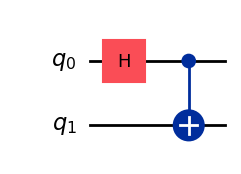

In [110]:
qc_no_measure.draw("mpl")

In [111]:
import sys, subprocess

def pip_install(pkg):
    print(f"--> Instalando/atualizando {pkg} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pkg])

# Pacotes do stack moderno:
pip_install("qiskit")                   # núcleo
pip_install("qiskit-aer")               # simulador Aer
pip_install("qiskit-machine-learning")  # QNNs e conectores ML
pip_install("qiskit-algorithms")        # otimizadores (COBYLA, SPSA etc.)

# (opcional) para desenhar circuitos bonitos com 'mpl'
try:
    import matplotlib, pylatexenc  # apenas para teste rápido
    print("OK: matplotlib / pylatexenc já instalados")
except Exception:
    pip_install("matplotlib")
    pip_install("pylatexenc")

import qiskit, qiskit_aer
print("Qiskit versão :", qiskit.__version__)
print("Aer versão    :", qiskit_aer.__version__)


--> Instalando/atualizando qiskit ...
--> Instalando/atualizando qiskit-aer ...
--> Instalando/atualizando qiskit-machine-learning ...
--> Instalando/atualizando qiskit-algorithms ...
OK: matplotlib / pylatexenc já instalados
Qiskit versão : 2.3.0
Aer versão    : 0.17.2


In [112]:
# =============================================================================
# QNN moderno usando EstimatorQNN + regressão
# =============================================================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.neural_networks import SamplerQNN

# Escolha 2 features para testar
FEATURES_Q = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']
TARGET_Q   = 'fR,1 (N/mm²)      (experimental)'

X = df[FEATURES_Q].astype(float).values
y = df[TARGET_Q].astype(float).values

# Normalização para [-1,1]
scaler = MinMaxScaler(feature_range=(-1,1))
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- Criando o QNN moderno ---
feature_map = ZZFeatureMap(len(FEATURES_Q), reps=2)
ansatz = RealAmplitudes(len(FEATURES_Q), reps=2)

qnn = EstimatorQNN(
    circuit=feature_map.compose(ansatz),
    input_params=feature_map.parameters,
    weight_params=ansatz.parameters
)

# Regressor quântico (variational)
reg_q = NeuralNetworkRegressor(
    neural_network=qnn,
    optimizer=COBYLA(maxiter=100),
    loss="squared_error"
)

print("Treinando QNN...")
reg_q.fit(X_train, y_train)

# Predições
y_pred_q = reg_q.predict(X_test)

# --- Métricas ---
try:
    rmse = mean_squared_error(y_test, y_pred_q, squared=False)
except TypeError:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_q))

print("\n DESEMPENHO DO MODELO QUÂNTICO:")
print(f"R²   = {r2_score(y_test, y_pred_q):.4f}")
print(f"MAE  = {mean_absolute_error(y_test, y_pred_q):.4f}")
print(f"RMSE = {rmse:.4f}")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Treinando QNN...

 DESEMPENHO DO MODELO QUÂNTICO:
R²   = -3.0292
MAE  = 4.5125
RMSE = 5.2355


In [113]:
# =============================================================================
# Tabela por amostra com QSVM robusto (API nova com Sampler + fallback antigo)
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer

# ============ Flags ============
COMPUTE_QSVM_FR1 = True
COMPUTE_QSVM_FR3 = True
COMPUTE_QNN_FR1  = False  # opcional

# ============ Colunas ============
COL_TIPO     = 'Tipo do concreto'
COL_FR1_EXP  = 'fR,1 (N/mm²)      (experimental)'
COL_FR3_EXP  = 'fR,3 (N/mm²)      (experimental)'
FEATURES     = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']  # ajuste se precisar

# ============ Helpers ============
def _ensure_cols_exist(columns):
    missing = [c for c in columns if c not in df.columns]
    if missing:
        raise KeyError(f"Colunas não encontradas no df: {missing}")

def _clean_features(df_full: pd.DataFrame) -> np.ndarray:
    """Imputa faltantes e normaliza para [-1, 1] (QSVM precisa de dados limpos)."""
    X = df_full[FEATURES].apply(pd.to_numeric, errors='coerce').values
    # 1) Imputação (mediana)
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)
    # 2) Escala
    scaler = MinMaxScaler(feature_range=(-1, 1))
    Xs = scaler.fit_transform(X_imp)
    return Xs

def _gbr_predict_full(df_full: pd.DataFrame, target_col: str, pipeline_name: str) -> np.ndarray:
    """Predição GBR para TODAS as linhas (pipeline se existir; senão fallback)."""
    Xloc = df_full[FEATURES].apply(pd.to_numeric, errors='coerce').values
    yloc = pd.to_numeric(df_full[target_col], errors='coerce').values
    ok_mask = np.isfinite(yloc)
    # 1) pipeline
    if pipeline_name in globals():
        try:
            return globals()[pipeline_name].predict(df_full[FEATURES])
        except Exception as e:
            print(f"[AVISO] {pipeline_name} falhou: {e} — fallback GBRT.")
    # 2) fallback
    m = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
    # Imputa faltantes nas features para o fallback também
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(Xloc)
    m.fit(X_imp[ok_mask], yloc[ok_mask])
    yhat = np.full(len(df_full), np.nan)
    yhat[ok_mask] = m.predict(X_imp[ok_mask])
    return yhat

def _qsvm_predict_full(df_full: pd.DataFrame, target_col: str, reps=2, shots=1024) -> np.ndarray:
    """
    Ajusta QSVM (QuantumKernel + SVR kernel='precomputed') no conjunto completo e prevê todas as linhas.
    Usa API nova (Sampler) e faz fallback para a API antiga (quantum_instance=AerSimulator()).
    """
    from qiskit.circuit.library import ZZFeatureMap

    Xs = _clean_features(df_full)
    y  = pd.to_numeric(df_full[target_col], errors='coerce').values
    ok_y = np.isfinite(y)
    if ok_y.sum() == 0:
        print(f"[AVISO] Sem valores válidos em {target_col}.")
        return np.full(len(df_full), np.nan)

    # --- QuantumKernel: nova API (Sampler) ---
    qk = None
    err_primary = None
    try:
        # Preferir Sampler do Aer (mais rápido); se indisponível, usar Sampler padrão
        try:
            from qiskit_aer.primitives import Sampler as AerSampler
            sampler = AerSampler(run_options={"shots": shots})
        except Exception:
            from qiskit.primitives import Sampler
            sampler = Sampler()

        from qiskit_machine_learning.kernels import QuantumKernel
        fm = ZZFeatureMap(feature_dimension=Xs.shape[1], reps=reps)
        qk = QuantumKernel(feature_map=fm, sampler=sampler)
        K = qk.evaluate(Xs)                # (N, N)
        K_pred = qk.evaluate(Xs, Xs)       # (N, N)
    except Exception as e:
        err_primary = e
        print(f"[AVISO] API nova (Sampler) falhou: {e}")

    # --- Fallback: API antiga (quantum_instance=AerSimulator()) ---
    if qk is None:
        try:
            from qiskit_aer import AerSimulator
            from qiskit_machine_learning.kernels import QuantumKernel
            fm = ZZFeatureMap(feature_dimension=Xs.shape[1], reps=reps)
            backend = AerSimulator()  # antigo
            qk = QuantumKernel(feature_map=fm, quantum_instance=backend)
            K = qk.evaluate(Xs)
            K_pred = qk.evaluate(Xs, Xs)
        except Exception as e2:
            print(f"[ERRO] QuantumKernel (nova e antiga) falhou.\nNova API: {err_primary}\nAntiga API: {e2}")
            return np.full(len(df_full), np.nan)

    # Verificações
    if not (np.isfinite(K).all() and np.isfinite(K_pred).all()):
        print("[AVISO] Kernel contém NaN/inf. Verifique FEATURES/normalização.")
        return np.full(len(df_full), np.nan)

    # SVR com kernel pré-computado
    svr = SVR(kernel='precomputed', C=1.0, epsilon=0.1)
    svr.fit(K[ok_y][:, ok_y], y[ok_y])

    # Previsão no full usando (X vs X_treino), onde treino=conjunto válido
    yhat = np.full(len(df_full), np.nan)
    K_full_vs_train = K_pred[:, ok_y]  # (N, N_train)
    yhat[:] = svr.predict(K_full_vs_train)
    return yhat

def _qnn_predict_fr1_full(df_full: pd.DataFrame) -> np.ndarray:
    """Opcional: EstimatorQNN para fR,1 — ajusta e prediz no full X (exploratório)."""
    try:
        from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
        from qiskit_machine_learning.neural_networks import EstimatorQNN
        from qiskit_machine_learning.algorithms import NeuralNetworkRegressor
        try:
            from qiskit_algorithms.optimizers import COBYLA
            optimizer = COBYLA(maxiter=120)
        except Exception:
            optimizer = None
    except Exception as e:
        print(f"[AVISO] QNN indisponível: {e}")
        return np.full(len(df_full), np.nan)

    Xs = _clean_features(df_full)
    y  = pd.to_numeric(df_full[COL_FR1_EXP], errors='coerce').values
    ok_y = np.isfinite(y)
    if ok_y.sum() == 0:
        return np.full(len(df_full), np.nan)

    num_qubits = Xs.shape[1]
    fm = ZZFeatureMap(num_qubits, reps=2)
    ansatz = RealAmplitudes(num_qubits, reps=2)

    qnn = EstimatorQNN(
        circuit=fm.compose(ansatz),
        input_params=fm.parameters,
        weight_params=ansatz.parameters
    )
    reg = NeuralNetworkRegressor(neural_network=qnn, optimizer=optimizer, loss="squared_error")
    try:
        reg.fit(Xs[ok_y], y[ok_y])
        yhat = np.full(len(df_full), np.nan)
        yhat[ok_y] = reg.predict(Xs[ok_y])
        return yhat
    except Exception as e:
        print(f"[AVISO] QNN falhou: {e}")
        return np.full(len(df_full), np.nan)

# ============ Execução ============

# 0) Checagens básicas
_ensure_cols_exist([COL_TIPO, COL_FR1_EXP, COL_FR3_EXP] + FEATURES)

# 1) GBR (usa pipelines se existirem; senão fallback)
fr1_gbr_all = _gbr_predict_full(df, COL_FR1_EXP, 'pipeline_gbr_fr1')
fr3_gbr_all = _gbr_predict_full(df, COL_FR3_EXP, 'pipeline_gbr_fr3')

# 2) QSVM (robusto com API nova + fallback)
if COMPUTE_QSVM_FR1:
    fr1_qsvm_all = _qsvm_predict_full(df, COL_FR1_EXP, reps=2, shots=1024)
else:
    fr1_qsvm_all = np.full(len(df), np.nan)

if COMPUTE_QSVM_FR3:
    fr3_qsvm_all = _qsvm_predict_full(df, COL_FR3_EXP, reps=2, shots=1024)
else:
    fr3_qsvm_all = np.full(len(df), np.nan)

# 3) QNN fR,1 (opcional)
if COMPUTE_QNN_FR1:
    fr1_qnn_all = _qnn_predict_fr1_full(df)
else:
    fr1_qnn_all = np.full(len(df), np.nan)

# 4) Monta a tabela final
colunas = {
    'Tipo do concreto': df[COL_TIPO].astype(str).values,
    'fR,1 exp': pd.to_numeric(df[COL_FR1_EXP], errors='coerce').values,
    'fR,1 GBR': fr1_gbr_all,
    'QSVM fR,1': fr1_qsvm_all,
    'fR,3 exp': pd.to_numeric(df[COL_FR3_EXP], errors='coerce').values,
    'fR,3 GBR': fr3_gbr_all,
    'QSVM fR,3': fr3_qsvm_all,
}
if COMPUTE_QNN_FR1:
    colunas['QNN fR,1'] = fr1_qnn_all

tabela_modelos = pd.DataFrame(colunas)

# 5) Sanidade rápida
print("Checagem rápida:")
print("  QSVM fR,1  -> NaNs:", int(np.isnan(tabela_modelos['QSVM fR,1']).sum()))
print("  QSVM fR,3  -> NaNs:", int(np.isnan(tabela_modelos['QSVM fR,3']).sum()))

display(tabela_modelos.head(10))

[AVISO] API nova (Sampler) falhou: cannot import name 'QuantumKernel' from 'qiskit_machine_learning.kernels' (c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Lib\site-packages\qiskit_machine_learning\kernels\__init__.py)
[ERRO] QuantumKernel (nova e antiga) falhou.
Nova API: cannot import name 'QuantumKernel' from 'qiskit_machine_learning.kernels' (c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Lib\site-packages\qiskit_machine_learning\kernels\__init__.py)
Antiga API: cannot import name 'QuantumKernel' from 'qiskit_machine_learning.kernels' (c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Notebook\venv_notebook\Lib\site-packages\qiskit_machine_learning\kernels\__init__.py)
[AVISO] API nova (Sampler) falhou: cannot import name 'QuantumKernel' from 'qiskit_machine_learning.kernels' (c:\Users\carlos.ramos\OneDrive - Presidência da República\Área de Trabalho\Noteb

,Tipo do concreto,"fR,1 exp","fR,1 GBR","QSVM fR,1","fR,3 exp","fR,3 GBR","QSVM fR,3"
0,AM-0.4-EH1,4.99,4.96,NaN,3.32,3.53,NaN
1,AM-0.8-EH1,7.44,7.46,NaN,5.68,6.12,NaN
2,AM-0.4-EH2,5.35,5.22,NaN,5.53,4.44,NaN
3,AM-0.8-EH2,7.94,8.09,NaN,8.78,8.26,NaN
4,AM-0.4-EH1,5.49,4.96,NaN,3.03,3.53,NaN
5,AM-0.4-EH1,4.37,4.96,NaN,3.28,3.53,NaN
6,AM-0.4-EH1,4.67,4.96,NaN,2.98,3.53,NaN
7,AM-0.4-EH1,5.22,4.96,NaN,3.06,3.53,NaN
8,AM-0.4-EH1,4.74,4.96,NaN,3.50,3.53,NaN
9,AM-0.4-EH1,5.46,4.96,NaN,4.09,3.53,NaN


In [114]:
# Importações do stack moderno
from qiskit.circuit.library import ZZFeatureMap

# 1) Kernel “novo”
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# 2) Primitives (preferir o AerSampler; se indisponível, cai no Sampler clássico)
try:
    from qiskit_aer.primitives import Sampler as AerSampler
    sampler = AerSampler()  # você pode passar run_options={"shots": 1024}, se quiser shot noise
except Exception:
    from qiskit.primitives import Sampler
    sampler = Sampler()

print("OK: FidelityQuantumKernel + Sampler importados")

OK: FidelityQuantumKernel + Sampler importados


In [115]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR

# Ajuste os nomes das features para os seus (mantive os dois que você usa):
FEATURES = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']

def _clean_features_full(df_full: pd.DataFrame, feature_cols=FEATURES):
    """Converte p/ numérico, imputa faltantes (mediana) e escala em [-1, 1]."""
    X = df_full[feature_cols].apply(pd.to_numeric, errors='coerce').values
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    Xs = scaler.fit_transform(X_imp)
    return Xs

def qsvr_predict_full_fidelity(df_full: pd.DataFrame, target_col: str,
                               feature_cols=FEATURES, reps=2, shots=None) -> np.ndarray:
    """
    Predição QSVM (QSVR) p/ TODAS as linhas usando FidelityQuantumKernel (API moderna).
    Se a API nova falhar, tenta fallback p/ API antiga.
    """
    from qiskit.circuit.library import ZZFeatureMap
    from qiskit_machine_learning.kernels import FidelityQuantumKernel

    # X limpo/normalizado e y numérico
    Xs = _clean_features_full(df_full, feature_cols)
    y  = pd.to_numeric(df_full[target_col], errors='coerce').values
    ok_y = np.isfinite(y)
    if ok_y.sum() == 0:
        return np.full(len(df_full), np.nan)

    # --- 1) Tenta API moderna com Sampler ---
    kernel_ok = False
    K = K_pred = None
    err_primary = None
    try:
        try:
            from qiskit_aer.primitives import Sampler as AerSampler
            sampler = AerSampler(run_options={"shots": shots}) if shots else AerSampler()
        except Exception:
            from qiskit.primitives import Sampler
            sampler = Sampler()

        fmap = ZZFeatureMap(feature_dimension=Xs.shape[1], reps=reps)
        fqk = FidelityQuantumKernel(feature_map=fmap, sampler=sampler)

        # Kernel de treino no full (N x N)
        K = fqk.evaluate(Xs)
        # Para prever no mesmo conjunto contra o “treino” (aqui treino=amostras válidas)
        K_pred = fqk.evaluate(Xs, Xs)
        kernel_ok = True
    except Exception as e:
        err_primary = e
        print(f"[AVISO] FidelityQuantumKernel (Sampler) falhou: {e}")

    # --- 2) Fallback API “antiga” com AerSimulator (se necessária) ---
    if not kernel_ok:
        try:
            from qiskit_aer import AerSimulator
            sampler = None  # não usado
            fmap = ZZFeatureMap(feature_dimension=Xs.shape[1], reps=reps)

            # Em versões antigas, havia o FidelityStatevectorKernel; se não existir, aborta.
            try:
                from qiskit_machine_learning.kernels import FidelityStatevectorKernel
                fqk = FidelityStatevectorKernel(feature_map=fmap)  # simula por statevector
            except Exception:
                # última alternativa: não há statevector kernel instalado
                raise RuntimeError("Sem FidelityStatevectorKernel disponível no seu ambiente.")

            K = fqk.evaluate(Xs)
            K_pred = fqk.evaluate(Xs, Xs)
            kernel_ok = True
            print("[INFO] Usando fallback statevector kernel.")
        except Exception as e2:
            print(f"[ERRO] Kernel (API nova e fallback) falhou.\nNova API: {err_primary}\nFallback: {e2}")
            return np.full(len(df_full), np.nan)

    # Sanidade
    if not (np.isfinite(K).all() and np.isfinite(K_pred).all()):
        print("[AVISO] Kernel contém NaN/inf — verifique as features e normalização.")
        return np.full(len(df_full), np.nan)

    # Treina SVR no subconjunto com y válido e prediz p/ todo mundo
    svr = SVR(kernel='precomputed', C=1.0, epsilon=0.1)
    svr.fit(K[ok_y][:, ok_y], y[ok_y])

    yhat = np.full(len(df_full), np.nan)
    yhat[:] = svr.predict(K_pred[:, ok_y])
    return yhat

In [116]:
# QSVM fR,1 e fR,3 (com FidelityQuantumKernel)
fr1_qsvm_all = qsvr_predict_full_fidelity(df, target_col='fR,1 (N/mm²)      (experimental)', reps=2, shots=1024)
fr3_qsvm_all = qsvr_predict_full_fidelity(df, target_col='fR,3 (N/mm²)      (experimental)', reps=2, shots=1024)


[AVISO] FidelityQuantumKernel (Sampler) falhou: FidelityQuantumKernel.__init__() got an unexpected keyword argument 'sampler'
[INFO] Usando fallback statevector kernel.
[AVISO] FidelityQuantumKernel (Sampler) falhou: FidelityQuantumKernel.__init__() got an unexpected keyword argument 'sampler'
[INFO] Usando fallback statevector kernel.


In [117]:
tabela_modelos = pd.DataFrame({
    'Tipo do concreto': df['Tipo do concreto'].astype(str).values,
    'fR,1 exp': df['fR,1 (N/mm²)      (experimental)'].values,
    'fR,1 GBR': fr1_gbr_all,
    'QSVM fR,1': fr1_qsvm_all,
    'fR,3 exp': df['fR,3 (N/mm²)      (experimental)'].values,
    'fR,3 GBR': fr3_gbr_all,
    'QSVM fR,3': fr3_qsvm_all,
})
display(tabela_modelos.head(10))

,Tipo do concreto,"fR,1 exp","fR,1 GBR","QSVM fR,1","fR,3 exp","fR,3 GBR","QSVM fR,3"
0,AM-0.4-EH1,4.99,4.96,4.89,3.32,3.53,4.19
1,AM-0.8-EH1,7.44,7.46,7.44,5.68,6.12,6.78
2,AM-0.4-EH2,5.35,5.22,4.15,5.53,4.44,3.75
3,AM-0.8-EH2,7.94,8.09,8.42,8.78,8.26,8.46
4,AM-0.4-EH1,5.49,4.96,4.89,3.03,3.53,4.19
5,AM-0.4-EH1,4.37,4.96,4.89,3.28,3.53,4.19
6,AM-0.4-EH1,4.67,4.96,4.89,2.98,3.53,4.19
7,AM-0.4-EH1,5.22,4.96,4.89,3.06,3.53,4.19
8,AM-0.4-EH1,4.74,4.96,4.89,3.50,3.53,4.19
9,AM-0.4-EH1,5.46,4.96,4.89,4.09,3.53,4.19


== Tabela de erros QSVM por amostra ==


,Tipo do concreto,"fR,1 exp","QSVM fR,1",Erro fR1 (QSVM),|Erro fR1|,Erro rel fR1 (%),"fR,3 exp","QSVM fR,3",Erro fR3 (QSVM),|Erro fR3|,Erro rel fR3 (%)
0,AM-0.4-EH1,4.99,4.89,-0.10,0.10,2.01,3.32,4.19,0.87,0.87,26.18
1,AM-0.8-EH1,7.44,7.44,0.00,0.00,0.00,5.68,6.78,1.10,1.10,19.39
2,AM-0.4-EH2,5.35,4.15,-1.20,1.20,22.50,5.53,3.75,-1.78,1.78,32.17
3,AM-0.8-EH2,7.94,8.42,0.48,0.48,6.11,8.78,8.46,-0.32,0.32,3.65
4,AM-0.4-EH1,5.49,4.89,-0.60,0.60,10.93,3.03,4.19,1.16,1.16,38.26
5,AM-0.4-EH1,4.37,4.89,0.52,0.52,11.89,3.28,4.19,0.91,0.91,27.72
6,AM-0.4-EH1,4.67,4.89,0.22,0.22,4.71,2.98,4.19,1.21,1.21,40.58
7,AM-0.4-EH1,5.22,4.89,-0.33,0.33,6.33,3.06,4.19,1.13,1.13,36.90
8,AM-0.4-EH1,4.74,4.89,0.15,0.15,3.16,3.50,4.19,0.69,0.69,19.69
9,AM-0.4-EH1,5.46,4.89,-0.57,0.57,10.44,4.09,4.19,0.10,0.10,2.42


== Resumo QSVM ==


,Alvo,N,MAE,RMSE,R²,%>25%
0,"fR,1 (QSVM)",291,1.075,1.671,0.568,29.90%
1,"fR,3 (QSVM)",291,1.421,2.050,0.461,44.33%


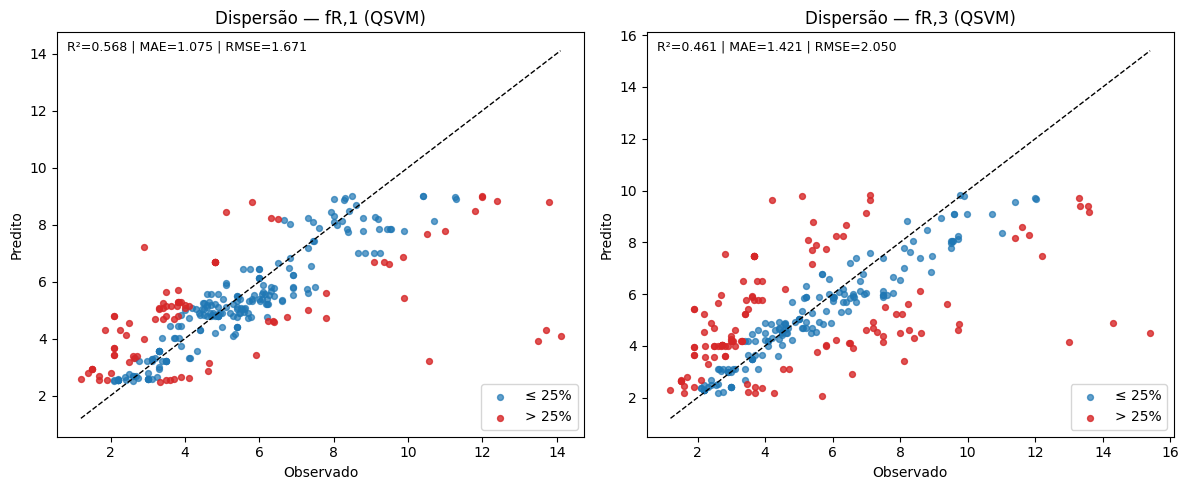

In [118]:
# =============================================================================
# Erros do QSVM (fR,1 e fR,3) + Dispersão (real vs predito) usando APENAS 'tabela_modelos'
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# --------- CONFIG ---------
BASE = tabela_modelos           # <- se seu DF tiver outro nome, altere aqui
THRESH_REL = 0.25               # 25% para colorir os pontos
EXPORTAR_EXCEL = False          # True para exportar XLSX
ARQUIVO_EXCEL = "qsvm_erros_e_dispersao.xlsx"

# --------- Colunas esperadas no BASE ---------
COL_TIPO       = 'Tipo do concreto'
COL_FR1_EXP    = 'fR,1 exp'                   # Na sua tabela já está no formato "exp"
COL_FR1_QSVM   = 'QSVM fR,1'
COL_FR3_EXP    = 'fR,3 exp'
COL_FR3_QSVM   = 'QSVM fR,3'

# (opcional) também usamos GBR no display comparativo
COL_FR1_GBR    = 'fR,1 GBR'
COL_FR3_GBR    = 'fR,3 GBR'

# --------- Validação mínima ---------
req = [COL_TIPO, COL_FR1_EXP, COL_FR1_QSVM, COL_FR3_EXP, COL_FR3_QSVM]
faltantes = [c for c in req if c not in BASE.columns]
if faltantes:
    raise KeyError(f"As colunas necessárias não estão no DataFrame base: {faltantes}")

# --------- Tabela de erros QSVM ---------
tm = BASE.copy()

# garantir numéricos
for c in [COL_FR1_EXP, COL_FR1_QSVM, COL_FR3_EXP, COL_FR3_QSVM]:
    tm[c] = pd.to_numeric(tm[c], errors='coerce')

# Erros fR,1
tm['Erro fR1 (QSVM)']  = tm[COL_FR1_QSVM] - tm[COL_FR1_EXP]
tm['|Erro fR1|']       = tm['Erro fR1 (QSVM)'].abs()
with np.errstate(divide='ignore', invalid='ignore'):
    rel1 = (tm[COL_FR1_QSVM] - tm[COL_FR1_EXP]).abs() / tm[COL_FR1_EXP].abs()
    rel1[~np.isfinite(rel1)] = np.nan
tm['Erro rel fR1 (%)'] = 100 * rel1

# Erros fR,3
tm['Erro fR3 (QSVM)']  = tm[COL_FR3_QSVM] - tm[COL_FR3_EXP]
tm['|Erro fR3|']       = tm['Erro fR3 (QSVM)'].abs()
with np.errstate(divide='ignore', invalid='ignore'):
    rel3 = (tm[COL_FR3_QSVM] - tm[COL_FR3_EXP]).abs() / tm[COL_FR3_EXP].abs()
    rel3[~np.isfinite(rel3)] = np.nan
tm['Erro rel fR3 (%)'] = 100 * rel3

tab_erros = tm[[COL_TIPO,
                COL_FR1_EXP, COL_FR1_QSVM, 'Erro fR1 (QSVM)', '|Erro fR1|', 'Erro rel fR1 (%)',
                COL_FR3_EXP, COL_FR3_QSVM, 'Erro fR3 (QSVM)', '|Erro fR3|', 'Erro rel fR3 (%)'
               ]].copy()

# --------- Resumo (MAE, RMSE, R², %>25%) ---------
def _rmse(y, yhat):
    try:    return mean_squared_error(y, yhat, squared=False)
    except: return np.sqrt(mean_squared_error(y, yhat))

def _resumo(y_true, y_pred, nome):
    y_true = pd.to_numeric(y_true, errors='coerce').values
    y_pred = pd.to_numeric(y_pred, errors='coerce').values
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if not m.any():
        return {'Alvo': nome, 'N': 0, 'MAE': np.nan, 'RMSE': np.nan, 'R²': np.nan, '%>25%': np.nan}
    yt, yp = y_true[m], y_pred[m]
    with np.errstate(divide='ignore', invalid='ignore'):
        rel = np.abs(yp - yt) / np.abs(yt)
        rel = rel[np.isfinite(rel)]
    return {
        'Alvo': nome,
        'N': int(len(yt)),
        'MAE': mean_absolute_error(yt, yp),
        'RMSE': _rmse(yt, yp),
        'R²': r2_score(yt, yp) if len(yt) > 1 else np.nan,
        '%>25%': float(100 * (rel > THRESH_REL).mean()) if rel.size > 0 else np.nan
    }

resumo = pd.DataFrame([
    _resumo(tm[COL_FR1_EXP], tm[COL_FR1_QSVM], 'fR,1 (QSVM)'),
    _resumo(tm[COL_FR3_EXP], tm[COL_FR3_QSVM], 'fR,3 (QSVM)'),
])[['Alvo','N','MAE','RMSE','R²','%>25%']]

# --------- Exibição das tabelas ---------
print("== Tabela de erros QSVM por amostra ==")
display(tab_erros)

print("== Resumo QSVM ==")
display(resumo.style.format({'MAE':'{:.3f}','RMSE':'{:.3f}','R²':'{:.3f}','%>25%':'{:.2f}%','N':'{:.0f}'}))

# --------- Dispersão (real vs predito) ---------
def _plot_disp(y_true, y_pred, titulo, ax):
    y_true = pd.to_numeric(y_true, errors='coerce').values
    y_pred = pd.to_numeric(y_pred, errors='coerce').values
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    yt, yp = y_true[m], y_pred[m]
    with np.errstate(divide='ignore', invalid='ignore'):
        rel = np.abs(yp - yt) / np.abs(yt)
    kept = rel <= THRESH_REL
    removed = ~kept

    ax.scatter(yt[kept], yp[kept], s=18, alpha=0.7, label=f'≤ {int(THRESH_REL*100)}%', color='C0')
    ax.scatter(yt[removed], yp[removed], s=18, alpha=0.8, label=f'> {int(THRESH_REL*100)}%', color='C3')

    if len(yt) > 0:
        mn, mx = np.nanmin(yt), np.nanmax(yt)
        ax.plot([mn, mx], [mn, mx], 'k--', lw=1)

    if len(yt) > 1:
        try: rmse_here = _rmse(yt, yp)
        except: rmse_here = np.nan
        ax.text(0.02, 0.98,
                f"R²={r2_score(yt, yp):.3f} | MAE={mean_absolute_error(yt, yp):.3f} | RMSE={rmse_here:.3f}",
                transform=ax.transAxes, ha='left', va='top', fontsize=9)

    ax.set_title(titulo)
    ax.set_xlabel('Observado')
    ax.set_ylabel('Predito')
    ax.legend(loc='best')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
_plot_disp(tm[COL_FR1_EXP], tm[COL_FR1_QSVM], "Dispersão — fR,1 (QSVM)", axes[0])
_plot_disp(tm[COL_FR3_EXP], tm[COL_FR3_QSVM], "Dispersão — fR,3 (QSVM)", axes[1])
plt.tight_layout()
plt.show()

# --------- (Opcional) exporta para Excel ---------
if EXPORTAR_EXCEL:
    with pd.ExcelWriter(ARQUIVO_EXCEL, engine="openpyxl") as wr:
        tab_erros.to_excel(wr, sheet_name="Erros_QSVM", index=False)
        resumo.to_excel(wr, sheet_name="Resumo_QSVM", index=False)
    print(f" Excel salvo: {ARQUIVO_EXCEL}")

In [119]:
# =============================================================================
# R², MAE, RMSE com amostras >25% removidas
# - Modo A (independente): cada alvo filtra pelo seu próprio erro relativo
# - Modo B (pareado por fR,3): usa o MESMO conjunto de mantidas de fR,3 para avaliar fR,1 e fR,3
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ---------- Config ----------
BASE = tabela_modelos  # se o seu DF tiver outro nome, ajuste aqui
THRESH = 0.25
# Quais modelos você quer avaliar?  (deixe True só no que quiser)
EVAL_QSVM = True
EVAL_GBR  = True
# Modo de filtragem:
MODO = "pareado_fr3"   # "independente"  OU  "pareado_fr3"

# ---------- Colunas esperadas ----------
COL_FR1_EXP = 'fR,1 exp'
COL_FR3_EXP = 'fR,3 exp'
COL_FR1_QSVM = 'QSVM fR,1'
COL_FR3_QSVM = 'QSVM fR,3'
COL_FR1_GBR  = 'fR,1 GBR'
COL_FR3_GBR  = 'fR,3 GBR'

def _rmse(y, yhat):
    try:
        return mean_squared_error(y, yhat, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y, yhat))

def _rel_error(y, yhat):
    y = pd.to_numeric(y, errors='coerce').values
    yh = pd.to_numeric(yhat, errors='coerce').values
    with np.errstate(divide='ignore', invalid='ignore'):
        r = np.abs(y - yh) / np.abs(y)
        r[~np.isfinite(r)] = np.nan
    return r

def _metricas(y, yhat, rotulo):
    y = pd.to_numeric(y, errors='coerce').values
    yh = pd.to_numeric(yhat, errors='coerce').values
    m = np.isfinite(y) & np.isfinite(yh)
    if not m.any():
        return {'Alvo/Modelo': rotulo, 'N': 0, 'R²': np.nan, 'MAE': np.nan, 'RMSE': np.nan}
    return {
        'Alvo/Modelo': rotulo,
        'N': int(m.sum()),
        'R²': r2_score(y[m], yh[m]) if m.sum() > 1 else np.nan,
        'MAE': mean_absolute_error(y[m], yh[m]),
        'RMSE': _rmse(y[m], yh[m]),
    }

# ---------- Construção das máscaras ----------
dfm = BASE.copy()

# QSVM: máscaras independentes por alvo
if EVAL_QSVM:
    rel1_qsvm = _rel_error(dfm[COL_FR1_EXP], dfm[COL_FR1_QSVM])
    rel3_qsvm = _rel_error(dfm[COL_FR3_EXP], dfm[COL_FR3_QSVM])
    mask1_qsvm = np.isfinite(rel1_qsvm) & (rel1_qsvm <= THRESH)
    mask3_qsvm = np.isfinite(rel3_qsvm) & (rel3_qsvm <= THRESH)
else:
    mask1_qsvm = mask3_qsvm = np.zeros(len(dfm), dtype=bool)

# GBR (opcional): máscaras independentes por alvo
if EVAL_GBR:
    rel1_gbr = _rel_error(dfm[COL_FR1_EXP], dfm[COL_FR1_GBR])
    rel3_gbr = _rel_error(dfm[COL_FR3_EXP], dfm[COL_FR3_GBR])
    mask1_gbr = np.isfinite(rel1_gbr) & (rel1_gbr <= THRESH)
    mask3_gbr = np.isfinite(rel3_gbr) & (rel3_gbr <= THRESH)
else:
    mask1_gbr = mask3_gbr = np.zeros(len(dfm), dtype=bool)

# ---------- Avaliação ----------
linhas = []

if MODO == "independente":
    # Cada alvo usa seu próprio filtro
    if EVAL_QSVM:
        linhas.append(_metricas(dfm[COL_FR1_EXP][mask1_qsvm], dfm[COL_FR1_QSVM][mask1_qsvm], "fR,1 — QSVM (≤25% próprio)"))
        linhas.append(_metricas(dfm[COL_FR3_EXP][mask3_qsvm], dfm[COL_FR3_QSVM][mask3_qsvm], "fR,3 — QSVM (≤25% próprio)"))

    if EVAL_GBR:
        linhas.append(_metricas(dfm[COL_FR1_EXP][mask1_gbr], dfm[COL_FR1_GBR][mask1_gbr], "fR,1 — GBR (≤25% próprio)"))
        linhas.append(_metricas(dfm[COL_FR3_EXP][mask3_gbr], dfm[COL_FR3_GBR][mask3_gbr], "fR,3 — GBR (≤25% próprio)"))

elif MODO == "pareado_fr3":
    # Usa SEMPRE as mantidas de fR,3 (QSVM e/ou GBR) e aplica o MESMO conjunto ao fR,1
    # 1) QSVM (se ativo)
    if EVAL_QSVM:
        mask_fr3_qsvm = mask3_qsvm  # amostras mantidas pelo erro de fR,3 (QSVM)
        # fR,3 (QSVM) no seu próprio conjunto:
        linhas.append(_metricas(dfm[COL_FR3_EXP][mask_fr3_qsvm], dfm[COL_FR3_QSVM][mask_fr3_qsvm], "fR,3 — QSVM (≤25% fr3)"))
        # fR,1 (QSVM) usando o MESMO conjunto:
        linhas.append(_metricas(dfm[COL_FR1_EXP][mask_fr3_qsvm], dfm[COL_FR1_QSVM][mask_fr3_qsvm], "fR,1 — QSVM (≤25% fr3 ∩)"))

    # 2) GBR (se ativo)
    if EVAL_GBR:
        mask_fr3_gbr = mask3_gbr
        linhas.append(_metricas(dfm[COL_FR3_EXP][mask_fr3_gbr], dfm[COL_FR3_GBR][mask_fr3_gbr], "fR,3 — GBR (≤25% fr3)"))
        linhas.append(_metricas(dfm[COL_FR1_EXP][mask_fr3_gbr], dfm[COL_FR1_GBR][mask_fr3_gbr], "fR,1 — GBR (≤25% fr3 ∩)"))

else:
    raise ValueError("MODO inválido. Use 'independente' ou 'pareado_fr3'.")

resultado = pd.DataFrame(linhas, columns=['Alvo/Modelo','N','R²','MAE','RMSE'])
display(resultado.style.format({'N':'{:.0f}','R²':'{:.3f}','MAE':'{:.3f}','RMSE':'{:.3f}'}))

resultado

,Alvo/Modelo,N,R²,MAE,RMSE
0,"fR,3 — QSVM (≤25% fr3)",162,0.887,0.578,0.796
1,"fR,1 — QSVM (≤25% fr3 ∩)",162,0.824,0.697,0.949
2,"fR,3 — GBR (≤25% fr3)",231,0.942,0.503,0.693
3,"fR,1 — GBR (≤25% fr3 ∩)",231,0.961,0.357,0.524


,Alvo/Modelo,N,R²,MAE,RMSE
0,"fR,3 — QSVM (≤25% fr3)",162,0.89,0.58,0.80
1,"fR,1 — QSVM (≤25% fr3 ∩)",162,0.82,0.70,0.95
2,"fR,3 — GBR (≤25% fr3)",231,0.94,0.50,0.69
3,"fR,1 — GBR (≤25% fr3 ∩)",231,0.96,0.36,0.52


[INFO] Usando base 'df' e features: ['fck (resistência)            [MPa]', 'Teor de fibra (%)']
[AVISO] Caminho com primitives falhou: The sampler should be an instance of BaseSamplerV2, but got <class 'qiskit_aer.primitives.sampler.Sampler'>
[INFO] Usando fallback FidelityStatevectorKernel (statevector).


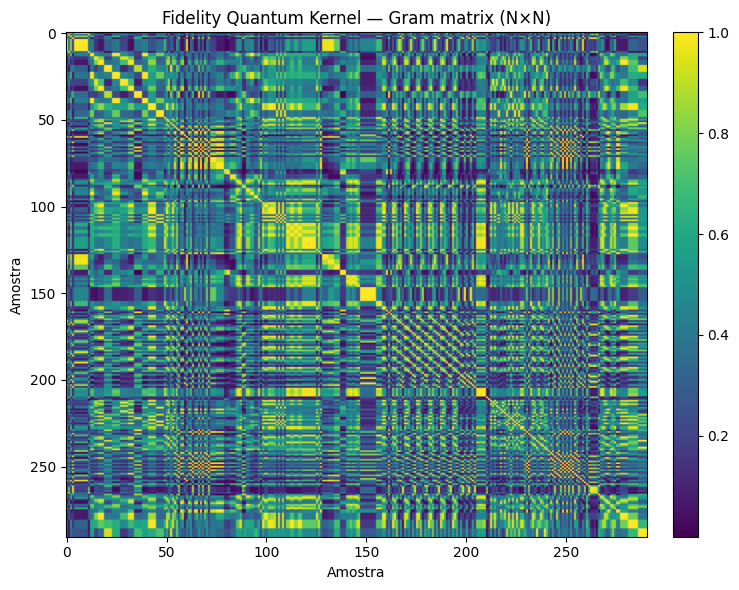

Kernel shape: (291, 291) | finite?  True


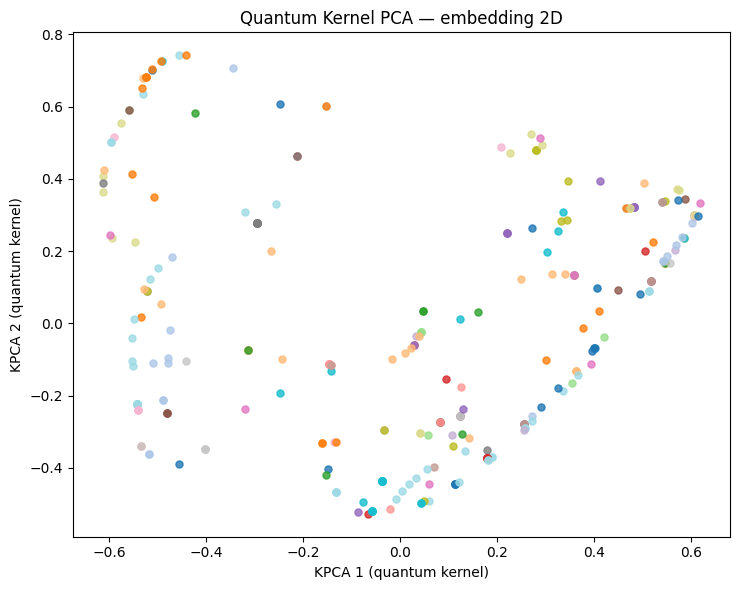

In [120]:
# =============================================================================
# Fidelity Quantum Kernel + KPCA (corrigido para API moderna: fidelity=ComputeUncompute(...))
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import KernelPCA
import unicodedata, re

# -------------------- Config --------------------
FEATURES_ALVOS = [
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]
COL_TIPO = 'Tipo do concreto'

REPS = 2          # profundidade do feature map
USE_SHOTS = False # False => exato; True => shot noise
SHOTS = 2048

# -------------------- Base de dados --------------------
candidatos = []
if 'tabela_modelos' in globals():
    candidatos.append(('tabela_modelos', tabela_modelos))
if 'df' in globals():
    candidatos.append(('df', df))
if not candidatos:
    raise RuntimeError("Nenhuma base encontrada (defina 'df' ou 'tabela_modelos').")

def _norm(s: str) -> str:
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode('ascii')
    s = re.sub(r'\s+', ' ', s.lower()).strip()
    return s

def _busca_features(df_base: pd.DataFrame, alvos: list[str]) -> list[str] | None:
    cols = list(df_base.columns)
    if set(alvos).issubset(cols):
        return alvos
    norm_map = {_norm(c): c for c in cols}
    def _match(tokens):
        for nc, original in norm_map.items():
            if all(tok in nc for tok in tokens):
                return original
        return None
    col_fck   = _match(['fck','mpa']) or _match(['fck'])
    col_fibra = _match(['teor','fibra']) or _match(['fibra'])
    if col_fck and col_fibra:
        return [col_fck, col_fibra]
    return None

SOURCE_NAME, SOURCE_DF, FEATURES = None, None, None
for nome, base in candidatos:
    found = _busca_features(base, FEATURES_ALVOS)
    if found is not None:
        SOURCE_NAME, SOURCE_DF, FEATURES = nome, base, found
        break
if SOURCE_DF is None:
    melhor = max(candidatos, key=lambda par: len(set(FEATURES_ALVOS).intersection(par[1].columns)))
    raise KeyError(
        "Não achei as FEATURES nas bases disponíveis. "
        f"Tente ajustar manualmente. Colunas procuradas: {FEATURES_ALVOS}. "
        f"Base mais próxima: {melhor[0]} (primeiras colunas: {list(melhor[1].columns)[:15]})."
    )

print(f"[INFO] Usando base '{SOURCE_NAME}' e features: {FEATURES}")

# -------------------- Limpeza/normalização --------------------
def _clean_features_full(df_full: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    X = df_full[feature_cols].apply(pd.to_numeric, errors='coerce').values
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    Xs = scaler.fit_transform(X_imp)
    return Xs

Xs = _clean_features_full(SOURCE_DF, FEATURES)

# -------------------- Fidelity Quantum Kernel --------------------
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Preferir primitives Sampler (AerSampler se disponível)
sampler = None
try:
    from qiskit_aer.primitives import Sampler as AerSampler
    sampler = AerSampler(run_options={"shots": SHOTS} if USE_SHOTS else {})
except Exception:
    try:
        from qiskit.primitives import Sampler
        sampler = Sampler()  # exato
    except Exception:
        sampler = None

fqk = None
err_primary = None
try:
    # Caminho moderno: fidelity=ComputeUncompute(sampler=...)
    from qiskit_algorithms.state_fidelities import ComputeUncompute
    fidelity = ComputeUncompute(sampler=sampler)  # Sampler pode ser None em alguns backends "exatos"
    fmap = ZZFeatureMap(feature_dimension=Xs.shape[1], reps=REPS)
    fqk = FidelityQuantumKernel(fidelity=fidelity, feature_map=fmap)
except Exception as e:
    err_primary = e
    print(f"[AVISO] Caminho com primitives falhou: {e}")

# Fallback: FidelityStatevectorKernel (otimizado para simulação por statevector)
if fqk is None:
    try:
        from qiskit_machine_learning.kernels import FidelityStatevectorKernel
        fmap = ZZFeatureMap(feature_dimension=Xs.shape[1], reps=REPS)
        fqk = FidelityStatevectorKernel(feature_map=fmap)
        print("[INFO] Usando fallback FidelityStatevectorKernel (statevector).")
    except Exception as e2:
        raise RuntimeError(f"Kernel quântico indisponível. Primitives: {err_primary} | Fallback: {e2}")

# Gram matrix (N x N)
K = fqk.evaluate(Xs)

# Centralização (boa prática para KPCA)
def center_gram(K):
    n = K.shape[0]
    one = np.ones((n, n)) / n
    return K - one @ K - K @ one + one @ K @ one

Kc = center_gram(K)

# -------------------- Heatmap --------------------
plt.figure(figsize=(7.5, 6))
im = plt.imshow(K, cmap='viridis', aspect='auto')
plt.title('Fidelity Quantum Kernel — Gram matrix (N×N)')
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xlabel('Amostra'); plt.ylabel('Amostra')
plt.tight_layout()
plt.show()
print("Kernel shape:", K.shape, "| finite? ", np.isfinite(K).all())

# -------------------- KPCA (kernel precomputed) --------------------
kpca = KernelPCA(n_components=2, kernel='precomputed', eigen_solver='auto')
Z = kpca.fit_transform(Kc)
emb = pd.DataFrame({'kpca1': Z[:, 0], 'kpca2': Z[:, 1]}, index=SOURCE_DF.index)

# Coloração por "Tipo do concreto" (se disponível)
if COL_TIPO in SOURCE_DF.columns:
    emb = emb.join(SOURCE_DF[[COL_TIPO]].astype(str), how='left')

plt.figure(figsize=(7.5, 6))
if COL_TIPO in emb.columns:
    cats = pd.Categorical(emb[COL_TIPO])
    emb['_cat'] = cats.codes
    uniq = cats.categories
    palette = plt.cm.tab20(np.linspace(0, 1, 20))
    colors = [palette[i % 20] for i in range(len(uniq))]
    for i, label in enumerate(uniq):
        m = emb['_cat'] == i
        plt.scatter(emb.loc[m, 'kpca1'], emb.loc[m, 'kpca2'],
                    s=26, alpha=0.8, color=colors[i], label=str(label))
    if len(uniq) <= 15:
        plt.legend(loc='best', fontsize=8, frameon=True)
else:
    plt.scatter(emb['kpca1'], emb['kpca2'], s=26, alpha=0.8, color='C0')

plt.xlabel('KPCA 1 (quantum kernel)')
plt.ylabel('KPCA 2 (quantum kernel)')
plt.title('Quantum Kernel PCA — embedding 2D')
plt.tight_layout()
plt.show()

# Disponibiliza para usos posteriores:
kernel_K  = K
kernel_Kc = Kc
embedding_kpca = emb

[INFO] Base: 'df' | FEATURES: ['fck (resistência)            [MPa]', 'Teor de fibra (%)']
[INFO] Reutilizando 'kernel_Kc' existente.


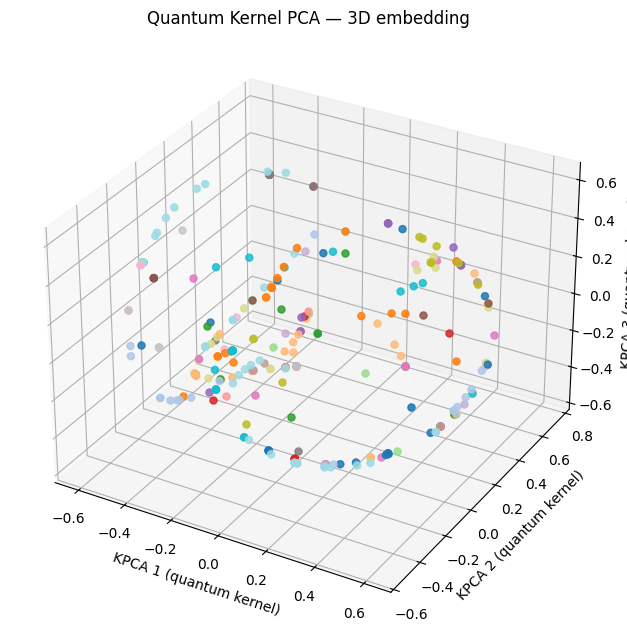

In [121]:
# =============================================================================
# Quantum Kernel PCA — Plot 3D (n_components=3)
# Reaproveita kernel_Kc se existir; senão recalcula FidelityQuantumKernel
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import KernelPCA
import unicodedata, re

# -------------------- Config --------------------
FEATURES_ALVOS = [
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]
COL_TIPO = 'Tipo do concreto'
COLOR_BY_COL = COL_TIPO     # mude para outra coluna categórica se quiser (precisa existir na base)
REPS = 2
USE_SHOTS = False
SHOTS = 2048

# -------------------- Escolha da base --------------------
bases = []
if 'tabela_modelos' in globals():
    bases.append(('tabela_modelos', tabela_modelos))
if 'df' in globals():
    bases.append(('df', df))
if not bases:
    raise RuntimeError("Nenhuma base encontrada (defina 'df' ou 'tabela_modelos').")

def _norm(s: str) -> str:
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode('ascii')
    s = re.sub(r'\s+', ' ', s.lower()).strip()
    return s

def _buscar_features(df_base: pd.DataFrame, alvos: list[str]) -> list[str] | None:
    cols = list(df_base.columns)
    if set(alvos).issubset(cols):
        return alvos
    norm_map = {_norm(c): c for c in cols}
    def _match(tokens):
        for nc, original in norm_map.items():
            if all(tok in nc for tok in tokens):
                return original
        return None
    col_fck   = _match(['fck','mpa']) or _match(['fck'])
    col_fibra = _match(['teor','fibra']) or _match(['fibra'])
    if col_fck and col_fibra:
        return [col_fck, col_fibra]
    return None

SOURCE_NAME, SOURCE_DF, FEATURES = None, None, None
for nome, base in bases:
    found = _buscar_features(base, FEATURES_ALVOS)
    if found is not None:
        SOURCE_NAME, SOURCE_DF, FEATURES = nome, base, found
        break
if SOURCE_DF is None:
    melhor = max(bases, key=lambda par: len(set(FEATURES_ALVOS).intersection(par[1].columns)))
    raise KeyError(
        "Não achei as FEATURES nas bases disponíveis. "
        f"Tente ajustar manualmente. Procuradas: {FEATURES_ALVOS}. "
        f"Base mais próxima: {melhor[0]} (primeiras colunas: {list(melhor[1].columns)[:15]})."
    )

print(f"[INFO] Base: '{SOURCE_NAME}' | FEATURES: {FEATURES}")

# -------------------- Limpeza / escala --------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

def _clean_features_full(df_full: pd.DataFrame, feature_cols: list[str]) -> np.ndarray:
    X = df_full[feature_cols].apply(pd.to_numeric, errors='coerce').values
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    Xs = scaler.fit_transform(X_imp)
    return Xs

Xs = _clean_features_full(SOURCE_DF, FEATURES)

# -------------------- Kernel (reaproveita se existir) --------------------
def _center_gram(K):
    n = K.shape[0]
    one = np.ones((n, n)) / n
    return K - one @ K - K @ one + one @ K @ one

if 'kernel_Kc' in globals() and isinstance(kernel_Kc, np.ndarray):
    Kc = kernel_Kc
    print("[INFO] Reutilizando 'kernel_Kc' existente.")
else:
    # Recalcula Fidelity Quantum Kernel (API moderna: fidelity=ComputeUncompute)
    from qiskit.circuit.library import ZZFeatureMap
    from qiskit_machine_learning.kernels import FidelityQuantumKernel

    sampler = None
    try:
        from qiskit_aer.primitives import Sampler as AerSampler
        sampler = AerSampler(run_options={"shots": SHOTS} if USE_SHOTS else {})
    except Exception:
        try:
            from qiskit.primitives import Sampler
            sampler = Sampler()   # exato
        except Exception:
            sampler = None

    fqk = None
    err_primary = None
    try:
        from qiskit_algorithms.state_fidelities import ComputeUncompute
        fidelity = ComputeUncompute(sampler=sampler)
        fmap = ZZFeatureMap(feature_dimension=Xs.shape[1], reps=REPS)
        fqk = FidelityQuantumKernel(fidelity=fidelity, feature_map=fmap)
    except Exception as e:
        err_primary = e
        print(f"[AVISO] Caminho com primitives falhou: {e}")

    if fqk is None:
        try:
            from qiskit_machine_learning.kernels import FidelityStatevectorKernel
            fmap = ZZFeatureMap(feature_dimension=Xs.shape[1], reps=REPS)
            fqk = FidelityStatevectorKernel(feature_map=fmap)
            print("[INFO] Usando fallback FidelityStatevectorKernel (statevector).")
        except Exception as e2:
            raise RuntimeError(f"Kernel indisponível. Primitives: {err_primary} | Fallback: {e2}")

    K = fqk.evaluate(Xs)
    Kc = _center_gram(K)

# -------------------- KPCA 3D --------------------
kpca3 = KernelPCA(n_components=3, kernel='precomputed', eigen_solver='auto')
Z3 = kpca3.fit_transform(Kc)
emb3 = pd.DataFrame(Z3, columns=['kpca1','kpca2','kpca3'], index=SOURCE_DF.index)

# Adiciona rótulo de cor se disponível
color_series = None
if COLOR_BY_COL in SOURCE_DF.columns:
    color_series = SOURCE_DF[COLOR_BY_COL].astype(str)
elif 'tabela_modelos' in globals() and COLOR_BY_COL in tabela_modelos.columns:
    color_series = tabela_modelos[COLOR_BY_COL].astype(str)
elif 'df' in globals() and COLOR_BY_COL in df.columns:
    color_series = df[COLOR_BY_COL].astype(str)

# Fração de variância explicada aproximada (a partir dos autovalores do KPCA)
lamb = getattr(kpca3, "lambdas_", None)
if lamb is not None and np.isfinite(lamb).all():
    frac = lamb / np.sum(lamb)
    subtitle = f"Var.aprox.: [{frac[0]:.2f}, {frac[1]:.2f}, {frac[2]:.2f}]"
else:
    subtitle = None

# -------------------- Plot 3D --------------------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
fig = plt.figure(figsize=(8.0, 6.5))
ax = fig.add_subplot(111, projection='3d')

if color_series is not None:
    cats = pd.Categorical(color_series)
    codes = cats.codes
    uniq  = cats.categories
    palette = plt.cm.tab20(np.linspace(0, 1, 20))
    for i, label in enumerate(uniq):
        m = (codes == i)
        ax.scatter(emb3.loc[m,'kpca1'], emb3.loc[m,'kpca2'], emb3.loc[m,'kpca3'],
                   s=26, alpha=0.85, color=palette[i % 20], label=str(label))
    if len(uniq) <= 12:
        ax.legend(loc='best', fontsize=8)
else:
    ax.scatter(emb3['kpca1'], emb3['kpca2'], emb3['kpca3'], s=26, alpha=0.85, color='C0')

ax.set_xlabel('KPCA 1 (quantum kernel)')
ax.set_ylabel('KPCA 2 (quantum kernel)')
ax.set_zlabel('KPCA 3 (quantum kernel)')
title = 'Quantum Kernel PCA — 3D embedding'
if subtitle:
    title += f"\n{subtitle}"
ax.set_title(title)
plt.tight_layout()
plt.show()

# Embedding 3D
embedding_kpca3 = emb3

[INFO] Base: 'df' | FEATURES: ['fck (resistência)            [MPa]', 'Teor de fibra (%)']
[AVISO] Primitives falharam: The sampler should be an instance of BaseSamplerV2, but got <class 'qiskit_aer.primitives.sampler.Sampler'>
[INFO] Usando fallback FidelityStatevectorKernel (statevector).
Kernel shape: (291, 291) | finite?  True


,Tipo do concreto,sens_mean[fck (resistência) [MPa]],sens_max[fck (resistência) [MPa]],sens_mean[Teor de fibra (%)],sens_max[Teor de fibra (%)]
0,AM-0.4-EH1,1.09,4.50,1.06,3.46
1,AM-0.8-EH1,1.33,4.13,1.28,3.70
2,AM-0.4-EH2,0.80,3.11,0.74,2.13
3,AM-0.8-EH2,0.76,2.99,0.62,2.00
4,AM-0.4-EH1,1.09,4.50,1.06,3.46
5,AM-0.4-EH1,1.09,4.50,1.06,3.46
6,AM-0.4-EH1,1.09,4.50,1.06,3.46
7,AM-0.4-EH1,1.09,4.50,1.06,3.46
8,AM-0.4-EH1,1.09,4.50,1.06,3.46
9,AM-0.4-EH1,1.09,4.50,1.06,3.46


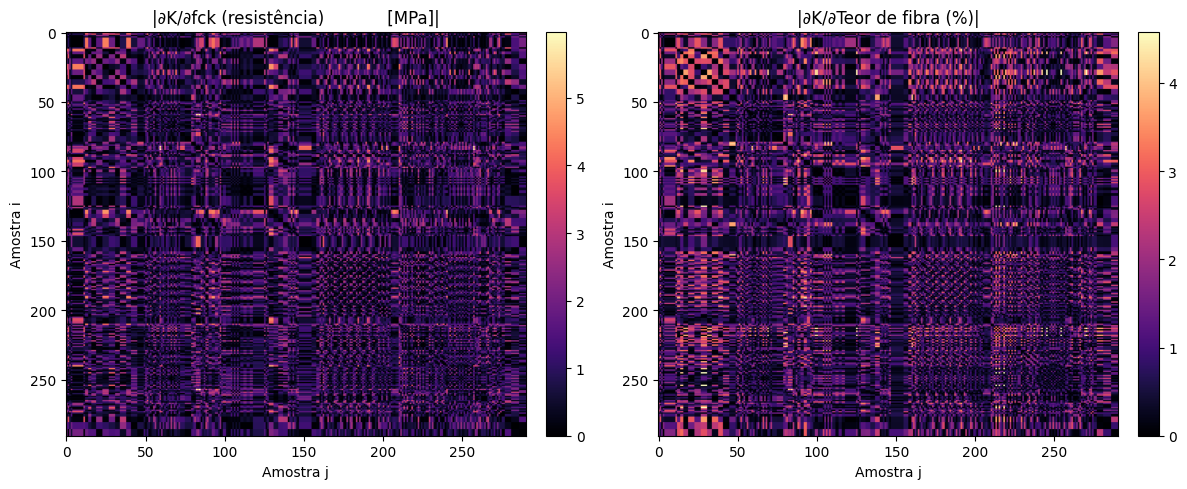

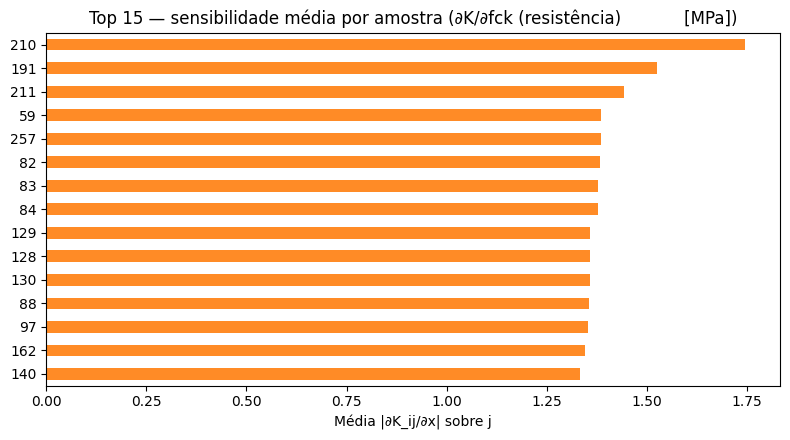

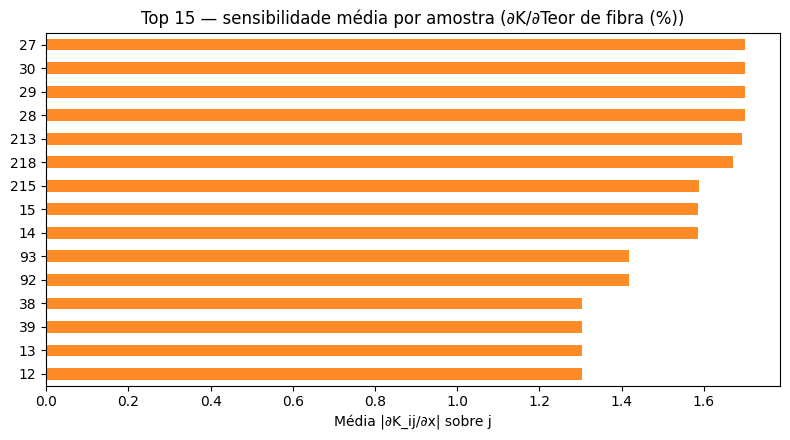

In [122]:
# =============================================================================
# Quantum Sensitivity (dK/dx) — Fidelity Quantum Kernel
#   - Calcula ∂K/∂x_c via diferenças centrais em cada feature c
#   - Relata sensibilidade por amostra (média e máximo por linha da derivada)
#   - Plota heatmaps e Top-N amostras mais sensíveis por feature
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import KernelPCA
import unicodedata, re

# -------------------- Config --------------------
# Se precisar, ajuste/altere a lista alvo; o código também tenta achar nomes “parecidos”
FEATURES_ALVOS = [
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]
COL_TIPO = 'Tipo do concreto'

REPS       = 2         # profundidade do ZZFeatureMap
USE_SHOTS  = False     # False => exato (sem shot noise); True => usa shots
SHOTS      = 2048
EPS        = 0.02      # perturbação em espaço NORMALIZADO (-1,1). 0.02 ~ 1% do range [-1,1]
TOP_N_BARS = 15        # quantas amostras mostrar nos gráficos de barras (por feature)
EXPORTAR   = False     # True para salvar CSV/Excel
ARQ_CSV    = "quantum_sensitivity_rows.csv"
ARQ_XLSX   = "quantum_sensitivity_rows.xlsx"

# -------------------- Escolha da base e features --------------------
bases = []
if 'tabela_modelos' in globals():
    bases.append(('tabela_modelos', tabela_modelos))
if 'df' in globals():
    bases.append(('df', df))
if not bases:
    raise RuntimeError("Nenhuma base encontrada (defina 'df' ou 'tabela_modelos').")

def _norm(s: str) -> str:
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii','ignore').decode('ascii')
    s = re.sub(r'\s+', ' ', s.lower()).strip()
    return s

def _buscar_features(df_base: pd.DataFrame, alvos: list[str]) -> list[str] | None:
    cols = list(df_base.columns)
    if set(alvos).issubset(cols):
        return alvos
    norm_map = {_norm(c): c for c in cols}
    def _match(tokens):
        for nc, original in norm_map.items():
            if all(tok in nc for tok in tokens):
                return original
        return None
    col_fck   = _match(['fck','mpa']) or _match(['fck'])
    col_fibra = _match(['teor','fibra']) or _match(['fibra'])
    if col_fck and col_fibra:
        return [col_fck, col_fibra]
    return None

SOURCE_NAME, SOURCE_DF, FEATURES = None, None, None
for nome, base in bases:
    found = _buscar_features(base, FEATURES_ALVOS)
    if found is not None:
        SOURCE_NAME, SOURCE_DF, FEATURES = nome, base, found
        break
if SOURCE_DF is None:
    melhor = max(bases, key=lambda par: len(set(FEATURES_ALVOS).intersection(par[1].columns)))
    raise KeyError(
        "Não achei as FEATURES nas bases disponíveis. "
        f"Tente ajustar manualmente. Procuradas: {FEATURES_ALVOS}. "
        f"Base mais próxima: {melhor[0]} (primeiras colunas: {list(melhor[1].columns)[:15]})."
    )

print(f"[INFO] Base: '{SOURCE_NAME}' | FEATURES: {FEATURES}")

# -------------------- Limpeza / normalização (-1,1) --------------------
def _clean_features_full(df_full: pd.DataFrame, feature_cols: list[str]):
    X = df_full[feature_cols].apply(pd.to_numeric, errors='coerce').values
    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X)
    scaler = MinMaxScaler(feature_range=(-1, 1))
    Xs = scaler.fit_transform(X_imp)
    return Xs, imp, scaler

Xs, imp, scaler = _clean_features_full(SOURCE_DF, FEATURES)
N, D = Xs.shape

# -------------------- Kernel Builder (API moderna + fallback) --------------------
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

def _build_kernel(feature_dim: int):
    # Primeiro: primitives (ComputeUncompute)
    sampler = None
    try:
        from qiskit_aer.primitives import Sampler as AerSampler
        sampler = AerSampler(run_options={"shots": SHOTS} if USE_SHOTS else {})
    except Exception:
        try:
            from qiskit.primitives import Sampler
            sampler = Sampler()
        except Exception:
            sampler = None

    fmap = ZZFeatureMap(feature_dimension=feature_dim, reps=REPS)

    fqk = None
    try:
        from qiskit_algorithms.state_fidelities import ComputeUncompute
        fidelity = ComputeUncompute(sampler=sampler)
        fqk = FidelityQuantumKernel(fidelity=fidelity, feature_map=fmap)
    except Exception as e:
        print(f"[AVISO] Primitives falharam: {e}")
        # Fallback por statevector
        try:
            from qiskit_machine_learning.kernels import FidelityStatevectorKernel
            fqk = FidelityStatevectorKernel(feature_map=fmap)
            print("[INFO] Usando fallback FidelityStatevectorKernel (statevector).")
        except Exception as e2:
            raise RuntimeError(f"Kernel indisponível. Primitives: {e} | Fallback: {e2}")
    return fqk

fqk = _build_kernel(D)

# -------------------- Kernel base (K) e centralizado (Kc) --------------------
def _center_gram(K):
    n = K.shape[0]
    one = np.ones((n, n)) / n
    return K - one @ K - K @ one + one @ K @ one

K  = fqk.evaluate(Xs)
Kc = _center_gram(K)

print("Kernel shape:", K.shape, "| finite? ", np.isfinite(K).all())

# -------------------- dK/dx (diferença central por feature) --------------------
grads = {}           # dict: feature_name -> ∂K/∂x (N x N)
sens_rows_mean = {}  # sensibilidade média por amostra
sens_rows_max  = {}  # sensibilidade máxima por amostra

for c, feat in enumerate(FEATURES):
    Xp = Xs.copy(); Xm = Xs.copy()
    Xp[:, c] = np.clip(Xp[:, c] + EPS, -1.0, 1.0)
    Xm[:, c] = np.clip(Xm[:, c] - EPS, -1.0, 1.0)

    K_plus  = fqk.evaluate(Xp)
    K_minus = fqk.evaluate(Xm)

    dK = (K_plus - K_minus) / (2.0 * EPS)  # derivada aproximada
    grads[feat] = dK

    # métricas por amostra i (linha i)
    sens_rows_mean[feat] = np.mean(np.abs(dK), axis=1)  # média |dK_ij/dx_c| sobre j
    sens_rows_max[feat]  = np.max(np.abs(dK),  axis=1)  # máximo |...|

# -------------------- Tabela de sensibilidade por amostra --------------------
base_idx = SOURCE_DF.index
out_cols = []
for feat in FEATURES:
    out_cols += [f"sens_mean[{feat}]", f"sens_max[{feat}]"]

df_sens = pd.DataFrame(index=base_idx)
if COL_TIPO in SOURCE_DF.columns:
    df_sens[COL_TIPO] = SOURCE_DF[COL_TIPO].astype(str).values

for feat in FEATURES:
    df_sens[f"sens_mean[{feat}]"] = sens_rows_mean[feat]
    df_sens[f"sens_max[{feat}]"]  = sens_rows_max[feat]

display(df_sens.head(10))

# -------------------- Heatmaps de |dK/dx| (um por feature) --------------------
fig_rows = 1
fig_cols = len(FEATURES)
plt.figure(figsize=(6*fig_cols, 5))
for j, feat in enumerate(FEATURES, start=1):
    plt.subplot(fig_rows, fig_cols, j)
    im = plt.imshow(np.abs(grads[feat]), cmap='magma', aspect='auto')
    plt.title(f"|∂K/∂{feat}|")
    plt.xlabel("Amostra j"); plt.ylabel("Amostra i")
    plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# -------------------- Barras Top-N amostras mais sensíveis por feature --------------------
for feat in FEATURES:
    s = df_sens[f"sens_mean[{feat}]"].copy()
    top = s.sort_values(ascending=False).head(TOP_N_BARS)
    plt.figure(figsize=(8, 4.5))
    top[::-1].plot(kind='barh', color='C1', alpha=0.9)
    plt.title(f"Top {TOP_N_BARS} — sensibilidade média por amostra (∂K/∂{feat})")
    plt.xlabel("Média |∂K_ij/∂x| sobre j")
    plt.tight_layout()
    plt.show()

# -------------------- (Opcional) Exportação --------------------
if EXPORTAR:
    df_sens.reset_index(names='idx').to_csv(ARQ_CSV, index=False, encoding='utf-8')
    try:
        with pd.ExcelWriter(ARQ_XLSX, engine="openpyxl") as wr:
            df_sens.reset_index(names='idx').to_excel(wr, sheet_name="sensibilidade", index=False)
        print(f" Exportado: {ARQ_CSV} | {ARQ_XLSX}")
    except Exception as e:
        print(f"[AVISO] Falha ao salvar Excel: {e}. CSV salvo em {ARQ_CSV}.")

In [132]:
from qiskit_aer.primitives import Sampler as AerSampler
from qiskit_algorithms.state_fidelities import ComputeUncompute

In [133]:
# =============================================================================
# COMPARAÇÃO DE TEMPO — GBR (clássico) vs QSVM (quântico com SHOTS)
# =============================================================================

import time
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

# ---------------- CONFIG ----------------
FEATURES = ['fck (resistência)            [MPa]', 'Teor de fibra (%)']
TARGET = 'fR,1 (N/mm²)      (experimental)'

SHOTS = 2048   # tente também 4096 ou 8192
REPS = 2       # profundidade do ZZFeatureMap

# ------------- Função de limpeza ----------------
def prepare_X_y(df):
    X = df[FEATURES].apply(pd.to_numeric, errors='coerce').values
    y = pd.to_numeric(df[TARGET], errors='coerce').values
    mask = np.isfinite(y)
    X, y = X[mask], y[mask]
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(X)
    scaler = MinMaxScaler(feature_range=(-1,1))
    Xs = scaler.fit_transform(X_imp)
    return Xs, y

Xs, y = prepare_X_y(df)

# =============================================================================
# 1) Tempo GBR
# =============================================================================
t0 = time.time()
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3)
gbr.fit(Xs, y)
t_gbr_train = time.time() - t0

t0 = time.time()
y_pred_gbr = gbr.predict(Xs)
t_gbr_pred = time.time() - t0

print("\n===== GBR CLÁSSICO =====")
print(f"Treino:   {t_gbr_train:.4f} s")
print(f"Predição: {t_gbr_pred:.4f} s")

# =============================================================================
# 2) Tempo QSVM (com FidelityQuantumKernel + SHOTS)
# =============================================================================
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.kernels import FidelityQuantumKernel

# Tenta primitives (ComputeUncompute + AerSampler)
fqk = None
try:
    from qiskit_aer.primitives import Sampler as AerSampler
    from qiskit_algorithms.state_fidelities import ComputeUncompute

    sampler = AerSampler(run_options={"shots": SHOTS})
    fidelity = ComputeUncompute(sampler=sampler)
    fmap = ZZFeatureMap(Xs.shape[1], reps=REPS)

    fqk = FidelityQuantumKernel(feature_map=fmap, fidelity=fidelity)
    kernel_mode = "Primitives + Shots"
except Exception as e1:
    print("[AVISO] Primitives com shots falharam, tentando fallback statevector.")
    try:
        from qiskit_machine_learning.kernels import FidelityStatevectorKernel
        fmap = ZZFeatureMap(Xs.shape[1], reps=REPS)
        fqk = FidelityStatevectorKernel(feature_map=fmap)
        kernel_mode = "StatevectorKernel (exato)"
    except Exception as e2:
        raise RuntimeError(f"Não foi possível inicializar kernel quântico.\n1) {e1}\n2) {e2}")

print(f"\nKernel Mode: {kernel_mode}")
print(f"Shots: {SHOTS}")

# ---------------- Tempo para gerar K ----------------
t0 = time.time()
K = fqk.evaluate(Xs)
t_kernel = time.time() - t0

# ---------------- Tempo para treinar + prever SVR(kernel precomputed) ----------------
t0 = time.time()
svr = SVR(kernel="precomputed", C=1.0, epsilon=0.1).fit(K, y)
t_svm_train = time.time() - t0

t0 = time.time()
y_pred_qsvm = svr.predict(K)
t_svm_pred = time.time() - t0

print("\n===== QSVM QUÂNTICO =====")
print(f"Kernel computation: {t_kernel:.4f} s")
print(f"Treino (SVR):       {t_svm_train:.4f} s")
print(f"Predição (SVR):     {t_svm_pred:.4f} s")

# ---------------- Disponibiliza ----------------
tempo_gbr   = (t_gbr_train, t_gbr_pred)
tempo_qsvm  = (t_kernel, t_svm_train, t_svm_pred)
y_true      = y
y_pred_qsvm = y_pred_qsvm
y_pred_gbr  = y_pred_gbr



===== GBR CLÁSSICO =====
Treino:   0.1616 s
Predição: 0.0010 s
[AVISO] Primitives com shots falharam, tentando fallback statevector.

Kernel Mode: StatevectorKernel (exato)
Shots: 2048

===== QSVM QUÂNTICO =====
Kernel computation: 0.9503 s
Treino (SVR):       0.0032 s
Predição (SVR):     0.0005 s


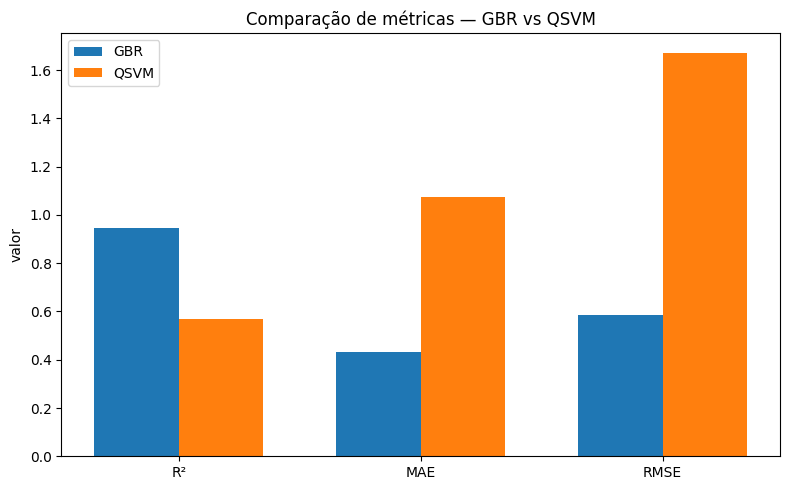

Métricas GBR : {'R²': 0.9472773718874863, 'MAE': 0.43254383269747154, 'RMSE': np.float64(0.5840656868371045)}
Métricas QSVM: {'R²': 0.5684387071661807, 'MAE': 1.0747867183236657, 'RMSE': np.float64(1.6710306278699858)}


In [128]:
# =============================================================================
# Gráficos COMPARATIVOS — R² / MAE / RMSE (GBR vs QSVM)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def rmse(y, yh):
    try: return mean_squared_error(y, yh, squared=False)
    except TypeError: return np.sqrt(mean_squared_error(y, yh))

m_gbr = {"R²": r2_score(y_true, y_pred_gbr),
         "MAE": mean_absolute_error(y_true, y_pred_gbr),
         "RMSE": rmse(y_true, y_pred_gbr)}
m_qsvm = {"R²": r2_score(y_true, y_pred_qsvm),
          "MAE": mean_absolute_error(y_true, y_pred_qsvm),
          "RMSE": rmse(y_true, y_pred_qsvm)}

labels = ["R²","MAE","RMSE"]
g_vals  = [m_gbr[l] for l in labels]
q_vals  = [m_qsvm[l] for l in labels]

x = np.arange(len(labels)); w = 0.35
plt.figure(figsize=(8,5))
plt.bar(x - w/2, g_vals,  w, label="GBR")
plt.bar(x + w/2, q_vals,  w, label="QSVM")
plt.xticks(x, labels)
plt.title("Comparação de métricas — GBR vs QSVM")
plt.ylabel("valor")
plt.legend()
plt.tight_layout()
plt.show()

print("Métricas GBR :", m_gbr)
print("Métricas QSVM:", m_qsvm)


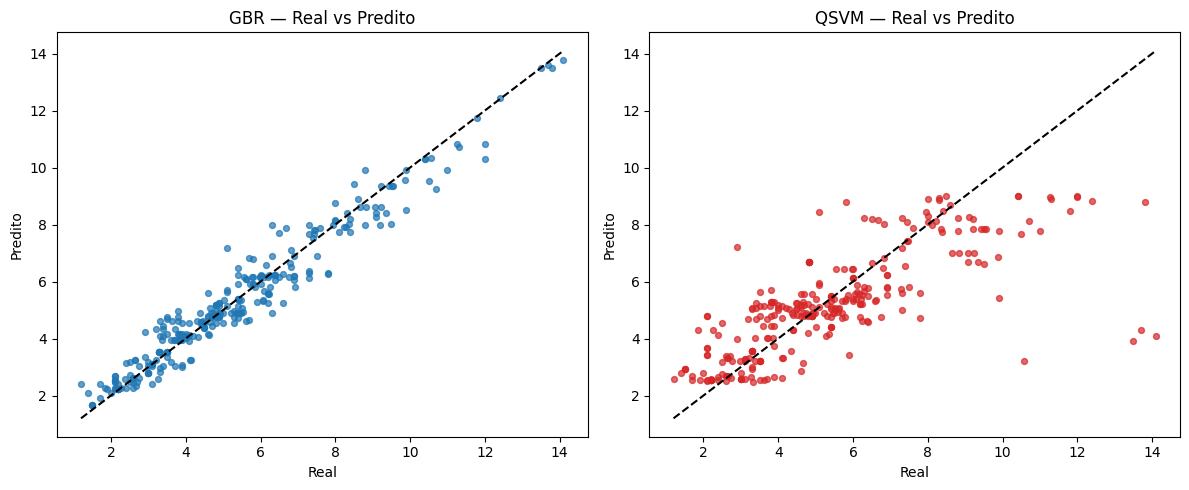

In [129]:
# =============================================================================
# Dispersão lado a lado — GBR vs QSVM
# =============================================================================
import matplotlib.pyplot as plt
mn, mx = float(np.min(y_true)), float(np.max(y_true))

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(y_true, y_pred_gbr, s=18, alpha=0.7, color="C0")
ax[0].plot([mn,mx],[mn,mx],'k--'); ax[0].set_title("GBR — Real vs Predito")
ax[0].set_xlabel("Real"); ax[0].set_ylabel("Predito")

ax[1].scatter(y_true, y_pred_qsvm, s=18, alpha=0.7, color="C3")
ax[1].plot([mn,mx],[mn,mx],'k--'); ax[1].set_title("QSVM — Real vs Predito")
ax[1].set_xlabel("Real"); ax[1].set_ylabel("Predito")

plt.tight_layout(); plt.show()

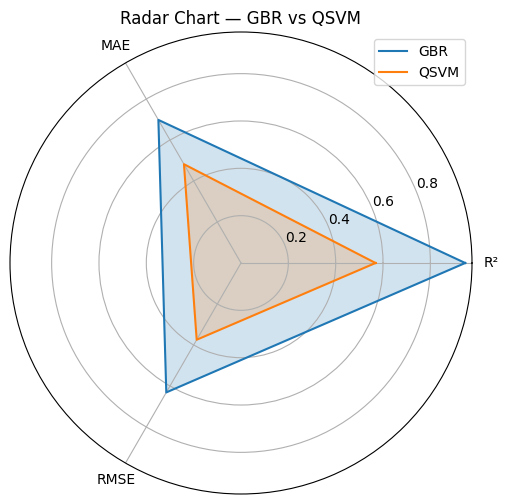

In [130]:
# =============================================================================
# Radar Chart — GBR vs QSVM
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

labels = np.array(["R²","MAE","RMSE"])

# Para o radar ficar coerente (quanto maior melhor), inverti MAE/RMSE (1/(1+x))
gbr_v = np.array([m_gbr["R²"], 1/(1+m_gbr["MAE"]), 1/(1+m_gbr["RMSE"])])
qs_v  = np.array([m_qsvm["R²"],1/(1+m_qsvm["MAE"]),1/(1+m_qsvm["RMSE"])])

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
gbr_v  = np.concatenate([gbr_v,[gbr_v[0]]])
qs_v   = np.concatenate([qs_v,[qs_v[0]]])
angles = np.concatenate([angles,[angles[0]]])

plt.figure(figsize=(6,6))
plt.polar(angles, gbr_v, label="GBR")
plt.polar(angles, qs_v,  label="QSVM")
plt.fill(angles, gbr_v, alpha=0.2)
plt.fill(angles, qs_v,  alpha=0.2)
plt.xticks(angles[:-1], labels)
plt.title("Radar Chart — GBR vs QSVM")
plt.legend(loc="upper right")
plt.show()

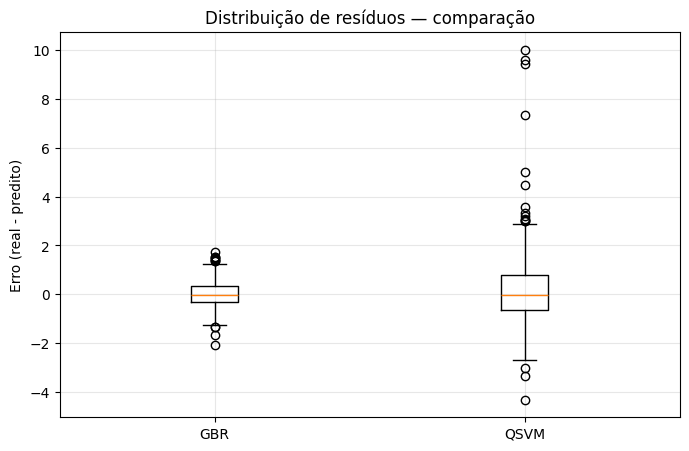

In [131]:
# =============================================================================
# Boxplot de RESÍDUOS — GBR vs QSVM
# =============================================================================
import matplotlib.pyplot as plt

res_gbr  = y_true - y_pred_gbr
res_qsvm = y_true - y_pred_qsvm

plt.figure(figsize=(8,5))
plt.boxplot([res_gbr, res_qsvm], labels=["GBR","QSVM"])
plt.title("Distribuição de resíduos — comparação")
plt.ylabel("Erro (real - predito)")
plt.grid(alpha=0.3)
plt.show()